
# Paper 2 — Goal 3 publication figures — v1.0

**Purpose.** This is the figure-only handoff after Goal 3 computational completion.

It does **not** rerun waveform perturbations, segmentation, Q/A extraction, model fitting, residualization, HGB reconstruction, GEE, bootstrap inference, or dose selection. It reads only frozen machine-readable outputs from:

- Goal 3 Stage A natural Q–A localization;
- Goal 3 Stage E controlled perturbation;
- Notebook 36 robustness/computational completion;
- the frozen A registry/value table only where the exact Stage-E natural-IQR scaling must be reproduced for display.

It produces four review figures:

- **Figure 5** — natural between- and within-participant Q–A localization;
- **Figure 6** — controlled target-Q, acoustic-representation, model-output, and prediction-error movement;
- **Figure S_G3_07** — full feature-level perturbation localization and off-target Q movement;
- **Figure S_G3_08** — support/availability, segmentation, exemplar, QDIST, and frozen-HGB robustness.

### Interpretation boundary

Natural Q–A localization is observational. Same-source controlled dose responses support direct sensitivity only to the **imposed digital transformation**. They do not identify the physical cause of a natural association and do not justify generic device/room/artifact claims.

### Run instruction

Use **Kernel → Restart Kernel and Run All Cells**.

Review outputs are written to:

`outputs/goal3/FINAL_FIGURES_REVIEW/`

The notebook ends with:

`GOAL 3 PUBLICATION FIGURE PACKAGE: PASS_PENDING_VISUAL_REVIEW`

It deliberately does **not** write the final Goal 3 freeze/DONE seal.


In [1]:

from __future__ import annotations

import hashlib
import json
import math
import os
import re
from datetime import datetime, timezone
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
from IPython.display import display

ENGINE_VERSION = "goal3-publication-figures-v1.0.0"
MM_TO_IN = 1 / 25.4

MODELS = ["M_A", "M_A+Q", "M_A-resQ"]
MODEL_PALETTE = {
    "M_A": "#203D5B",
    "M_A+Q": "#167C80",
    "M_A-resQ": "#A65345",
}
HGB_TO_RIDGE = {
    "HGB_M_A": "M_A",
    "HGB_M_A+Q": "M_A+Q",
    "HGB_M_A-resQ": "M_A-resQ",
}

FAMILY_PALETTE = {
    "QADD": "#3D78A8",
    "QGAIN": "#C67645",
    "QREV": "#52866B",
    "QCHAN": "#846A98",
    "QDIST": "#766A4A",
}
NEUTRAL = "#6B7280"
MID = "#9CA3AF"
LIGHT = "#D9DEE5"
VERY_LIGHT = "#EEF1F4"

TRANSFORM_ORDER = [
    "stationary_colored_broadband",
    "uniform_level_shift",
    "smooth_time_varying_gain",
    "RIR_convolution_RMS_matched",
    "upper_band_restriction",
    "symmetric_hard_clipping",
]
TRANSFORM_LABEL = {
    "stationary_colored_broadband": "QADD\nNoise",
    "uniform_level_shift": "QGAIN\nStatic",
    "smooth_time_varying_gain": "QGAIN\nDynamic",
    "RIR_convolution_RMS_matched": "QREV\nRIR",
    "upper_band_restriction": "QCHAN\nLow-pass",
    "symmetric_hard_clipping": "QDIST\nClip",
}
TRANSFORM_SHORT = {
    "stationary_colored_broadband": "Noise",
    "uniform_level_shift": "Static",
    "smooth_time_varying_gain": "Dynamic",
    "RIR_convolution_RMS_matched": "RIR",
    "upper_band_restriction": "Low-pass",
    "symmetric_hard_clipping": "Clip",
}
DOSE_LABELS = {0: "Base", 1: "Low", 2: "Med", 3: "High"}

mpl.rcParams.update({
    "font.family": ["Arial", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7.2,
    "xtick.labelsize": 5.8,
    "ytick.labelsize": 5.8,
    "legend.fontsize": 5.8,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

def utc_now():
    return datetime.now(timezone.utc).isoformat()

def sha256_file(path: Path, chunk_size=1024 * 1024):
    path = Path(path)
    h = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(chunk_size), b""):
            h.update(block)
    return h.hexdigest()

def atomic_json(payload: dict, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name("." + path.name + ".tmp")
    tmp.write_text(
        json.dumps(payload, indent=2, sort_keys=True, default=str),
        encoding="utf-8",
    )
    os.replace(tmp, path)

def atomic_csv(frame: pd.DataFrame, path: Path, *, allow_empty=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if frame.empty and not allow_empty:
        raise ValueError(f"Refusing to write empty CSV: {path}")
    tmp = path.with_name("." + path.name + ".tmp")
    frame.to_csv(tmp, index=False)
    os.replace(tmp, path)

def read_csv_checked(path: Path, required=None, *, allow_empty=False):
    path = Path(path)
    if not path.exists() or path.stat().st_size == 0:
        raise FileNotFoundError(path)
    frame = pd.read_csv(path, low_memory=False)
    if frame.empty and not allow_empty:
        raise RuntimeError(f"{path.name}: no rows.")
    if required:
        missing = set(required) - set(frame.columns)
        if missing:
            raise KeyError(f"{path.name}: missing columns {sorted(missing)}")
    return frame

def as_bool(series):
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)
    return (
        series.astype(str).str.strip().str.lower()
        .isin({"true", "1", "yes", "y"})
    )

def clean_ax(ax):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", pad=2)

def add_panel_letter(fig, x, y, letter):
    fig.text(
        x, y, letter,
        fontsize=9.0, fontweight="bold",
        ha="left", va="top",
    )

def padded_limits(values, *, include_zero=True, frac=0.08):
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if include_zero:
        x = np.r_[x, 0.0]
    if not len(x):
        return (-1.0, 1.0)
    lo, hi = float(np.min(x)), float(np.max(x))
    if math.isclose(lo, hi):
        pad = max(0.1, abs(lo) * 0.2)
    else:
        pad = (hi - lo) * frac
    return lo - pad, hi + pad

print("Publication figure utilities: READY")


Publication figure utilities: READY



## 1. Locate the frozen Goal 3 state

The figure notebook gates itself on the successful Stage-A seal, the Stage-E primary seal, and Notebook-36 computational completion. Nothing is recomputed upstream.


In [2]:

def find_root():
    override = os.environ.get("PAPER2_ROOT", "").strip()
    if override:
        p = Path(override).expanduser().resolve()
        if (p / "outputs" / "goal3").exists():
            return p
        raise FileNotFoundError(f"Invalid PAPER2_ROOT: {p}")

    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (
            (p / "outputs" / "goal3").exists()
            and (p / "data" / "processed").exists()
            and (p / "data" / "manifests").exists()
        ):
            return p
    raise FileNotFoundError(
        "Could not locate Paper_2_Leakage/Code. "
        "Run from the repository or set PAPER2_ROOT."
    )

ROOT = find_root()

STAGE_A_CANDIDATES = [
    ROOT / "outputs" / "goal3" / "stageA_v1_1",
    ROOT / "outputs" / "goal3" / "stageA_v1_0",
]
STAGE_A = next(
    (p for p in STAGE_A_CANDIDATES if (p / "SUCCESS_STAGE_A.json").exists()),
    None,
)
if STAGE_A is None:
    raise FileNotFoundError("No successful Goal-3 Stage-A directory found.")

STAGE_A_TABLES = STAGE_A / "tables"
STAGE_E = (
    ROOT / "outputs" / "goal3"
    / "stageE_controlled_perturbation_v1_0" / "final"
)
STAGE_E_TABLES = STAGE_E / "tables"
STAGE_E_AUDIT = STAGE_E / "audit"

COMPLETION = (
    ROOT / "outputs" / "goal3"
    / "goal3_completion_v1_0" / "final"
)
COMPLETION_TABLES = COMPLETION / "tables"
COMPLETION_AUDIT = COMPLETION / "audit"

FIGURES = ROOT / "outputs" / "goal3" / "FINAL_FIGURES_REVIEW"
SOURCE_TABLES = FIGURES / "source_tables"
PROVENANCE = FIGURES / "provenance"
for d in [FIGURES, SOURCE_TABLES, PROVENANCE]:
    d.mkdir(parents=True, exist_ok=True)

STAGE_A_SEAL = STAGE_A / "SUCCESS_STAGE_A.json"
STAGE_E_SEAL = STAGE_E / "GOAL3_STAGE_E_PRIMARY_SEAL.json"
COMPLETION_MANIFEST = COMPLETION / "GOAL3_COMPLETION_MANIFEST.json"
DONE_COMPUTATIONAL = COMPLETION / "DONE_COMPUTATIONAL.json"

for p in [STAGE_A_SEAL, STAGE_E_SEAL, COMPLETION_MANIFEST, DONE_COMPUTATIONAL]:
    if not p.exists():
        raise FileNotFoundError(p)

stage_a_seal = json.loads(STAGE_A_SEAL.read_text(encoding="utf-8"))
stage_e_seal = json.loads(STAGE_E_SEAL.read_text(encoding="utf-8"))
completion_manifest = json.loads(COMPLETION_MANIFEST.read_text(encoding="utf-8"))
done_computational = json.loads(DONE_COMPUTATIONAL.read_text(encoding="utf-8"))

if str(stage_a_seal.get("status", "")).upper() != "PASS":
    raise RuntimeError("Stage A is not PASS.")
if str(stage_e_seal.get("status", "")).upper() != "PASS":
    raise RuntimeError("Stage E primary seal is not PASS.")
if str(done_computational.get("status", "")) != "PASS_PENDING_PUBLICATION_FIGURES":
    raise RuntimeError(
        "Notebook 36 has not reached PASS_PENDING_PUBLICATION_FIGURES."
    )

hgb_repro = float(
    completion_manifest.get("hgb_goal2_reproduction_max_abs_diff", np.nan)
)
if not np.isfinite(hgb_repro) or hgb_repro > 1e-10:
    raise RuntimeError(
        f"Frozen HGB Goal-2 reproduction gate is not intact: {hgb_repro}"
    )

print("Paper 2 root:", ROOT)
print("Stage A:", STAGE_A)
print("Stage E:", STAGE_E)
print("Completion:", COMPLETION)
print("Review figures:", FIGURES)
print("Frozen HGB reproduction max |Δ|:", f"{hgb_repro:.3e}")


Paper 2 root: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code
Stage A: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal3\stageA_v1_0
Stage E: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal3\stageE_controlled_perturbation_v1_0\final
Completion: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal3\goal3_completion_v1_0\final
Review figures: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal3\FINAL_FIGURES_REVIEW
Frozen HGB reproduction max |Δ|: 1.776e-15



## 2. Load only frozen machine-readable figure inputs


In [3]:

PATHS = {
    "qa_between": STAGE_A_TABLES / "goal3_q_a_between.csv",
    "qa_within": STAGE_A_TABLES / "goal3_q_a_within.csv",
    "target_q": STAGE_E_TABLES / "goal3_target_q_verification.csv",
    "a_family": STAGE_E_TABLES / "goal3_A_family_movement_summary.csv",
    "feature_delta": STAGE_E_TABLES / "goal3_feature_delta.csv",
    "prediction_delta": STAGE_E_TABLES / "goal3_prediction_delta.csv",
    "offtarget_q": STAGE_E_TABLES / "goal3_offtarget_q_summary.csv",
    "dose_tests": STAGE_E_TABLES / "goal3_dose_response_tests.csv",
    "support_failures": STAGE_E_TABLES / "goal3_support_failure_summary.csv",
    "prediction_availability": COMPLETION_TABLES / "goal3_prediction_availability_by_model.csv",
    "prediction_unavailable": COMPLETION_TABLES / "goal3_prediction_unavailable_summary.csv",
    "target_exemplar": COMPLETION_TABLES / "goal3_exemplar_level_targetQ_sensitivity.csv",
    "segmentation": COMPLETION_TABLES / "goal3_segmentation_change_summary.csv",
    "qdist_sensitivity": COMPLETION_TABLES / "goal3_qdist_baseline_negative_sensitivity_FINAL.csv",
    "clinical_linear": COMPLETION_TABLES / "goal3_primary_clinical_dose_linear.csv",
    "hgb_vs_ridge": COMPLETION_TABLES / "goal3_hgb_vs_ridge_bootstrap.csv",
    "fixed_seg_disposition": COMPLETION_AUDIT / "goal3_fixed_baseline_segmentation_disposition.json",
    "a_registry": ROOT / "data" / "manifests" / "a_registry.csv",
    "a_values": ROOT / "data" / "processed" / "acoustic_features_frozen.csv",
}

for name, path in PATHS.items():
    if not path.exists() or path.stat().st_size == 0:
        raise FileNotFoundError(f"{name}: {path}")

qa_between = read_csv_checked(
    PATHS["qa_between"],
    required=["q_feature", "q_family", "a_feature", "a_family", "rho", "status", "fdr_retained"],
)
qa_within = read_csv_checked(
    PATHS["qa_within"],
    required=["q_feature", "q_family", "a_feature", "a_family", "rho", "status", "fdr_retained"],
)
target_q = read_csv_checked(
    PATHS["target_q"],
    required=[
        "task", "family", "transform", "target_q", "dose_label", "dose_code",
        "scale", "median_oriented_delta", "q25_oriented_delta", "q75_oriented_delta",
    ],
)
a_family = read_csv_checked(
    PATHS["a_family"],
    required=[
        "task", "family", "transform", "dose_label", "dose_code",
        "feature_family", "participants", "median_movement", "q25_movement", "q75_movement",
    ],
)
feature_delta = read_csv_checked(
    PATHS["feature_delta"],
    required=[
        "task", "participant_id", "family", "transform", "dose_label", "dose_code",
        "measurement_type", "feature", "delta",
    ],
)
prediction_delta = read_csv_checked(
    PATHS["prediction_delta"],
    required=[
        "task", "participant_id", "family", "transform", "dose_label", "dose_code",
        "model", "delta_logit", "delta_prediction", "delta_error",
    ],
)
offtarget_q = read_csv_checked(
    PATHS["offtarget_q"],
    required=[
        "task", "family", "transform", "dose_label", "q_feature",
        "is_primary_target", "median_abs_delta_natural_iqr",
    ],
)
dose_tests = read_csv_checked(
    PATHS["dose_tests"],
    required=[
        "test_type", "task", "transform", "feature", "acoustic_family",
        "endpoint", "estimate", "se", "p_value", "status",
    ],
)
support_failures = read_csv_checked(
    PATHS["support_failures"],
    required=[
        "task", "transform", "dose_label", "rows",
        "measurement_unavailable_rows", "A_partial_or_failed_rows", "Q_family_error_cells",
    ],
)
prediction_availability = read_csv_checked(
    PATHS["prediction_availability"],
    required=["model"],
)
prediction_unavailable = read_csv_checked(
    PATHS["prediction_unavailable"],
    allow_empty=True,
)
target_exemplar = read_csv_checked(
    PATHS["target_exemplar"],
    required=[
        "task", "family", "transform", "target_q", "dose_label", "dose_code",
        "exemplar", "finite_participants", "median_oriented_delta_natural_iqr",
    ],
)
segmentation = read_csv_checked(
    PATHS["segmentation"],
    required=[
        "task", "family", "transform", "dose_label", "dose_code",
        "rows", "participants", "fraction_rows_with_interval_count_change",
        "median_max_abs_support_change_sec", "q95_max_abs_support_change_sec",
    ],
)
qdist_sensitivity = read_csv_checked(
    PATHS["qdist_sensitivity"],
    required=["task", "model", "endpoint", "estimate_per_dose", "se", "status"],
)
clinical_linear = read_csv_checked(
    PATHS["clinical_linear"],
    required=["task", "transform", "model", "endpoint", "estimate", "se", "status"],
)
hgb_vs_ridge = read_csv_checked(
    PATHS["hgb_vs_ridge"],
    required=[
        "task", "transform", "endpoint", "hgb_model", "ridge_model",
        "estimate_hgb_minus_ridge_slope", "ci_low", "ci_high",
        "n_bootstraps", "same_mean_slope_direction", "status",
    ],
)
a_registry = read_csv_checked(
    PATHS["a_registry"],
    required=["feature", "final_role", "acoustic_family"],
)
a_values = read_csv_checked(
    PATHS["a_values"],
    required=["logical_recording_id", "participant_id"],
)
fixed_seg_disposition = json.loads(
    PATHS["fixed_seg_disposition"].read_text(encoding="utf-8")
)

if fixed_seg_disposition.get("status") != "NOT_TECHNICALLY_FEASIBLE_FROM_FROZEN_STAGEE_ARTIFACTS":
    raise RuntimeError("Unexpected fixed-baseline-segmentation disposition.")

if not set(TRANSFORM_ORDER).issubset(set(target_q["transform"].astype(str))):
    raise RuntimeError("Controlled target-Q table is missing one or more frozen transforms.")

if not hgb_vs_ridge["n_bootstraps"].eq(2000).all():
    raise RuntimeError("HGB-vs-ridge figure source is not uniformly B=2,000.")

print("All figure inputs: PASS")
print("Natural between rows:", len(qa_between))
print("Natural within rows:", len(qa_within))
print("Controlled prediction rows:", len(prediction_delta))
print("HGB-vs-ridge rows:", len(hgb_vs_ridge))


All figure inputs: PASS
Natural between rows: 336
Natural within rows: 336
Controlled prediction rows: 18576
HGB-vs-ridge rows: 36


In [4]:

Q_FAMILY_ORDER = ["QADD", "QGAIN", "QREV", "QCHAN", "QDIST"]

Q_LABELS = {
    "qadd_pause_ac_level_dbfs_median": "Pause level",
    "qadd_pause_level_iqr_db": "Pause variability",
    "qadd_speech_pause_level_contrast_db": "Speech–pause contrast",
    "qgain_typical_speech_level_dbfs": "Speech level",
    "qgain_within_segment_iqr_db": "Within-segment variability",
    "qgain_between_segment_mad_db": "Between-segment variability",
    "qgain_abs_drift_db_per_min": "Level drift",
    "qrev_srmr_norm": "SRMR",
}

def pretty_q(feature):
    feature = str(feature)
    if feature in Q_LABELS:
        return Q_LABELS[feature]
    s = feature
    s = re.sub(r"^q(add|gain|rev|chan|dist)_", "", s, flags=re.I)
    replacements = {
        "ltas": "LTAS",
        "rolloff95": "Rolloff-95",
        "rolloff_95": "Rolloff-95",
        "high_band": "High-band",
        "dbfs": "dBFS",
        "_hz": " Hz",
        "_db": " dB",
        "_": " ",
    }
    for old, new in replacements.items():
        s = s.replace(old, new)
    return " ".join(s.split()).strip().capitalize().replace("Ltas", "LTAS")

def pretty_a(feature):
    s = str(feature)
    for prefix in ["a_", "acoustic_", "praat_", "opensmile_"]:
        if s.lower().startswith(prefix):
            s = s[len(prefix):]
    s = (
        s.replace("f0", "F0")
        .replace("hnr", "HNR")
        .replace("cpp", "CPP")
        .replace("ltas", "LTAS")
        .replace("_", " ")
    )
    words = s.split()
    label = " ".join(words)
    if len(label) > 31:
        midpoint = len(words) // 2
        label = " ".join(words[:midpoint]) + "\n" + " ".join(words[midpoint:])
    return label

def stable_group_order(frame, family_col, feature_col, preferred=None):
    preferred = preferred or []
    families_present = list(dict.fromkeys(frame[family_col].astype(str)))
    families = [f for f in preferred if f in families_present]
    families += [f for f in families_present if f not in families]
    order = []
    for family in families:
        vals = (
            frame.loc[frame[family_col].astype(str).eq(family), feature_col]
            .astype(str).drop_duplicates().tolist()
        )
        order.extend(vals)
    return families, order

def save_figure(fig, stem, source_paths, *, dpi=600):
    files = {}
    for suffix in [".pdf", ".svg", ".png"]:
        path = FIGURES / f"{stem}{suffix}"
        kwargs = {"bbox_inches": "tight"}
        if suffix == ".png":
            kwargs["dpi"] = dpi
        fig.savefig(path, **kwargs)
        files[suffix] = str(path)

    provenance = {
        "created_utc": utc_now(),
        "engine_version": ENGINE_VERSION,
        "figure": stem,
        "stageE_waveforms_rerun": False,
        "models_refit": False,
        "inputs": {
            str(Path(p).relative_to(ROOT)): sha256_file(Path(p))
            for p in source_paths
        },
        "outputs": {
            str(Path(p).relative_to(ROOT)): sha256_file(Path(p))
            for p in map(Path, files.values())
        },
    }
    atomic_json(provenance, PROVENANCE / f"{stem}_provenance.json")
    return files

print("Label/export helpers: READY")


Label/export helpers: READY



## 3. Figure 5 — natural Q–A localization

Two aligned matrices use the same feature order and color scale. Black dots indicate BH-FDR-retained cells within the prespecified Q-family × acoustic-family blocks. Unsupported cells are gray.


Observed max |rho|: 0.5302346900112879
Figure color limit: 0.6


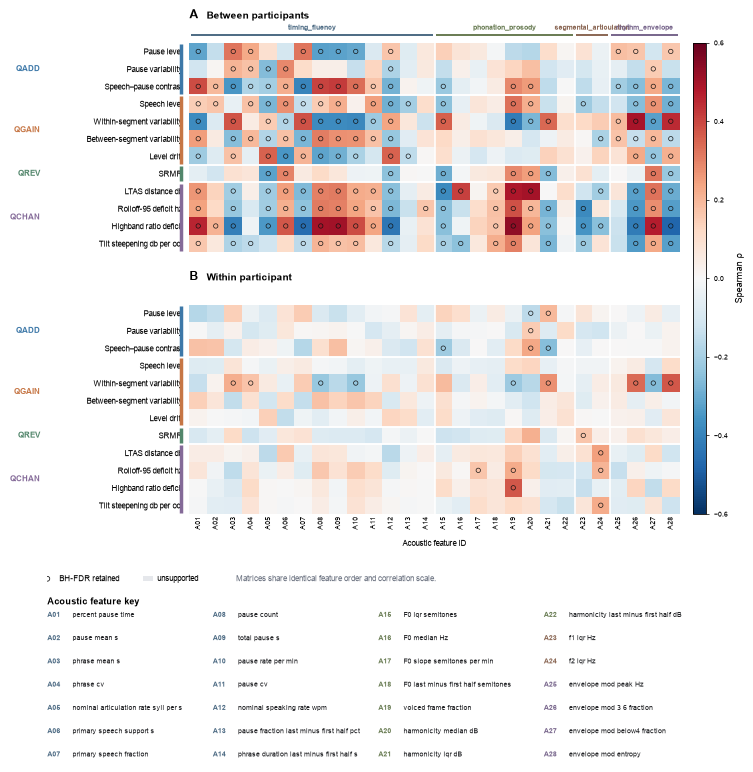

FIGURE 5 V2: WRITTEN
Layout: STACKED / FULL-WIDTH MATRICES
Matrix shape: (12, 28)
Acoustic feature IDs: 28
Between finite cells: 336
Within finite cells: 336
Between BH-FDR retained: 187
Within BH-FDR retained: 22
Observed max |rho|: 0.5302346900112879
Shared symmetric color limit: 0.6
Files: {'.pdf': 'C:\\Users\\musikicn\\Desktop\\Nevena_project\\Paper_2_Leakage\\Code\\outputs\\goal3\\FINAL_FIGURES_REVIEW\\Figure5_Goal3_QA_localization_V2_REVIEW.pdf', '.svg': 'C:\\Users\\musikicn\\Desktop\\Nevena_project\\Paper_2_Leakage\\Code\\outputs\\goal3\\FINAL_FIGURES_REVIEW\\Figure5_Goal3_QA_localization_V2_REVIEW.svg', '.png': 'C:\\Users\\musikicn\\Desktop\\Nevena_project\\Paper_2_Leakage\\Code\\outputs\\goal3\\FINAL_FIGURES_REVIEW\\Figure5_Goal3_QA_localization_V2_REVIEW.png'}


In [15]:
import math
import textwrap


# =====================================================================
# FIGURE 5 V2
# NATURAL Q–A LOCALIZATION
#
# Publication redesign:
#   - vertically stacked matrices
#   - identical Q/A ordering
#   - compact acoustic-feature IDs
#   - full acoustic-feature key beneath figure
#   - acoustic-family brackets
#   - Q-family grouping
#   - open-circle FDR markers
#   - no raw long x-axis labels
# =====================================================================


between = qa_between.copy()
within = qa_within.copy()


# =====================================================================
# CLEAN / NORMALIZE INPUTS
# =====================================================================

for frame in [between, within]:

    frame["q_feature"] = (
        frame["q_feature"]
        .astype(str)
    )

    frame["q_family"] = (
        frame["q_family"]
        .astype(str)
    )

    frame["a_feature"] = (
        frame["a_feature"]
        .astype(str)
    )

    frame["a_family"] = (
        frame["a_family"]
        .astype(str)
    )

    frame["rho"] = pd.to_numeric(
        frame["rho"],
        errors="coerce",
    )

    frame["fdr_retained"] = as_bool(
        frame["fdr_retained"]
    )


# =====================================================================
# FROZEN FEATURE ORDER
# =====================================================================

q_families, q_order = stable_group_order(
    between,
    "q_family",
    "q_feature",
    preferred=[
        "QADD",
        "QGAIN",
        "QREV",
        "QCHAN",
    ],
)


a_families, a_order = stable_group_order(
    between,
    "a_family",
    "a_feature",
)


# =====================================================================
# CONTRACT CHECKS
# =====================================================================

if set(q_order) != set(
    within["q_feature"].unique()
):
    raise RuntimeError(
        "Between/within Q feature sets differ."
    )


if set(a_order) != set(
    within["a_feature"].unique()
):
    raise RuntimeError(
        "Between/within A feature sets differ."
    )


# =====================================================================
# FEATURE -> FAMILY MAPS
# =====================================================================

q_family_map = (
    between[
        [
            "q_feature",
            "q_family",
        ]
    ]
    .drop_duplicates(
        "q_feature"
    )
    .set_index(
        "q_feature"
    )[
        "q_family"
    ]
    .astype(str)
    .to_dict()
)


a_family_map = (
    between[
        [
            "a_feature",
            "a_family",
        ]
    ]
    .drop_duplicates(
        "a_feature"
    )
    .set_index(
        "a_feature"
    )[
        "a_family"
    ]
    .astype(str)
    .to_dict()
)


# =====================================================================
# SHORT ACOUSTIC FEATURE IDs
# =====================================================================

a_code = {
    feature: f"A{i + 1:02d}"
    for i, feature
    in enumerate(a_order)
}


# =====================================================================
# CLEAN FEATURE LABEL FOR THE KEY
# =====================================================================

def feature_key_label(feature):

    label = (
        pretty_a(feature)
        .replace("\n", " ")
        .strip()
    )

    replacements = {
        "bamboo ": "",
        "Bamboo ": "",
        " 300ms": "",
        " 300 ms": "",
        " sec": " s",
        " seconds": " s",
        " syll per sec": " syll/s",
        " syllables per second": " syll/s",
        " hz": " Hz",
        " db": " dB",
    }

    for old, new in replacements.items():
        label = label.replace(
            old,
            new,
        )

    label = " ".join(
        label.split()
    )

    return label


# =====================================================================
# BUILD MATRICES
# =====================================================================

def localization_matrix(frame):

    rho = (
        frame
        .pivot(
            index="q_feature",
            columns="a_feature",
            values="rho",
        )
        .reindex(
            index=q_order,
            columns=a_order,
        )
    )


    ok = (
        frame
        .assign(
            _ok=(
                frame[
                    "status"
                ]
                .astype(str)
                .str.lower()
                .eq("ok")
            )
        )
        .pivot(
            index="q_feature",
            columns="a_feature",
            values="_ok",
        )
        .reindex(
            index=q_order,
            columns=a_order,
        )
        .fillna(False)
    )


    fdr = (
        frame
        .pivot(
            index="q_feature",
            columns="a_feature",
            values="fdr_retained",
        )
        .reindex(
            index=q_order,
            columns=a_order,
        )
        .fillna(False)
    )


    # Explicit writable copies.
    arr = np.array(
        rho,
        dtype=float,
        copy=True,
    )

    ok_arr = np.array(
        ok,
        dtype=bool,
        copy=True,
    )

    fdr_arr = np.array(
        fdr,
        dtype=bool,
        copy=True,
    )


    # Unsupported cells.
    arr[
        ~ok_arr
    ] = np.nan


    # Never show an FDR marker in an unsupported cell.
    fdr_arr = (
        fdr_arr
        & ok_arr
        & np.isfinite(arr)
    )


    return (
        arr,
        fdr_arr,
    )


between_arr, between_fdr = localization_matrix(
    between
)

within_arr, within_fdr = localization_matrix(
    within
)


# =====================================================================
# SHAPE CONTRACT
# =====================================================================

expected_shape = (
    len(q_order),
    len(a_order),
)


for name, arr in [
    (
        "between",
        between_arr,
    ),
    (
        "within",
        within_arr,
    ),
]:

    if arr.shape != expected_shape:

        raise RuntimeError(
            f"{name} localization matrix "
            f"has shape {arr.shape}; "
            f"expected {expected_shape}."
        )


# =====================================================================
# SAVE SOURCE TABLES
# =====================================================================

between_export = between.copy()
between_export[
    "a_code"
] = between_export[
    "a_feature"
].map(
    a_code
)


within_export = within.copy()
within_export[
    "a_code"
] = within_export[
    "a_feature"
].map(
    a_code
)


feature_key = pd.DataFrame({
    "a_code": [
        a_code[f]
        for f in a_order
    ],
    "a_feature": a_order,
    "display_label": [
        feature_key_label(f)
        for f in a_order
    ],
    "a_family": [
        a_family_map[f]
        for f in a_order
    ],
})


atomic_csv(
    between_export,
    SOURCE_TABLES
    / "Figure5V2_between_source.csv",
)

atomic_csv(
    within_export,
    SOURCE_TABLES
    / "Figure5V2_within_source.csv",
)

atomic_csv(
    feature_key,
    SOURCE_TABLES
    / "Figure5V2_acoustic_feature_key.csv",
)


# =====================================================================
# CORRELATION COLOR RANGE
#
# Use the full observed finite range, rounded upward to a clean
# symmetric limit. Nothing is saturated.
# =====================================================================

finite_rho = np.concatenate([
    between_arr[
        np.isfinite(
            between_arr
        )
    ],
    within_arr[
        np.isfinite(
            within_arr
        )
    ],
])


if not len(finite_rho):
    raise RuntimeError(
        "No finite localization coefficients."
    )


observed_abs_max = float(
    np.max(
        np.abs(
            finite_rho
        )
    )
)


rho_limit = (
    math.ceil(
        observed_abs_max
        * 10
    )
    / 10
)


rho_limit = float(
    np.clip(
        rho_limit,
        0.30,
        1.00,
    )
)


print(
    "Observed max |rho|:",
    observed_abs_max,
)

print(
    "Figure color limit:",
    rho_limit,
)


# =====================================================================
# COLOR MAP
# =====================================================================

cmap = mpl.colormaps[
    "RdBu_r"
].copy()


cmap.set_bad(
    "#E5E7EB"
)


# =====================================================================
# SUBTLE A-FAMILY COLORS FOR THE FEATURE KEY ONLY
# =====================================================================

muted_family_colors = [
    "#4C6A83",
    "#687B52",
    "#8A6653",
    "#77658B",
    "#7B7272",
    "#527A78",
    "#796F4D",
    "#667080",
]


A_GROUP_COLOR = {
    fam: muted_family_colors[
        i
        % len(
            muted_family_colors
        )
    ]
    for i, fam
    in enumerate(
        a_families
    )
}


# =====================================================================
# FIGURE
# =====================================================================

fig = plt.figure(
    figsize=(
        190 * MM_TO_IN,
        210 * MM_TO_IN,
    ),
    facecolor="white",
)


# Two heatmaps + shared colorbar.
gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
    width_ratios=[
        1,
        0.025,
    ],
    height_ratios=[
        1,
        1,
    ],
    left=0.245,
    right=0.935,
    top=0.925,
    bottom=0.355,
    hspace=0.25,
    wspace=0.055,
)


ax_between = fig.add_subplot(
    gs[
        0,
        0,
    ]
)


ax_within = fig.add_subplot(
    gs[
        1,
        0,
    ]
)


cax = fig.add_subplot(
    gs[
        :,
        1,
    ]
)


axes = [
    ax_between,
    ax_within,
]


# =====================================================================
# HELPER: Q-FAMILY LABELS
# =====================================================================

def add_q_family_labels(ax):

    n_q = len(
        q_order
    )


    cursor = 0

    for family in q_families:

        members = [
            q
            for q in q_order
            if q_family_map[
                q
            ]
            == family
        ]


        if not members:
            continue


        n = len(
            members
        )


        # Center expressed in axes coordinates.
        center_row = (
            cursor
            + (
                n - 1
            )
            / 2
        )


        y_axes = (
            1
            - (
                center_row
                + 0.5
            )
            / n_q
        )


        ax.text(
            -0.305,
            y_axes,
            family,
            transform=ax.transAxes,
            ha="right",
            va="center",
            fontsize=5.5,
            fontweight="bold",
            color=FAMILY_PALETTE.get(
                family,
                NEUTRAL,
            ),
            clip_on=False,
        )


        # Small family bar immediately beside matrix.
        y_top = (
            1
            - cursor
            / n_q
        )

        y_bottom = (
            1
            - (
                cursor
                + n
            )
            / n_q
        )


        ax.plot(
            [
                -0.018,
                -0.018,
            ],
            [
                y_bottom + 0.006,
                y_top - 0.006,
            ],
            transform=ax.transAxes,
            color=FAMILY_PALETTE.get(
                family,
                NEUTRAL,
            ),
            linewidth=2.5,
            solid_capstyle="butt",
            clip_on=False,
        )


        cursor += n


# =====================================================================
# HELPER: ACOUSTIC-FAMILY BRACKETS
# =====================================================================

def add_a_family_brackets(ax):

    n_a = len(
        a_order
    )


    cursor = 0


    for family in a_families:

        members = [
            a
            for a in a_order
            if a_family_map[
                a
            ]
            == family
        ]


        if not members:
            continue


        n = len(
            members
        )


        x0 = (
            cursor
            / n_a
        )

        x1 = (
            (
                cursor
                + n
            )
            / n_a
        )


        center = (
            (
                x0
                + x1
            )
            / 2
        )


        ax.plot(
            [
                x0 + 0.004,
                x1 - 0.004,
            ],
            [
                1.035,
                1.035,
            ],
            transform=ax.transAxes,
            color=A_GROUP_COLOR[
                family
            ],
            linewidth=1.4,
            solid_capstyle="butt",
            clip_on=False,
        )


        ax.text(
            center,
            1.055,
            str(
                family
            ),
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=5.0,
            fontweight="bold",
            color=A_GROUP_COLOR[
                family
            ],
            clip_on=False,
        )


        cursor += n


# =====================================================================
# DRAW HEATMAPS
# =====================================================================

images = []


for panel_index, (
    ax,
    arr,
    fdr,
    panel_letter,
    panel_title,
) in enumerate([
    (
        ax_between,
        between_arr,
        between_fdr,
        "A",
        "Between participants",
    ),
    (
        ax_within,
        within_arr,
        within_fdr,
        "B",
        "Within participant",
    ),
]):

    im = ax.imshow(
        arr,
        aspect="auto",
        interpolation="none",
        cmap=cmap,
        vmin=-rho_limit,
        vmax=rho_limit,
    )


    images.append(
        im
    )


    # -------------------------------------------------------------
    # FDR retained:
    # open circles preserve underlying correlation color.
    # -------------------------------------------------------------

    yy, xx = np.where(
        fdr
        & np.isfinite(
            arr
        )
    )


    ax.scatter(
        xx,
        yy,
        s=10,
        marker="o",
        facecolors="none",
        edgecolors="#111111",
        linewidths=0.48,
        zorder=4,
    )


    # -------------------------------------------------------------
    # Y AXIS
    # -------------------------------------------------------------

    ax.set_yticks(
        np.arange(
            len(
                q_order
            )
        )
    )


    ax.set_yticklabels(
        [
            pretty_q(
                q
            )
            for q
            in q_order
        ],
        fontsize=5.5,
    )


    ax.tick_params(
        axis="y",
        length=0,
        pad=5,
    )


    # -------------------------------------------------------------
    # X AXIS
    # -------------------------------------------------------------

    ax.set_xticks(
        np.arange(
            len(
                a_order
            )
        )
    )


    if panel_index == 0:

        ax.set_xticklabels(
            []
        )

        ax.tick_params(
            axis="x",
            length=0,
        )

    else:

        ax.set_xticklabels(
            [
                a_code[
                    feature
                ]
                for feature
                in a_order
            ],
            rotation=90,
            ha="center",
            va="top",
            fontsize=5.0,
        )


        ax.tick_params(
            axis="x",
            length=0,
            pad=2,
        )


        ax.set_xlabel(
            "Acoustic feature ID",
            fontsize=6.0,
            labelpad=7,
        )


    # -------------------------------------------------------------
    # PANEL TITLE
    # -------------------------------------------------------------

    ax.text(
        0.0,
        1.105,
        panel_letter,
        transform=ax.transAxes,
        fontsize=8.7,
        fontweight="bold",
        ha="left",
        va="bottom",
        clip_on=False,
    )


    ax.text(
        0.035,
        1.105,
        panel_title,
        transform=ax.transAxes,
        fontsize=7.3,
        fontweight="bold",
        ha="left",
        va="bottom",
        clip_on=False,
    )


    # -------------------------------------------------------------
    # HORIZONTAL Q-FAMILY SEPARATORS
    # -------------------------------------------------------------

    cursor = 0


    for family in q_families:

        members = [
            q
            for q in q_order
            if q_family_map[
                q
            ]
            == family
        ]


        if cursor > 0:

            ax.axhline(
                cursor - 0.5,
                color="white",
                linewidth=1.35,
                zorder=3,
            )


        cursor += len(
            members
        )


    # -------------------------------------------------------------
    # VERTICAL A-FAMILY SEPARATORS
    # -------------------------------------------------------------

    cursor = 0


    for family in a_families:

        members = [
            a
            for a in a_order
            if a_family_map[
                a
            ]
            == family
        ]


        if cursor > 0:

            ax.axvline(
                cursor - 0.5,
                color="white",
                linewidth=1.15,
                zorder=3,
            )


        cursor += len(
            members
        )


    # -------------------------------------------------------------
    # FRAME
    # -------------------------------------------------------------

    for spine in ax.spines.values():

        spine.set_visible(
            False
        )


    add_q_family_labels(
        ax
    )


# Acoustic-family headings only once,
# above the first aligned matrix.
add_a_family_brackets(
    ax_between
)


# =====================================================================
# SHARED COLORBAR
# =====================================================================

cb = fig.colorbar(
    images[0],
    cax=cax,
)


cb.set_label(
    "Spearman ρ",
    fontsize=6.3,
    labelpad=5,
)


cb.ax.tick_params(
    labelsize=5.3,
    width=0.5,
    length=2.5,
)


cb.outline.set_linewidth(
    0.6
)


# =====================================================================
# FEATURE KEY AREA
# =====================================================================

key_ax = fig.add_axes([
    0.055,
    0.055,
    0.885,
    0.225,
])


key_ax.axis(
    "off"
)


# -------------------------------------------------------------
# Legend / interpretation line
# -------------------------------------------------------------

key_ax.scatter(
    [0.0],
    [0.985],
    s=12,
    marker="o",
    facecolors="none",
    edgecolors="#111111",
    linewidths=0.55,
    transform=key_ax.transAxes,
)


key_ax.text(
    0.018,
    0.985,
    "BH-FDR retained",
    transform=key_ax.transAxes,
    fontsize=5.5,
    va="center",
    ha="left",
)


key_ax.add_patch(
    mpl.patches.Rectangle(
        (
            0.145,
            0.972,
        ),
        0.014,
        0.027,
        transform=key_ax.transAxes,
        facecolor="#E5E7EB",
        edgecolor="none",
    )
)


key_ax.text(
    0.166,
    0.985,
    "unsupported",
    transform=key_ax.transAxes,
    fontsize=5.5,
    va="center",
    ha="left",
)


key_ax.text(
    0.285,
    0.985,
    (
        "Matrices share identical feature order "
        "and correlation scale."
    ),
    transform=key_ax.transAxes,
    fontsize=5.5,
    va="center",
    ha="left",
    color=NEUTRAL,
)


# -------------------------------------------------------------
# Acoustic feature key
# -------------------------------------------------------------

key_ax.text(
    0.0,
    0.885,
    "Acoustic feature key",
    transform=key_ax.transAxes,
    fontsize=6.3,
    fontweight="bold",
    ha="left",
    va="top",
)


n_items = len(
    a_order
)


n_columns = 4


n_rows = int(
    math.ceil(
        n_items
        / n_columns
    )
)


column_width = (
    1.0
    / n_columns
)


top_y = 0.79


bottom_y = 0.04


row_step = (
    (
        top_y
        - bottom_y
    )
    / max(
        n_rows - 1,
        1,
    )
)


for index, feature in enumerate(
    a_order
):

    col = (
        index
        // n_rows
    )


    row = (
        index
        % n_rows
    )


    x = (
        col
        * column_width
    )


    y = (
        top_y
        - row
        * row_step
    )


    family = a_family_map[
        feature
    ]


    code = a_code[
        feature
    ]


    label = feature_key_label(
        feature
    )


    # Keep the key compact but never collide.
    wrapped = textwrap.wrap(
        label,
        width=34,
        break_long_words=False,
        break_on_hyphens=False,
    )


    if len(wrapped) > 1:

        key_text = (
            wrapped[0]
            + " "
            + wrapped[1]
        )

    else:

        key_text = label


    key_ax.text(
        x,
        y,
        code,
        transform=key_ax.transAxes,
        fontsize=5.1,
        fontweight="bold",
        color=A_GROUP_COLOR.get(
            family,
            "#4B5563",
        ),
        ha="left",
        va="center",
    )


    key_ax.text(
        x + 0.038,
        y,
        key_text,
        transform=key_ax.transAxes,
        fontsize=4.75,
        color="#202124",
        ha="left",
        va="center",
    )


# =====================================================================
# EXPORT
# =====================================================================

figure5_v2_files = save_figure(
    fig,
    "Figure5_Goal3_QA_localization_V2_REVIEW",
    [
        PATHS[
            "qa_between"
        ],
        PATHS[
            "qa_within"
        ],
    ],
)


plt.show()


# =====================================================================
# AUDIT
# =====================================================================

print(
    "=" * 78
)

print(
    "FIGURE 5 V2: WRITTEN"
)

print(
    "=" * 78
)

print(
    "Layout:",
    "STACKED / FULL-WIDTH MATRICES",
)

print(
    "Matrix shape:",
    expected_shape,
)

print(
    "Acoustic feature IDs:",
    len(
        a_code
    ),
)

print(
    "Between finite cells:",
    int(
        np.isfinite(
            between_arr
        ).sum()
    ),
)

print(
    "Within finite cells:",
    int(
        np.isfinite(
            within_arr
        ).sum()
    ),
)

print(
    "Between BH-FDR retained:",
    int(
        between_fdr.sum()
    ),
)

print(
    "Within BH-FDR retained:",
    int(
        within_fdr.sum()
    ),
)

print(
    "Observed max |rho|:",
    observed_abs_max,
)

print(
    "Shared symmetric color limit:",
    rho_limit,
)

print(
    "Files:",
    figure5_v2_files,
)


## 4. Figure 6 — controlled perturbation response

Each column is one frozen physical transformation. Rows show the ordered pipeline: target Q → acoustic representation → clinical model output → prediction error.

Panel A and B use the diagnosis source set, matching the Stage-E source-display convention. Clinical rows use their task-specific held-out source sets. Curves are descriptive participant means with 95% normal intervals where applicable; formal dose-response inference remains in the frozen GEE/bootstrap tables.


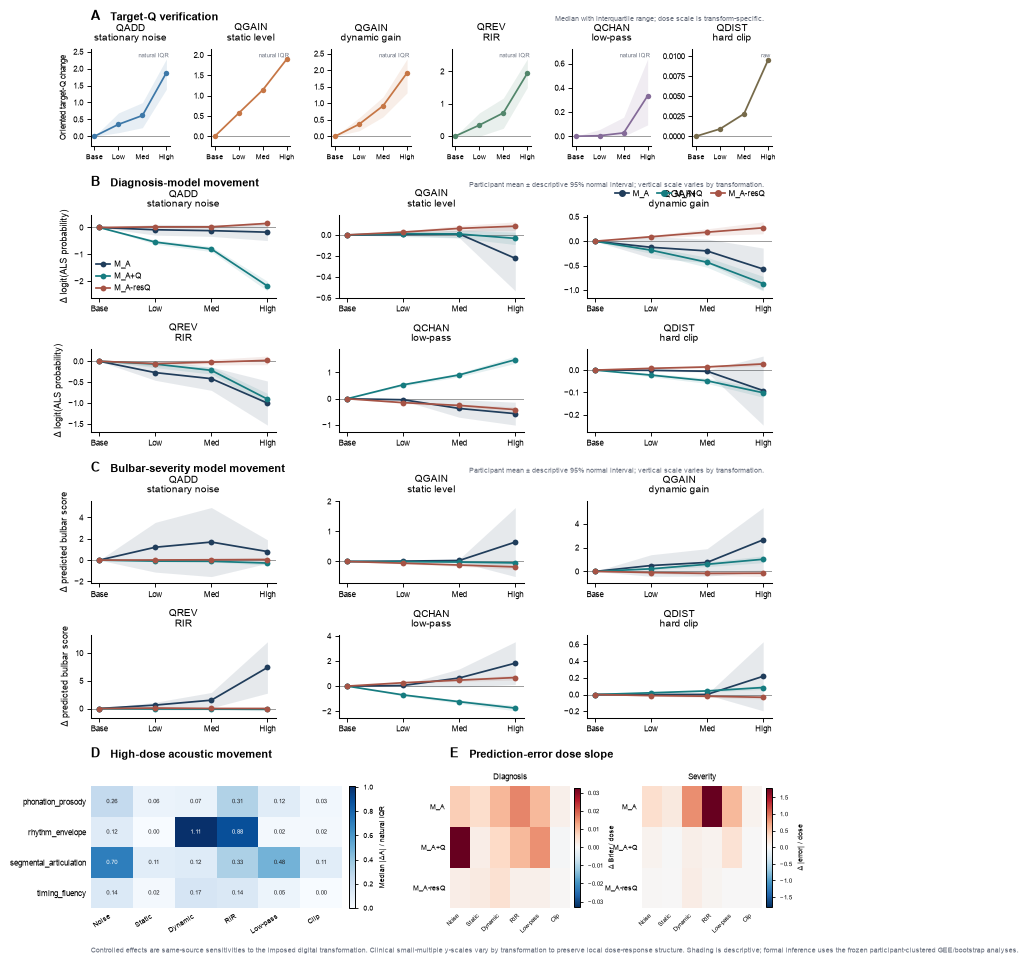

FIGURE 6 V2: WRITTEN
Panel A: target-Q verification
Panel B: diagnosis 2 x 3 small multiples
Panel C: severity 2 x 3 small multiples
Panel D: high-dose acoustic-family movement
Panel E: formal prediction-error dose slopes
Clinical y scales: TRANSFORM-SPECIFIC
Files: {'.pdf': 'C:\\Users\\musikicn\\Desktop\\Nevena_project\\Paper_2_Leakage\\Code\\outputs\\goal3\\FINAL_FIGURES_REVIEW\\Figure6_Goal3_controlled_pipeline_V2_REVIEW.pdf', '.svg': 'C:\\Users\\musikicn\\Desktop\\Nevena_project\\Paper_2_Leakage\\Code\\outputs\\goal3\\FINAL_FIGURES_REVIEW\\Figure6_Goal3_controlled_pipeline_V2_REVIEW.svg', '.png': 'C:\\Users\\musikicn\\Desktop\\Nevena_project\\Paper_2_Leakage\\Code\\outputs\\goal3\\FINAL_FIGURES_REVIEW\\Figure6_Goal3_controlled_pipeline_V2_REVIEW.png'}


In [16]:
# =====================================================================
# FIGURE 6 V2
# CONTROLLED SAME-SOURCE PERTURBATION RESPONSE
#
# Publication redesign:
#   A. Target-Q verification
#   B. Diagnosis model movement — 2 x 3 small multiples
#   C. Severity model movement — 2 x 3 small multiples
#   D. High-dose acoustic-family movement
#   E. Prediction-error dose slopes
#
# Clinical panels intentionally use transform-specific y limits,
# matching the clear source-figure style.
# =====================================================================


# ---------------------------------------------------------------------
# SOURCE DATA
# ---------------------------------------------------------------------

target_dx = (
    target_q.loc[
        target_q["task"].eq("diagnosis")
    ]
    .copy()
)


a_dx = (
    a_family.loc[
        a_family["task"].eq("diagnosis")
    ]
    .copy()
)


def clinical_summary(
    task,
    endpoint,
):

    d = (
        prediction_delta.loc[
            prediction_delta["task"].eq(task)
        ]
        .copy()
    )

    d[endpoint] = pd.to_numeric(
        d[endpoint],
        errors="coerce",
    )

    s = (
        d.groupby(
            [
                "transform",
                "model",
                "dose_code",
            ],
            as_index=False,
        )
        .agg(
            mean=(
                endpoint,
                "mean",
            ),
            sem=(
                endpoint,
                "sem",
            ),
            n=(
                endpoint,
                lambda x: int(
                    pd.to_numeric(
                        x,
                        errors="coerce",
                    )
                    .notna()
                    .sum()
                ),
            ),
        )
    )

    s["lo"] = (
        s["mean"]
        - 1.96
        * s["sem"].fillna(0)
    )

    s["hi"] = (
        s["mean"]
        + 1.96
        * s["sem"].fillna(0)
    )

    return s


dx_move = clinical_summary(
    "diagnosis",
    "delta_logit",
)


sev_move = clinical_summary(
    "severity",
    "delta_prediction",
)


dx_err = clinical_summary(
    "diagnosis",
    "delta_error",
)


sev_err = clinical_summary(
    "severity",
    "delta_error",
)


# ---------------------------------------------------------------------
# SOURCE EXPORTS
# ---------------------------------------------------------------------

atomic_csv(
    target_dx,
    SOURCE_TABLES
    / "Figure6V2_A_targetQ_source.csv",
)

atomic_csv(
    a_dx,
    SOURCE_TABLES
    / "Figure6V2_D_Afamily_source.csv",
)

atomic_csv(
    dx_move,
    SOURCE_TABLES
    / "Figure6V2_B_diagnosis_source.csv",
)

atomic_csv(
    sev_move,
    SOURCE_TABLES
    / "Figure6V2_C_severity_source.csv",
)

atomic_csv(
    dx_err,
    SOURCE_TABLES
    / "Figure6V2_E1_diagnosis_error_source.csv",
)

atomic_csv(
    sev_err,
    SOURCE_TABLES
    / "Figure6V2_E2_severity_error_source.csv",
)


# =====================================================================
# DISPLAY LABELS
# =====================================================================

TRANSFORM_PANEL_TITLE = {
    "stationary_colored_broadband": (
        "QADD",
        "stationary noise",
    ),
    "uniform_level_shift": (
        "QGAIN",
        "static level",
    ),
    "smooth_time_varying_gain": (
        "QGAIN",
        "dynamic gain",
    ),
    "RIR_convolution_RMS_matched": (
        "QREV",
        "RIR",
    ),
    "upper_band_restriction": (
        "QCHAN",
        "low-pass",
    ),
    "symmetric_hard_clipping": (
        "QDIST",
        "hard clip",
    ),
}


DOSE_TICKS = [
    0,
    1,
    2,
    3,
]


DOSE_NAMES = [
    "Base",
    "Low",
    "Med",
    "High",
]


# =====================================================================
# ACOUSTIC-FAMILY COLORS
# =====================================================================

a_fams = (
    a_dx[
        "feature_family"
    ]
    .dropna()
    .astype(str)
    .drop_duplicates()
    .tolist()
)


# Muted, publication-style palette.
A_FAMILY_PALETTE = {}


base_colors = [
    "#4E79A7",
    "#59A14F",
    "#F28E2B",
    "#B07AA1",
    "#76B7B2",
    "#9C755F",
    "#79706E",
    "#EDC948",
]


for i, fam in enumerate(
    a_fams
):

    A_FAMILY_PALETTE[
        fam
    ] = base_colors[
        i
        % len(
            base_colors
        )
    ]


# =====================================================================
# HELPERS
# =====================================================================

def local_limits(
    values,
    *,
    pad_fraction=0.12,
):

    arr = np.asarray(
        values,
        dtype=float,
    )

    arr = arr[
        np.isfinite(
            arr
        )
    ]

    arr = np.r_[
        arr,
        0.0,
    ]


    if not len(
        arr
    ):

        return (
            -1.0,
            1.0,
        )


    lo = float(
        np.min(
            arr
        )
    )

    hi = float(
        np.max(
            arr
        )
    )


    if math.isclose(
        lo,
        hi,
    ):

        pad = max(
            0.05,
            abs(
                lo
            )
            * 0.20,
        )

    else:

        pad = (
            hi
            - lo
        ) * pad_fraction


    return (
        lo - pad,
        hi + pad,
    )


def publication_axis(
    ax,
    *,
    zero=True,
):

    if zero:

        ax.axhline(
            0,
            color="#9A9A9A",
            linewidth=0.70,
            zorder=0,
        )


    ax.spines[
        "top"
    ].set_visible(
        False
    )

    ax.spines[
        "right"
    ].set_visible(
        False
    )

    ax.spines[
        "left"
    ].set_linewidth(
        0.75
    )

    ax.spines[
        "bottom"
    ].set_linewidth(
        0.75
    )


    ax.tick_params(
        direction="out",
        width=0.65,
        length=3.0,
        pad=2.5,
    )


    ax.grid(
        False
    )


def add_transform_title(
    ax,
    transform,
):

    family_label, name = (
        TRANSFORM_PANEL_TITLE[
            transform
        ]
    )

    ax.set_title(
        (
            f"{family_label}\n"
            f"{name}"
        ),
        fontsize=7.3,
        fontweight="normal",
        pad=6,
        linespacing=1.08,
    )


def add_section_title(
    fig,
    first_ax,
    letter,
    title,
    *,
    right_text=None,
):

    box = (
        first_ax
        .get_position()
    )


    y = (
        box.y1
        + 0.027
    )


    fig.text(
        box.x0,
        y,
        letter,
        fontsize=9.2,
        fontweight="bold",
        ha="left",
        va="bottom",
    )


    fig.text(
        box.x0
        + 0.026,
        y,
        title,
        fontsize=7.6,
        fontweight="bold",
        ha="left",
        va="bottom",
    )


    if right_text is not None:

        fig.text(
            0.975,
            y,
            right_text,
            fontsize=5.3,
            color=NEUTRAL,
            ha="right",
            va="bottom",
        )


def plot_clinical_small_multiple(
    ax,
    summary,
    transform,
    endpoint_label,
    *,
    show_ylabel=False,
    show_legend=False,
):

    g = (
        summary.loc[
            summary[
                "transform"
            ].eq(
                transform
            )
        ]
        .copy()
    )


    all_limits = [
        0.0,
    ]


    for model in MODELS:

        h = (
            g.loc[
                g[
                    "model"
                ].eq(
                    model
                )
            ]
            .sort_values(
                "dose_code"
            )
        )


        if h.empty:
            continue


        x = np.r_[
            0.0,
            h[
                "dose_code"
            ]
            .to_numpy(
                float
            ),
        ]


        y = np.r_[
            0.0,
            h[
                "mean"
            ]
            .to_numpy(
                float
            ),
        ]


        lo = np.r_[
            0.0,
            h[
                "lo"
            ]
            .to_numpy(
                float
            ),
        ]


        hi = np.r_[
            0.0,
            h[
                "hi"
            ]
            .to_numpy(
                float
            ),
        ]


        all_limits.extend(
            lo.tolist()
        )

        all_limits.extend(
            hi.tolist()
        )


        ax.fill_between(
            x,
            lo,
            hi,
            color=MODEL_PALETTE[
                model
            ],
            alpha=0.11,
            linewidth=0,
            zorder=1,
        )


        ax.plot(
            x,
            y,
            color=MODEL_PALETTE[
                model
            ],
            linewidth=1.25,
            marker="o",
            markersize=4.2,
            markeredgewidth=0,
            label=model,
            zorder=3,
        )


    ax.set_ylim(
        *local_limits(
            all_limits,
            pad_fraction=0.10,
        )
    )


    ax.set_xticks(
        DOSE_TICKS
    )


    ax.set_xticklabels(
        DOSE_NAMES,
        fontsize=5.8,
    )


    if show_ylabel:

        ax.set_ylabel(
            endpoint_label,
            fontsize=6.2,
            labelpad=4,
        )


    add_transform_title(
        ax,
        transform,
    )


    publication_axis(
        ax,
        zero=True,
    )


    if show_legend:

        ax.legend(
            frameon=False,
            fontsize=5.6,
            loc="best",
            handlelength=1.8,
            handletextpad=0.5,
            borderaxespad=0.3,
        )


# =====================================================================
# FIGURE CONSTRUCTION
# =====================================================================

fig = plt.figure(
    figsize=(
        190 * MM_TO_IN,
        248 * MM_TO_IN,
    ),
    facecolor="white",
)


outer = fig.add_gridspec(
    nrows=4,
    ncols=1,
    height_ratios=[
        0.92,
        2.05,
        2.05,
        1.15,
    ],
    left=0.075,
    right=0.985,
    top=0.955,
    bottom=0.075,
    hspace=0.42,
)


# =====================================================================
# PANEL A — TARGET-Q VERIFICATION
# =====================================================================

gs_a = (
    outer[
        0,
        0,
    ]
    .subgridspec(
        1,
        6,
        wspace=0.52,
    )
)


axes_a = []


for j, transform in enumerate(
    TRANSFORM_ORDER
):

    ax = fig.add_subplot(
        gs_a[
            0,
            j,
        ]
    )

    axes_a.append(
        ax
    )


    g = (
        target_dx.loc[
            target_dx[
                "transform"
            ].eq(
                transform
            )
        ]
        .sort_values(
            "dose_code"
        )
        .copy()
    )


    if g.empty:

        raise RuntimeError(
            "Missing diagnosis target-Q "
            f"source for {transform}."
        )


    x = np.r_[
        0.0,
        g[
            "dose_code"
        ]
        .to_numpy(
            float
        ),
    ]


    y = np.r_[
        0.0,
        g[
            "median_oriented_delta"
        ]
        .to_numpy(
            float
        ),
    ]


    lo = np.r_[
        0.0,
        g[
            "q25_oriented_delta"
        ]
        .to_numpy(
            float
        ),
    ]


    hi = np.r_[
        0.0,
        g[
            "q75_oriented_delta"
        ]
        .to_numpy(
            float
        ),
    ]


    family = str(
        g[
            "family"
        ].iloc[
            0
        ]
    )


    color = FAMILY_PALETTE.get(
        family,
        NEUTRAL,
    )


    ax.fill_between(
        x,
        lo,
        hi,
        color=color,
        alpha=0.12,
        linewidth=0,
    )


    ax.plot(
        x,
        y,
        color=color,
        linewidth=1.25,
        marker="o",
        markersize=3.9,
        markeredgewidth=0,
    )


    ax.set_ylim(
        *local_limits(
            np.r_[
                lo,
                hi,
            ],
            pad_fraction=0.13,
        )
    )


    ax.set_xticks(
        DOSE_TICKS
    )


    ax.set_xticklabels(
        DOSE_NAMES,
        fontsize=5.2,
    )


    add_transform_title(
        ax,
        transform,
    )


    publication_axis(
        ax,
        zero=True,
    )


    scale = str(
        g[
            "scale"
        ].iloc[
            0
        ]
    )


    scale_text = (
        "natural IQR"
        if scale.lower()
        == "natural iqr"
        else "raw"
    )


    ax.text(
        0.98,
        0.96,
        scale_text,
        transform=ax.transAxes,
        fontsize=4.4,
        color=NEUTRAL,
        ha="right",
        va="top",
    )


    if j == 0:

        ax.set_ylabel(
            "Oriented target-Q change",
            fontsize=5.9,
            labelpad=4,
        )


add_section_title(
    fig,
    axes_a[
        0
    ],
    "A",
    "Target-Q verification",
    right_text=(
        "Median with interquartile range; "
        "dose scale is transform-specific."
    ),
)


# =====================================================================
# PANEL B — DIAGNOSIS MODEL MOVEMENT
# =====================================================================

gs_b = (
    outer[
        1,
        0,
    ]
    .subgridspec(
        2,
        3,
        hspace=0.62,
        wspace=0.34,
    )
)


axes_b = []


for j, transform in enumerate(
    TRANSFORM_ORDER
):

    row = (
        j
        // 3
    )

    col = (
        j
        % 3
    )


    ax = fig.add_subplot(
        gs_b[
            row,
            col,
        ]
    )


    axes_b.append(
        ax
    )


    plot_clinical_small_multiple(
        ax,
        dx_move,
        transform,
        "Δ logit(ALS probability)",
        show_ylabel=(
            col
            == 0
        ),
        show_legend=(
            j
            == 0
        ),
    )


add_section_title(
    fig,
    axes_b[
        0
    ],
    "B",
    "Diagnosis-model movement",
    right_text=(
        "Participant mean ± descriptive 95% normal interval; "
        "vertical scale varies by transformation."
    ),
)


# =====================================================================
# PANEL C — SEVERITY MODEL MOVEMENT
# =====================================================================

gs_c = (
    outer[
        2,
        0,
    ]
    .subgridspec(
        2,
        3,
        hspace=0.62,
        wspace=0.34,
    )
)


axes_c = []


for j, transform in enumerate(
    TRANSFORM_ORDER
):

    row = (
        j
        // 3
    )

    col = (
        j
        % 3
    )


    ax = fig.add_subplot(
        gs_c[
            row,
            col,
        ]
    )


    axes_c.append(
        ax
    )


    plot_clinical_small_multiple(
        ax,
        sev_move,
        transform,
        "Δ predicted bulbar score",
        show_ylabel=(
            col
            == 0
        ),
        show_legend=False,
    )


add_section_title(
    fig,
    axes_c[
        0
    ],
    "C",
    "Bulbar-severity model movement",
    right_text=(
        "Participant mean ± descriptive 95% normal interval; "
        "vertical scale varies by transformation."
    ),
)


# =====================================================================
# BOTTOM ROW:
# PANEL D — ACOUSTIC MOVEMENT
# PANEL E — ERROR-DOSE SLOPES
# =====================================================================

gs_bottom = (
    outer[
        3,
        0,
    ]
    .subgridspec(
        1,
        2,
        width_ratios=[
            1.05,
            1.25,
        ],
        wspace=0.30,
    )
)


# =====================================================================
# PANEL D
# HIGH-DOSE ACOUSTIC-FAMILY MOVEMENT
# =====================================================================

ax_d = fig.add_subplot(
    gs_bottom[
        0,
        0,
    ]
)


a_high = (
    a_dx.loc[
        pd.to_numeric(
            a_dx[
                "dose_code"
            ],
            errors="coerce",
        ).eq(
            3
        )
    ]
    .copy()
)


a_high_summary = (
    a_high.groupby(
        [
            "feature_family",
            "transform",
        ],
        as_index=False,
    )
    .agg(
        median_movement=(
            "median_movement",
            "median",
        )
    )
)


a_heat = (
    a_high_summary
    .pivot(
        index="feature_family",
        columns="transform",
        values="median_movement",
    )
    .reindex(
        index=a_fams,
        columns=TRANSFORM_ORDER,
    )
)


a_matrix = np.array(
    a_heat,
    dtype=float,
    copy=True,
)


if np.isfinite(
    a_matrix
).any():

    a_vmax = float(
        np.nanquantile(
            a_matrix,
            0.98,
        )
    )

else:

    a_vmax = 1.0


a_vmax = max(
    a_vmax,
    0.05,
)


a_cmap = (
    mpl.colormaps[
        "Blues"
    ]
    .copy()
)


a_cmap.set_bad(
    "#E5E7EB"
)


im_d = ax_d.imshow(
    a_matrix,
    aspect="auto",
    interpolation="none",
    cmap=a_cmap,
    vmin=0,
    vmax=a_vmax,
)


ax_d.set_yticks(
    np.arange(
        len(
            a_fams
        )
    )
)


ax_d.set_yticklabels(
    a_fams,
    fontsize=5.5,
)


ax_d.set_xticks(
    np.arange(
        len(
            TRANSFORM_ORDER
        )
    )
)


ax_d.set_xticklabels(
    [
        TRANSFORM_SHORT[
            transform
        ]
        for transform
        in TRANSFORM_ORDER
    ],
    rotation=32,
    ha="right",
    fontsize=5.3,
)


ax_d.tick_params(
    length=0,
)


for spine in ax_d.spines.values():

    spine.set_visible(
        False
    )


# Small value annotations only where finite.
for i in range(
    a_matrix.shape[
        0
    ]
):

    for j in range(
        a_matrix.shape[
            1
        ]
    ):

        value = a_matrix[
            i,
            j,
        ]


        if not np.isfinite(
            value
        ):
            continue


        text_color = (
            "white"
            if value
            > 0.58
            * a_vmax
            else "#202124"
        )


        ax_d.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=4.4,
            color=text_color,
        )


cb_d = fig.colorbar(
    im_d,
    ax=ax_d,
    fraction=0.045,
    pad=0.025,
)


cb_d.ax.tick_params(
    labelsize=4.7,
)


cb_d.set_label(
    "Median |ΔA| / natural IQR",
    fontsize=5.2,
)


# Save clean source.
atomic_csv(
    a_high_summary,
    SOURCE_TABLES
    / "Figure6V2_D_highdose_acoustic_movement.csv",
)


# =====================================================================
# PANEL E
# FORMAL ERROR-DOSE SLOPES
# =====================================================================

gs_e = (
    gs_bottom[
        0,
        1,
    ]
    .subgridspec(
        1,
        2,
        wspace=0.48,
    )
)


ax_e_dx = fig.add_subplot(
    gs_e[
        0,
        0,
    ]
)


ax_e_sev = fig.add_subplot(
    gs_e[
        0,
        1,
    ]
)


def error_slope_matrix(
    task,
):

    d = (
        clinical_linear.loc[
            clinical_linear[
                "task"
            ].eq(
                task
            )
            & clinical_linear[
                "endpoint"
            ].eq(
                "delta_error"
            )
            & clinical_linear[
                "model"
            ].isin(
                MODELS
            )
        ]
        .copy()
    )


    pivot = (
        d.pivot(
            index="model",
            columns="transform",
            values="estimate",
        )
        .reindex(
            index=MODELS,
            columns=TRANSFORM_ORDER,
        )
    )


    return (
        d,
        pivot,
    )


def plot_error_heatmap(
    ax,
    task,
    title,
    colorbar_label,
):

    d, pivot = (
        error_slope_matrix(
            task
        )
    )


    matrix = np.array(
        pivot,
        dtype=float,
        copy=True,
    )


    finite = np.abs(
        matrix[
            np.isfinite(
                matrix
            )
        ]
    )


    vmax = (
        float(
            np.quantile(
                finite,
                0.98,
            )
        )
        if len(
            finite
        )
        else 1.0
    )


    vmax = max(
        vmax,
        1e-6,
    )


    cmap_local = (
        mpl.colormaps[
            "RdBu_r"
        ]
        .copy()
    )


    cmap_local.set_bad(
        "#E5E7EB"
    )


    im = ax.imshow(
        matrix,
        aspect="auto",
        interpolation="none",
        cmap=cmap_local,
        vmin=-vmax,
        vmax=vmax,
    )


    ax.set_yticks(
        np.arange(
            len(
                MODELS
            )
        )
    )


    ax.set_yticklabels(
        MODELS,
        fontsize=5.2,
    )


    ax.set_xticks(
        np.arange(
            len(
                TRANSFORM_ORDER
            )
        )
    )


    ax.set_xticklabels(
        [
            TRANSFORM_SHORT[
                transform
            ]
            for transform
            in TRANSFORM_ORDER
        ],
        rotation=45,
        ha="right",
        fontsize=4.6,
    )


    ax.set_title(
        title,
        fontsize=6.1,
        pad=5,
    )


    ax.tick_params(
        length=0,
    )


    for spine in ax.spines.values():

        spine.set_visible(
            False
        )


    cb = fig.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.025,
    )


    cb.ax.tick_params(
        labelsize=4.4,
    )


    cb.set_label(
        colorbar_label,
        fontsize=4.8,
    )


    return (
        d,
        pivot,
    )


dx_error_source, dx_error_pivot = (
    plot_error_heatmap(
        ax_e_dx,
        "diagnosis",
        "Diagnosis",
        "Δ Brier / dose",
    )
)


sev_error_source, sev_error_pivot = (
    plot_error_heatmap(
        ax_e_sev,
        "severity",
        "Severity",
        "Δ |error| / dose",
    )
)


atomic_csv(
    dx_error_source,
    SOURCE_TABLES
    / "Figure6V2_E_diagnosis_error_slope.csv",
)


atomic_csv(
    sev_error_source,
    SOURCE_TABLES
    / "Figure6V2_E_severity_error_slope.csv",
)


# =====================================================================
# PANEL LABELS D / E
# =====================================================================

add_section_title(
    fig,
    ax_d,
    "D",
    "High-dose acoustic movement",
)


add_section_title(
    fig,
    ax_e_dx,
    "E",
    "Prediction-error dose slope",
)


# =====================================================================
# MODEL LEGEND
#
# One shared legend only.
# =====================================================================

model_handles = [
    Line2D(
        [
            0
        ],
        [
            0
        ],
        color=MODEL_PALETTE[
            model
        ],
        marker="o",
        linewidth=1.25,
        markersize=4.0,
        label=model,
    )
    for model
    in MODELS
]


# Position legend in the whitespace just above Panel B.
b_box = (
    axes_b[
        0
    ]
    .get_position()
)


fig.legend(
    handles=model_handles,
    loc="lower right",
    bbox_to_anchor=(
        0.985,
        b_box.y1
        + 0.010,
    ),
    ncol=3,
    frameon=False,
    fontsize=5.6,
    handlelength=1.8,
    columnspacing=1.1,
    handletextpad=0.5,
)


# =====================================================================
# FIGURE FOOTNOTE
# =====================================================================

fig.text(
    0.075,
    0.028,
    (
        "Controlled effects are same-source sensitivities to the imposed "
        "digital transformation. Clinical small-multiple y-scales vary "
        "by transformation to preserve local dose-response structure. "
        "Shading is descriptive; formal inference uses the frozen "
        "participant-clustered GEE/bootstrap analyses."
    ),
    fontsize=5.1,
    color=NEUTRAL,
    ha="left",
    va="bottom",
)


# =====================================================================
# EXPORT
# =====================================================================

figure6_v2_files = save_figure(
    fig,
    "Figure6_Goal3_controlled_pipeline_V2_REVIEW",
    [
        PATHS[
            "target_q"
        ],
        PATHS[
            "a_family"
        ],
        PATHS[
            "prediction_delta"
        ],
        PATHS[
            "dose_tests"
        ],
        PATHS[
            "clinical_linear"
        ],
    ],
)


plt.show()


# =====================================================================
# FINAL AUDIT
# =====================================================================

print(
    "=" * 78
)

print(
    "FIGURE 6 V2: WRITTEN"
)

print(
    "=" * 78
)

print(
    "Panel A:",
    "target-Q verification",
)

print(
    "Panel B:",
    "diagnosis 2 x 3 small multiples",
)

print(
    "Panel C:",
    "severity 2 x 3 small multiples",
)

print(
    "Panel D:",
    "high-dose acoustic-family movement",
)

print(
    "Panel E:",
    "formal prediction-error dose slopes",
)

print(
    "Clinical y scales:",
    "TRANSFORM-SPECIFIC",
)

print(
    "Files:",
    figure6_v2_files,
)


## 5. Figure S_G3_07 — full feature-level perturbation localization

Panel A shows signed acoustic-feature movement standardized by each frozen feature's natural IQR. Panel B shows absolute Core-Q/off-target movement. The primary target Q cell is outlined. A black dot at the high-dose acoustic cell denotes a BH-FDR-retained linear acoustic dose trend; the dot is shown once per feature/transform because the test pertains to the full ordered dose trend.


Acoustic scale: ±2.530 natural IQR
Q scale: 0 to 6.783 natural IQR


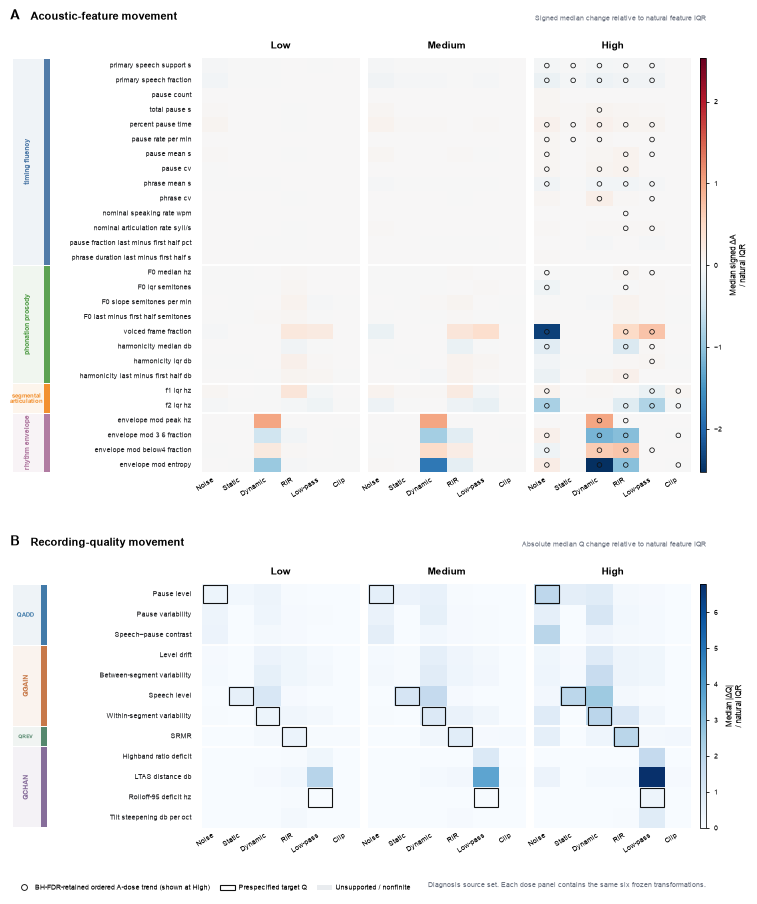

FIGURE S_G3_07 V4: WRITTEN
Layout: adaptive family strip | feature labels | Low | Medium | High
Acoustic features: 28
Acoustic families: 4
Q features: 12
Q families: 4
Transformations: 6
Acoustic BH-FDR retained trends: 69
Acoustic color range: (-2.529681866591326, 2.529681866591326)
Q color range: (0, 6.783491843859407)
Files: {'.pdf': 'C:\\Users\\musikicn\\Desktop\\Nevena_project\\Paper_2_Leakage\\Code\\outputs\\goal3\\FINAL_FIGURES_REVIEW\\FigureS_G3_07_feature_and_offtarget_V4_REVIEW.pdf', '.svg': 'C:\\Users\\musikicn\\Desktop\\Nevena_project\\Paper_2_Leakage\\Code\\outputs\\goal3\\FINAL_FIGURES_REVIEW\\FigureS_G3_07_feature_and_offtarget_V4_REVIEW.svg', '.png': 'C:\\Users\\musikicn\\Desktop\\Nevena_project\\Paper_2_Leakage\\Code\\outputs\\goal3\\FINAL_FIGURES_REVIEW\\FigureS_G3_07_feature_and_offtarget_V4_REVIEW.png'}


In [19]:
# =====================================================================
# FIGURE S_G3_07 V4
# FULL FEATURE-LEVEL PERTURBATION LOCALIZATION
#
# FINAL LAYOUT REFINEMENT:
#
#   FAMILY STRIP | FEATURE NAMES | LOW | MEDIUM | HIGH | COLORBAR
#
# Same scientific content and heatmap design as V3.
#
# The only structural refinement is the family strip:
#
#   - tall family blocks -> vertical label
#   - short family blocks -> compact horizontal / multiline label
#   - every label is clipped to its own block
#
# This prevents overlap between neighboring acoustic/Q family names.
# =====================================================================


# =====================================================================
# FROZEN RETAINED ACOUSTIC FEATURES
# =====================================================================

retained_a = (
    a_registry.loc[
        a_registry["final_role"]
        .astype(str)
        .str.lower()
        .isin(
            [
                "primary",
                "extended",
            ]
        )
    ]
    .drop_duplicates("feature")
    .copy()
)


retained_features = (
    retained_a["feature"]
    .astype(str)
    .tolist()
)


missing_a = [
    feature
    for feature in retained_features
    if feature not in a_values.columns
]


if missing_a:
    raise RuntimeError(
        "Frozen A values are missing retained "
        f"acoustic features: {missing_a[:8]}"
    )


# =====================================================================
# NATURAL IQR FOR EACH RETAINED A FEATURE
# =====================================================================

a_iqr = {}


for feature in retained_features:

    x = pd.to_numeric(
        a_values[feature],
        errors="coerce",
    )

    x = x[
        np.isfinite(x)
    ]

    if len(x):

        iqr = float(
            np.quantile(
                x,
                0.75,
            )
            -
            np.quantile(
                x,
                0.25,
            )
        )

    else:

        iqr = np.nan


    a_iqr[feature] = iqr


# =====================================================================
# DIAGNOSIS-SOURCE ACOUSTIC MOVEMENT
# =====================================================================

afd = (
    feature_delta.loc[
        feature_delta["task"].eq("diagnosis")
        &
        feature_delta["measurement_type"].eq("A")
        &
        feature_delta["feature"]
        .astype(str)
        .isin(retained_features)
    ]
    .copy()
)


afd["natural_iqr"] = (
    afd["feature"]
    .astype(str)
    .map(a_iqr)
)


afd["delta_scaled"] = (
    pd.to_numeric(
        afd["delta"],
        errors="coerce",
    )
    /
    pd.to_numeric(
        afd["natural_iqr"],
        errors="coerce",
    )
)


afd.loc[
    ~(afd["natural_iqr"] > 0),
    "delta_scaled",
] = np.nan


# =====================================================================
# ACOUSTIC FEATURE FAMILY / ORDER
# =====================================================================

a_meta = (
    retained_a
    .set_index("feature")["acoustic_family"]
    .astype(str)
    .to_dict()
)


a_families_s7 = list(
    dict.fromkeys(
        retained_a["acoustic_family"]
        .astype(str)
    )
)


a_order_s7 = []


for family in a_families_s7:

    members = (
        retained_a.loc[
            retained_a["acoustic_family"]
            .astype(str)
            .eq(family),
            "feature",
        ]
        .astype(str)
        .tolist()
    )

    a_order_s7.extend(
        members
    )


# =====================================================================
# LOCAL ACOUSTIC-FAMILY PALETTE
# =====================================================================

s7_family_colors = [
    "#4E79A7",
    "#59A14F",
    "#F28E2B",
    "#B07AA1",
    "#76B7B2",
    "#9C755F",
    "#79706E",
    "#EDC948",
]


S7_A_FAMILY_PALETTE = {
    family: s7_family_colors[
        i % len(s7_family_colors)
    ]
    for i, family
    in enumerate(a_families_s7)
}


# =====================================================================
# CLEAN ACOUSTIC FEATURE LABELS
# =====================================================================

def s7_a_label(feature):

    text = (
        pretty_a(feature)
        .replace("\n", " ")
        .strip()
    )


    replacements = {
        "bamboo ": "",
        "Bamboo ": "",
        " 300ms": "",
        " 300 ms": "",
        " syll per sec": " syll/s",
        " syllables per second": " syll/s",
        " sec": " s",
    }


    for old, new in replacements.items():

        text = text.replace(
            old,
            new,
        )


    text = " ".join(
        text.split()
    )


    return text


# =====================================================================
# DOSE DEFINITIONS
# =====================================================================

DOSES_S7 = [
    (1, "Low"),
    (2, "Medium"),
    (3, "High"),
]


# =====================================================================
# BUILD ACOUSTIC MATRICES
# =====================================================================

a_heat_by_dose = {}


for dose_code, dose_name in DOSES_S7:

    matrix = np.full(
        (
            len(a_order_s7),
            len(TRANSFORM_ORDER),
        ),
        np.nan,
        dtype=float,
    )


    for i, feature in enumerate(a_order_s7):

        for j, transform in enumerate(
            TRANSFORM_ORDER
        ):

            values = afd.loc[
                afd["feature"]
                .astype(str)
                .eq(feature)
                &
                afd["transform"]
                .eq(transform)
                &
                pd.to_numeric(
                    afd["dose_code"],
                    errors="coerce",
                )
                .eq(dose_code),
                "delta_scaled",
            ]


            values = pd.to_numeric(
                values,
                errors="coerce",
            )


            values = values[
                np.isfinite(values)
            ]


            if len(values):

                matrix[
                    i,
                    j,
                ] = float(
                    np.median(values)
                )


    a_heat_by_dose[
        dose_code
    ] = matrix


# =====================================================================
# BH-FDR ACOUSTIC TREND MASK
# =====================================================================

trend = (
    dose_tests.loc[
        dose_tests["test_type"]
        .eq("acoustic_dose_linear")
        &
        dose_tests["task"]
        .eq("diagnosis")
    ]
    .copy()
)


if "q_value" in trend.columns:

    trend["fdr"] = (
        pd.to_numeric(
            trend["q_value"],
            errors="coerce",
        )
        .lt(0.05)
    )

else:

    trend["fdr"] = False


fdr_high = np.zeros(
    (
        len(a_order_s7),
        len(TRANSFORM_ORDER),
    ),
    dtype=bool,
)


for row in trend.loc[
    trend["fdr"]
].itertuples(
    index=False
):

    feature = str(row.feature)
    transform = str(row.transform)


    if feature not in a_order_s7:
        continue

    if transform not in TRANSFORM_ORDER:
        continue


    i = a_order_s7.index(
        feature
    )

    j = TRANSFORM_ORDER.index(
        transform
    )


    fdr_high[
        i,
        j,
    ] = True


# =====================================================================
# Q MOVEMENT
# =====================================================================

oq = (
    offtarget_q.loc[
        offtarget_q["task"]
        .eq("diagnosis")
    ]
    .copy()
)


def infer_q_family(q_feature):

    q = str(q_feature).lower()


    if q.startswith("qadd_"):
        return "QADD"

    if q.startswith("qgain_"):
        return "QGAIN"

    if q.startswith("qrev_"):
        return "QREV"

    if q.startswith("qchan_"):
        return "QCHAN"

    if q.startswith("qdist_"):
        return "QDIST"

    if q.startswith("qtemp_"):
        return "QTEMP"

    return "OTHER"


oq["q_feature_family"] = (
    oq["q_feature"]
    .astype(str)
    .map(infer_q_family)
)


q_family_preference = [
    "QADD",
    "QGAIN",
    "QREV",
    "QCHAN",
    "QDIST",
    "QTEMP",
    "OTHER",
]


q_families_s7 = [
    family
    for family in q_family_preference
    if family in set(
        oq["q_feature_family"]
        .astype(str)
    )
]


q_order_s7 = []


for family in q_families_s7:

    members = (
        oq.loc[
            oq["q_feature_family"]
            .eq(family),
            "q_feature",
        ]
        .astype(str)
        .drop_duplicates()
        .tolist()
    )

    q_order_s7.extend(
        members
    )


q_family_lookup_s7 = {
    feature: infer_q_family(feature)
    for feature in q_order_s7
}


# =====================================================================
# Q MATRICES
# =====================================================================

q_heat_by_dose = {}

q_target_by_dose = {}


dose_text_map = {
    1: "low",
    2: "medium",
    3: "high",
}


for dose_code, dose_name in DOSES_S7:

    matrix = np.full(
        (
            len(q_order_s7),
            len(TRANSFORM_ORDER),
        ),
        np.nan,
        dtype=float,
    )


    target_mask = np.zeros(
        (
            len(q_order_s7),
            len(TRANSFORM_ORDER),
        ),
        dtype=bool,
    )


    for i, q_feature in enumerate(
        q_order_s7
    ):

        for j, transform in enumerate(
            TRANSFORM_ORDER
        ):

            z = oq.loc[
                oq["q_feature"]
                .astype(str)
                .eq(q_feature)
                &
                oq["transform"]
                .eq(transform)
                &
                oq["dose_label"]
                .astype(str)
                .str.lower()
                .eq(
                    dose_text_map[
                        dose_code
                    ]
                )
            ]


            if z.empty:
                continue


            values = pd.to_numeric(
                z[
                    "median_abs_delta_natural_iqr"
                ],
                errors="coerce",
            )


            values = values[
                np.isfinite(values)
            ]


            if len(values):

                matrix[
                    i,
                    j,
                ] = float(
                    np.median(values)
                )


            target_mask[
                i,
                j,
            ] = bool(
                as_bool(
                    z[
                        "is_primary_target"
                    ]
                )
                .any()
            )


    q_heat_by_dose[
        dose_code
    ] = matrix


    q_target_by_dose[
        dose_code
    ] = target_mask


# =====================================================================
# TRANSFORMATION LABELS
# =====================================================================

transform_labels_s7 = [
    TRANSFORM_SHORT[
        transform
    ]
    for transform
    in TRANSFORM_ORDER
]


# =====================================================================
# EXPORT SOURCE MATRICES
# =====================================================================

for dose_code, dose_name in DOSES_S7:

    pd.DataFrame(
        a_heat_by_dose[
            dose_code
        ],
        index=a_order_s7,
        columns=transform_labels_s7,
    ).to_csv(
        SOURCE_TABLES
        / (
            "FigureS_G3_07V4_A_"
            f"{dose_name.lower()}_source.csv"
        )
    )


    pd.DataFrame(
        q_heat_by_dose[
            dose_code
        ],
        index=q_order_s7,
        columns=transform_labels_s7,
    ).to_csv(
        SOURCE_TABLES
        / (
            "FigureS_G3_07V4_B_"
            f"{dose_name.lower()}_source.csv"
        )
    )


# =====================================================================
# COLOR LIMIT — ACOUSTIC
# =====================================================================

a_finite_parts = [
    matrix[
        np.isfinite(matrix)
    ]
    for matrix in a_heat_by_dose.values()
    if np.isfinite(matrix).any()
]


if a_finite_parts:

    a_all_finite = np.concatenate(
        a_finite_parts
    )

else:

    a_all_finite = np.array(
        [],
        dtype=float,
    )


if len(a_all_finite):

    vmax_a = float(
        np.max(
            np.abs(
                a_all_finite
            )
        )
    )

else:

    vmax_a = 1.0


vmax_a = max(
    vmax_a,
    0.25,
)


# =====================================================================
# COLOR LIMIT — Q
# =====================================================================

q_finite_parts = [
    matrix[
        np.isfinite(matrix)
    ]
    for matrix in q_heat_by_dose.values()
    if np.isfinite(matrix).any()
]


if q_finite_parts:

    q_all_finite = np.concatenate(
        q_finite_parts
    )

else:

    q_all_finite = np.array(
        [],
        dtype=float,
    )


if len(q_all_finite):

    vmax_q = float(
        np.max(
            q_all_finite
        )
    )

else:

    vmax_q = 1.0


vmax_q = max(
    vmax_q,
    0.25,
)


print(
    "Acoustic scale:",
    f"±{vmax_a:.3f} natural IQR",
)

print(
    "Q scale:",
    f"0 to {vmax_q:.3f} natural IQR",
)


# =====================================================================
# FAMILY BLOCK GEOMETRY
# =====================================================================

def family_blocks(
    ordered_features,
    family_lookup,
):

    blocks = []


    if not ordered_features:
        return blocks


    start = 0

    current = family_lookup[
        ordered_features[0]
    ]


    for index, feature in enumerate(
        ordered_features
    ):

        family = family_lookup[
            feature
        ]


        if family != current:

            blocks.append({
                "family": current,
                "start": start,
                "end": index - 1,
                "center": (
                    start
                    + index
                    - 1
                )
                / 2,
            })


            start = index
            current = family


    blocks.append({
        "family": current,
        "start": start,
        "end": len(
            ordered_features
        ) - 1,
        "center": (
            start
            + len(
                ordered_features
            )
            - 1
        )
        / 2,
    })


    return blocks


a_blocks = family_blocks(
    a_order_s7,
    a_meta,
)


q_blocks = family_blocks(
    q_order_s7,
    q_family_lookup_s7,
)


# =====================================================================
# DISPLAY-ONLY FAMILY LABELS
#
# Long names in short blocks are intentionally broken into two lines.
# This changes presentation only, never scientific terminology/data.
# =====================================================================

FAMILY_DISPLAY = {

    # Acoustic groups seen in this frozen registry.
    "timing fluency":
        "timing\nfluency",

    "phonation prosody":
        "phonation\nprosody",

    "spectral articulation":
        "spectral\narticulation",

    "rhythm envelope":
        "rhythm\nenvelope",

    # Safe fallbacks for common alternate separators.
    "timing_fluency":
        "timing\nfluency",

    "phonation_prosody":
        "phonation\nprosody",

    "spectral_articulation":
        "spectral\narticulation",

    "rhythm_envelope":
        "rhythm\nenvelope",
}


def family_display_name(
    family,
):

    raw = str(
        family
    )


    key = (
        raw
        .replace("-", " ")
        .replace("_", " ")
        .strip()
        .lower()
    )


    if key in FAMILY_DISPLAY:

        return FAMILY_DISPLAY[
            key
        ]


    # QADD / QGAIN / QREV / QCHAN remain untouched.
    if raw.upper().startswith("Q"):

        return raw


    words = raw.replace(
        "_",
        " ",
    ).split()


    # Generic display fallback.
    if len(words) >= 2:

        midpoint = int(
            math.ceil(
                len(words)
                / 2
            )
        )

        return (
            " ".join(
                words[
                    :midpoint
                ]
            )
            + "\n"
            + " ".join(
                words[
                    midpoint:
                ]
            )
        )


    return raw


# =====================================================================
# ADAPTIVE FAMILY-STRIP RENDERER
# =====================================================================

def draw_family_strip(
    ax,
    blocks,
    n_rows,
    palette,
):

    ax.set_xlim(
        0,
        1,
    )

    ax.set_ylim(
        n_rows - 0.5,
        -0.5,
    )

    ax.axis(
        "off"
    )


    for block in blocks:

        family = str(
            block["family"]
        )


        start = int(
            block["start"]
        )

        end = int(
            block["end"]
        )

        center = float(
            block["center"]
        )


        n_block_rows = (
            end
            - start
            + 1
        )


        color = palette.get(
            family,
            NEUTRAL,
        )


        display_family = (
            family_display_name(
                family
            )
        )


        # ---------------------------------------------------------
        # One block-specific patch.
        #
        # We keep a reference to this patch and use it to clip
        # the text. Therefore text cannot spill into adjacent
        # family blocks.
        # ---------------------------------------------------------

        background_patch = Rectangle(
            (
                0.06,
                start - 0.47,
            ),
            0.88,
            n_block_rows - 0.06,
            facecolor=color,
            edgecolor="none",
            alpha=0.085,
            zorder=1,
        )


        ax.add_patch(
            background_patch
        )


        # ---------------------------------------------------------
        # Grouping bar
        # ---------------------------------------------------------

        ax.add_patch(
            Rectangle(
                (
                    0.78,
                    start - 0.47,
                ),
                0.14,
                n_block_rows - 0.06,
                facecolor=color,
                edgecolor="none",
                alpha=0.98,
                zorder=2,
            )
        )


        # ---------------------------------------------------------
        # ADAPTIVE TEXT
        #
        # ≥4 rows:
        #     use vertical label as before.
        #
        # 2–3 rows:
        #     horizontal multiline label.
        #
        # 1 row:
        #     horizontal compact label.
        #
        # This is the key anti-overlap correction.
        # ---------------------------------------------------------

        if n_block_rows >= 4:

            txt = ax.text(
                0.38,
                center,
                str(
                    display_family
                ).replace(
                    "\n",
                    " ",
                ),
                rotation=90,
                ha="center",
                va="center",
                fontsize=4.9,
                fontweight="bold",
                color=color,
                linespacing=0.95,
                zorder=3,
            )


        elif n_block_rows >= 2:

            txt = ax.text(
                0.38,
                center,
                display_family,
                rotation=0,
                ha="center",
                va="center",
                fontsize=4.15,
                fontweight="bold",
                color=color,
                linespacing=0.88,
                zorder=3,
            )


        else:

            txt = ax.text(
                0.38,
                center,
                display_family,
                rotation=0,
                ha="center",
                va="center",
                fontsize=3.85,
                fontweight="bold",
                color=color,
                linespacing=0.85,
                zorder=3,
            )


        # Clip each label to its own family block.
        txt.set_clip_path(
            background_patch
        )


# =====================================================================
# FEATURE-LABEL AXIS HELPER
# =====================================================================

def draw_feature_labels(
    ax,
    labels,
    *,
    fontsize=4.8,
):

    n_rows = len(
        labels
    )


    ax.set_xlim(
        0,
        1,
    )

    ax.set_ylim(
        n_rows - 0.5,
        -0.5,
    )

    ax.axis(
        "off"
    )


    for i, label in enumerate(
        labels
    ):

        ax.text(
            0.985,
            i,
            str(label),
            ha="right",
            va="center",
            fontsize=fontsize,
            color="#202124",
            clip_on=True,
        )


# =====================================================================
# FIGURE
# =====================================================================

fig = plt.figure(
    figsize=(
        190 * MM_TO_IN,
        230 * MM_TO_IN,
    ),
    facecolor="white",
)


outer = fig.add_gridspec(
    nrows=2,
    ncols=1,

    height_ratios=[
        1.70,
        1.00,
    ],

    left=0.035,
    right=0.965,
    top=0.945,
    bottom=0.095,

    hspace=0.34,
)


# =====================================================================
# PANEL A GRID
#
# Slightly wider family gutter than V3.
# =====================================================================

gs_a = (
    outer[
        0,
        0,
    ]
    .subgridspec(
        nrows=1,
        ncols=6,

        width_ratios=[
            0.27,   # acoustic family gutter — widened
            0.84,   # acoustic feature labels
            1.00,   # Low
            1.00,   # Medium
            1.00,   # High
            0.040,  # colorbar
        ],

        wspace=0.075,
    )
)


ax_a_family = fig.add_subplot(
    gs_a[
        0,
        0,
    ]
)


ax_a_labels = fig.add_subplot(
    gs_a[
        0,
        1,
    ]
)


axes_a = [
    fig.add_subplot(
        gs_a[
            0,
            i,
        ]
    )
    for i in [
        2,
        3,
        4,
    ]
]


cax_a = fig.add_subplot(
    gs_a[
        0,
        5,
    ]
)


# =====================================================================
# PANEL B GRID
# =====================================================================

gs_b = (
    outer[
        1,
        0,
    ]
    .subgridspec(
        nrows=1,
        ncols=6,

        width_ratios=[
            0.25,   # Q-family gutter
            0.86,   # Q feature labels
            1.00,   # Low
            1.00,   # Medium
            1.00,   # High
            0.040,  # colorbar
        ],

        wspace=0.075,
    )
)


ax_b_family = fig.add_subplot(
    gs_b[
        0,
        0,
    ]
)


ax_b_labels = fig.add_subplot(
    gs_b[
        0,
        1,
    ]
)


axes_b = [
    fig.add_subplot(
        gs_b[
            0,
            i,
        ]
    )
    for i in [
        2,
        3,
        4,
    ]
]


cax_b = fig.add_subplot(
    gs_b[
        0,
        5,
    ]
)


# =====================================================================
# DRAW DEDICATED FAMILY / FEATURE COLUMNS
# =====================================================================

draw_family_strip(
    ax_a_family,
    a_blocks,
    len(
        a_order_s7
    ),
    S7_A_FAMILY_PALETTE,
)


draw_feature_labels(
    ax_a_labels,
    [
        s7_a_label(
            feature
        )
        for feature
        in a_order_s7
    ],
    fontsize=4.75,
)


draw_family_strip(
    ax_b_family,
    q_blocks,
    len(
        q_order_s7
    ),
    FAMILY_PALETTE,
)


draw_feature_labels(
    ax_b_labels,
    [
        pretty_q(
            q_feature
        )
        for q_feature
        in q_order_s7
    ],
    fontsize=4.85,
)


# =====================================================================
# COLOR MAPS
# =====================================================================

cmap_a = (
    mpl.colormaps[
        "RdBu_r"
    ]
    .copy()
)


cmap_a.set_bad(
    "#E9ECEF"
)


cmap_q = (
    mpl.colormaps[
        "Blues"
    ]
    .copy()
)


cmap_q.set_bad(
    "#E9ECEF"
)


# =====================================================================
# PANEL A — ACOUSTIC MOVEMENT
# =====================================================================

images_a = []


for panel_index, (
    dose_code,
    dose_name,
) in enumerate(
    DOSES_S7
):

    ax = axes_a[
        panel_index
    ]


    matrix = a_heat_by_dose[
        dose_code
    ]


    im = ax.imshow(
        matrix,
        aspect="auto",
        interpolation="none",
        cmap=cmap_a,
        vmin=-vmax_a,
        vmax=vmax_a,
    )


    images_a.append(
        im
    )


    # -------------------------------------------------------------
    # BH-FDR marker only at HIGH dose
    # -------------------------------------------------------------

    if dose_code == 3:

        yy, xx = np.where(
            fdr_high
            &
            np.isfinite(
                matrix
            )
        )


        ax.scatter(
            xx,
            yy,
            s=11,
            marker="o",
            facecolors="none",
            edgecolors="#111111",
            linewidths=0.55,
            zorder=4,
        )


    # -------------------------------------------------------------
    # TRANSFORMATION AXIS
    # -------------------------------------------------------------

    ax.set_xticks(
        np.arange(
            len(
                TRANSFORM_ORDER
            )
        )
    )


    ax.set_xticklabels(
        transform_labels_s7,
        rotation=32,
        ha="right",
        fontsize=5.25,
    )


    ax.tick_params(
        axis="x",
        length=0,
        pad=3,
    )


    ax.set_yticks(
        []
    )


    ax.set_title(
        dose_name,
        fontsize=7.2,
        fontweight="bold",
        pad=7,
    )


    # -------------------------------------------------------------
    # FAMILY SEPARATORS
    # -------------------------------------------------------------

    for block in a_blocks[
        :-1
    ]:

        ax.axhline(
            block["end"]
            + 0.5,
            color="white",
            linewidth=1.3,
            zorder=3,
        )


    for spine in ax.spines.values():

        spine.set_visible(
            False
        )


# =====================================================================
# PANEL A COLORBAR
# =====================================================================

cb_a = fig.colorbar(
    images_a[
        0
    ],
    cax=cax_a,
)


cb_a.set_label(
    "Median signed ΔA\n/ natural IQR",
    fontsize=5.6,
    labelpad=5,
)


cb_a.ax.tick_params(
    labelsize=5.0,
    length=2.3,
)


cb_a.outline.set_linewidth(
    0.55
)


# =====================================================================
# PANEL B — Q MOVEMENT
# =====================================================================

images_b = []


for panel_index, (
    dose_code,
    dose_name,
) in enumerate(
    DOSES_S7
):

    ax = axes_b[
        panel_index
    ]


    matrix = q_heat_by_dose[
        dose_code
    ]


    target_mask = q_target_by_dose[
        dose_code
    ]


    im = ax.imshow(
        matrix,
        aspect="auto",
        interpolation="none",
        cmap=cmap_q,
        vmin=0,
        vmax=vmax_q,
    )


    images_b.append(
        im
    )


    # -------------------------------------------------------------
    # PRESPECIFIED TARGET-Q OUTLINE
    # -------------------------------------------------------------

    yy, xx = np.where(
        target_mask
        &
        np.isfinite(
            matrix
        )
    )


    for i, j in zip(
        yy,
        xx,
    ):

        ax.add_patch(
            Rectangle(
                (
                    j - 0.45,
                    i - 0.45,
                ),
                0.90,
                0.90,
                fill=False,
                edgecolor="#111111",
                linewidth=0.80,
                zorder=4,
            )
        )


    # -------------------------------------------------------------
    # TRANSFORMATION AXIS
    # -------------------------------------------------------------

    ax.set_xticks(
        np.arange(
            len(
                TRANSFORM_ORDER
            )
        )
    )


    ax.set_xticklabels(
        transform_labels_s7,
        rotation=32,
        ha="right",
        fontsize=5.25,
    )


    ax.tick_params(
        axis="x",
        length=0,
        pad=3,
    )


    ax.set_yticks(
        []
    )


    ax.set_title(
        dose_name,
        fontsize=7.2,
        fontweight="bold",
        pad=7,
    )


    for block in q_blocks[
        :-1
    ]:

        ax.axhline(
            block["end"]
            + 0.5,
            color="white",
            linewidth=1.3,
            zorder=3,
        )


    for spine in ax.spines.values():

        spine.set_visible(
            False
        )


# =====================================================================
# PANEL B COLORBAR
# =====================================================================

cb_b = fig.colorbar(
    images_b[
        0
    ],
    cax=cax_b,
)


cb_b.set_label(
    "Median |ΔQ|\n/ natural IQR",
    fontsize=5.6,
    labelpad=5,
)


cb_b.ax.tick_params(
    labelsize=5.0,
    length=2.3,
)


cb_b.outline.set_linewidth(
    0.55
)


# =====================================================================
# PANEL HEADINGS
# =====================================================================

box_a = (
    ax_a_family
    .get_position()
)


fig.text(
    box_a.x0,
    box_a.y1
    + 0.040,
    "A",
    fontsize=9.1,
    fontweight="bold",
    ha="left",
    va="bottom",
)


fig.text(
    box_a.x0
    + 0.027,
    box_a.y1
    + 0.040,
    "Acoustic-feature movement",
    fontsize=7.6,
    fontweight="bold",
    ha="left",
    va="bottom",
)


fig.text(
    0.965,
    box_a.y1
    + 0.040,
    (
        "Signed median change relative "
        "to natural feature IQR"
    ),
    fontsize=5.15,
    color=NEUTRAL,
    ha="right",
    va="bottom",
)


box_b = (
    ax_b_family
    .get_position()
)


fig.text(
    box_b.x0,
    box_b.y1
    + 0.040,
    "B",
    fontsize=9.1,
    fontweight="bold",
    ha="left",
    va="bottom",
)


fig.text(
    box_b.x0
    + 0.027,
    box_b.y1
    + 0.040,
    "Recording-quality movement",
    fontsize=7.6,
    fontweight="bold",
    ha="left",
    va="bottom",
)


fig.text(
    0.965,
    box_b.y1
    + 0.040,
    (
        "Absolute median Q change relative "
        "to natural feature IQR"
    ),
    fontsize=5.15,
    color=NEUTRAL,
    ha="right",
    va="bottom",
)


# =====================================================================
# SYMBOL LEGEND
# =====================================================================

legend_handles = [

    Line2D(
        [0],
        [0],
        marker="o",
        markersize=4.2,
        markerfacecolor="none",
        markeredgecolor="#111111",
        markeredgewidth=0.65,
        linestyle="none",
        label=(
            "BH-FDR-retained ordered "
            "A-dose trend (shown at High)"
        ),
    ),

    Rectangle(
        (
            0,
            0,
        ),
        1,
        1,
        facecolor="none",
        edgecolor="#111111",
        linewidth=0.80,
        label="Prespecified target Q",
    ),

    Rectangle(
        (
            0,
            0,
        ),
        1,
        1,
        facecolor="#E9ECEF",
        edgecolor="none",
        label="Unsupported / nonfinite",
    ),
]


fig.legend(
    handles=legend_handles,
    loc="lower left",
    bbox_to_anchor=(
        0.035,
        0.018,
    ),
    ncol=3,
    frameon=False,
    fontsize=5.15,
    columnspacing=1.5,
    handletextpad=0.55,
)


# =====================================================================
# FOOTNOTE
# =====================================================================

fig.text(
    0.965,
    0.028,
    (
        "Diagnosis source set. "
        "Each dose panel contains the same six "
        "frozen transformations."
    ),
    fontsize=5.0,
    color=NEUTRAL,
    ha="right",
    va="bottom",
)


# =====================================================================
# EXPORT
# =====================================================================

figureS7_v4_files = save_figure(
    fig,
    "FigureS_G3_07_feature_and_offtarget_V4_REVIEW",
    [
        PATHS[
            "feature_delta"
        ],
        PATHS[
            "offtarget_q"
        ],
        PATHS[
            "dose_tests"
        ],
        PATHS[
            "a_registry"
        ],
        PATHS[
            "a_values"
        ],
    ],
)


plt.show()


# =====================================================================
# AUDIT
# =====================================================================

print(
    "=" * 78
)

print(
    "FIGURE S_G3_07 V4: WRITTEN"
)

print(
    "=" * 78
)

print(
    "Layout:",
    "adaptive family strip | feature labels | Low | Medium | High",
)

print(
    "Acoustic features:",
    len(
        a_order_s7
    ),
)

print(
    "Acoustic families:",
    len(
        a_blocks
    ),
)

print(
    "Q features:",
    len(
        q_order_s7
    ),
)

print(
    "Q families:",
    len(
        q_blocks
    ),
)

print(
    "Transformations:",
    len(
        TRANSFORM_ORDER
    ),
)

print(
    "Acoustic BH-FDR retained trends:",
    int(
        fdr_high.sum()
    ),
)

print(
    "Acoustic color range:",
    (
        -vmax_a,
        vmax_a,
    ),
)

print(
    "Q color range:",
    (
        0,
        vmax_q,
    ),
)

print(
    "Files:",
    figureS7_v4_files,
)

Acoustic scale: ±2.530 natural IQR
Q scale: 0 to 6.783 natural IQR


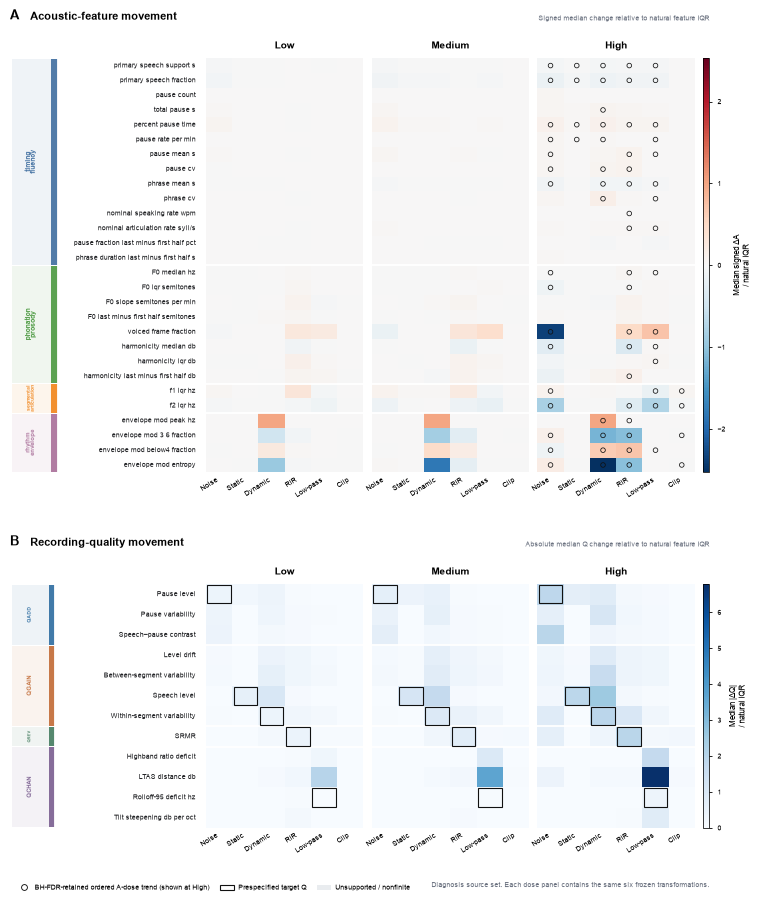

FIGURE S_G3_07 V5: WRITTEN
Family orientation: ALL VERTICAL
Layout: family strip | feature labels | Low | Medium | High
Acoustic features: 28
Acoustic families: 4
Q features: 12
Q families: 4
Transformations: 6
Acoustic BH-FDR retained trends: 69
Acoustic color range: (-2.529681866591326, 2.529681866591326)
Q color range: (0, 6.783491843859407)
Files: {'.pdf': 'C:\\Users\\musikicn\\Desktop\\Nevena_project\\Paper_2_Leakage\\Code\\outputs\\goal3\\FINAL_FIGURES_REVIEW\\FigureS_G3_07_feature_and_offtarget_V5_REVIEW.pdf', '.svg': 'C:\\Users\\musikicn\\Desktop\\Nevena_project\\Paper_2_Leakage\\Code\\outputs\\goal3\\FINAL_FIGURES_REVIEW\\FigureS_G3_07_feature_and_offtarget_V5_REVIEW.svg', '.png': 'C:\\Users\\musikicn\\Desktop\\Nevena_project\\Paper_2_Leakage\\Code\\outputs\\goal3\\FINAL_FIGURES_REVIEW\\FigureS_G3_07_feature_and_offtarget_V5_REVIEW.png'}


In [20]:
# =====================================================================
# FIGURE S_G3_07 V5
# FULL FEATURE-LEVEL PERTURBATION LOCALIZATION
#
# FINAL REFINED LAYOUT
#
#   FAMILY STRIP | FEATURE NAMES | LOW | MEDIUM | HIGH | COLORBAR
#
# IMPORTANT:
#   - ALL family names remain vertical.
#   - Long family names may use multiple text lines, but the entire
#     label remains rotated 90 degrees.
#   - Family labels and individual feature labels live in completely
#     separate axes.
#   - Every family label is clipped to its own family block.
#
# No scientific result or source value is changed.
# =====================================================================


# =====================================================================
# FROZEN RETAINED ACOUSTIC FEATURES
# =====================================================================

retained_a = (
    a_registry.loc[
        a_registry["final_role"]
        .astype(str)
        .str.lower()
        .isin(
            [
                "primary",
                "extended",
            ]
        )
    ]
    .drop_duplicates("feature")
    .copy()
)


retained_features = (
    retained_a["feature"]
    .astype(str)
    .tolist()
)


missing_a = [
    feature
    for feature in retained_features
    if feature not in a_values.columns
]


if missing_a:
    raise RuntimeError(
        "Frozen A values are missing retained "
        f"acoustic features: {missing_a[:8]}"
    )


# =====================================================================
# NATURAL IQR FOR EACH RETAINED A FEATURE
# =====================================================================

a_iqr = {}


for feature in retained_features:

    x = pd.to_numeric(
        a_values[feature],
        errors="coerce",
    )

    x = x[
        np.isfinite(x)
    ]

    if len(x):

        iqr = float(
            np.quantile(
                x,
                0.75,
            )
            -
            np.quantile(
                x,
                0.25,
            )
        )

    else:

        iqr = np.nan


    a_iqr[feature] = iqr


# =====================================================================
# DIAGNOSIS-SOURCE ACOUSTIC MOVEMENT
# =====================================================================

afd = (
    feature_delta.loc[
        feature_delta["task"].eq("diagnosis")
        &
        feature_delta["measurement_type"].eq("A")
        &
        feature_delta["feature"]
        .astype(str)
        .isin(retained_features)
    ]
    .copy()
)


afd["natural_iqr"] = (
    afd["feature"]
    .astype(str)
    .map(a_iqr)
)


afd["delta_scaled"] = (
    pd.to_numeric(
        afd["delta"],
        errors="coerce",
    )
    /
    pd.to_numeric(
        afd["natural_iqr"],
        errors="coerce",
    )
)


afd.loc[
    ~(afd["natural_iqr"] > 0),
    "delta_scaled",
] = np.nan


# =====================================================================
# ACOUSTIC FEATURE FAMILY / ORDER
# =====================================================================

a_meta = (
    retained_a
    .set_index("feature")["acoustic_family"]
    .astype(str)
    .to_dict()
)


a_families_s7 = list(
    dict.fromkeys(
        retained_a["acoustic_family"]
        .astype(str)
    )
)


a_order_s7 = []


for family in a_families_s7:

    members = (
        retained_a.loc[
            retained_a["acoustic_family"]
            .astype(str)
            .eq(family),
            "feature",
        ]
        .astype(str)
        .tolist()
    )

    a_order_s7.extend(
        members
    )


# =====================================================================
# LOCAL ACOUSTIC-FAMILY PALETTE
# =====================================================================

s7_family_colors = [
    "#4E79A7",
    "#59A14F",
    "#F28E2B",
    "#B07AA1",
    "#76B7B2",
    "#9C755F",
    "#79706E",
    "#EDC948",
]


S7_A_FAMILY_PALETTE = {
    family: s7_family_colors[
        i % len(s7_family_colors)
    ]
    for i, family
    in enumerate(a_families_s7)
}


# =====================================================================
# CLEAN ACOUSTIC FEATURE LABELS
# =====================================================================

def s7_a_label(feature):

    text = (
        pretty_a(feature)
        .replace("\n", " ")
        .strip()
    )


    replacements = {
        "bamboo ": "",
        "Bamboo ": "",
        " 300ms": "",
        " 300 ms": "",
        " syll per sec": " syll/s",
        " syllables per second": " syll/s",
        " sec": " s",
    }


    for old, new in replacements.items():

        text = text.replace(
            old,
            new,
        )


    return " ".join(
        text.split()
    )


# =====================================================================
# DOSE DEFINITIONS
# =====================================================================

DOSES_S7 = [
    (1, "Low"),
    (2, "Medium"),
    (3, "High"),
]


# =====================================================================
# BUILD ACOUSTIC MATRICES
#
# rows    = retained acoustic features
# columns = six controlled transformations
# =====================================================================

a_heat_by_dose = {}


for dose_code, dose_name in DOSES_S7:

    matrix = np.full(
        (
            len(a_order_s7),
            len(TRANSFORM_ORDER),
        ),
        np.nan,
        dtype=float,
    )


    for i, feature in enumerate(a_order_s7):

        for j, transform in enumerate(
            TRANSFORM_ORDER
        ):

            values = afd.loc[
                afd["feature"]
                .astype(str)
                .eq(feature)
                &
                afd["transform"]
                .eq(transform)
                &
                pd.to_numeric(
                    afd["dose_code"],
                    errors="coerce",
                )
                .eq(dose_code),
                "delta_scaled",
            ]


            values = pd.to_numeric(
                values,
                errors="coerce",
            )


            values = values[
                np.isfinite(values)
            ]


            if len(values):

                matrix[
                    i,
                    j,
                ] = float(
                    np.median(values)
                )


    a_heat_by_dose[
        dose_code
    ] = matrix


# =====================================================================
# BH-FDR ACOUSTIC TREND MASK
#
# Formal test is the ordered dose trend.
# Marker is shown only in the HIGH-dose panel.
# =====================================================================

trend = (
    dose_tests.loc[
        dose_tests["test_type"]
        .eq("acoustic_dose_linear")
        &
        dose_tests["task"]
        .eq("diagnosis")
    ]
    .copy()
)


if "q_value" in trend.columns:

    trend["fdr"] = (
        pd.to_numeric(
            trend["q_value"],
            errors="coerce",
        )
        .lt(0.05)
    )

else:

    trend["fdr"] = False


fdr_high = np.zeros(
    (
        len(a_order_s7),
        len(TRANSFORM_ORDER),
    ),
    dtype=bool,
)


for row in trend.loc[
    trend["fdr"]
].itertuples(
    index=False
):

    feature = str(
        row.feature
    )

    transform = str(
        row.transform
    )


    if feature not in a_order_s7:
        continue


    if transform not in TRANSFORM_ORDER:
        continue


    i = a_order_s7.index(
        feature
    )

    j = TRANSFORM_ORDER.index(
        transform
    )


    fdr_high[
        i,
        j,
    ] = True


# =====================================================================
# Q MOVEMENT
# =====================================================================

oq = (
    offtarget_q.loc[
        offtarget_q["task"]
        .eq("diagnosis")
    ]
    .copy()
)


# =====================================================================
# Q FEATURE FAMILY
# =====================================================================

def infer_q_family(q_feature):

    q = str(
        q_feature
    ).lower()


    if q.startswith("qadd_"):
        return "QADD"

    if q.startswith("qgain_"):
        return "QGAIN"

    if q.startswith("qrev_"):
        return "QREV"

    if q.startswith("qchan_"):
        return "QCHAN"

    if q.startswith("qdist_"):
        return "QDIST"

    if q.startswith("qtemp_"):
        return "QTEMP"

    return "OTHER"


oq["q_feature_family"] = (
    oq["q_feature"]
    .astype(str)
    .map(infer_q_family)
)


q_family_preference = [
    "QADD",
    "QGAIN",
    "QREV",
    "QCHAN",
    "QDIST",
    "QTEMP",
    "OTHER",
]


q_families_s7 = [
    family
    for family in q_family_preference
    if family in set(
        oq["q_feature_family"]
        .astype(str)
    )
]


q_order_s7 = []


for family in q_families_s7:

    members = (
        oq.loc[
            oq["q_feature_family"]
            .eq(family),
            "q_feature",
        ]
        .astype(str)
        .drop_duplicates()
        .tolist()
    )

    q_order_s7.extend(
        members
    )


q_family_lookup_s7 = {
    feature: infer_q_family(
        feature
    )
    for feature in q_order_s7
}


# =====================================================================
# Q MATRICES
# =====================================================================

q_heat_by_dose = {}

q_target_by_dose = {}


dose_text_map = {
    1: "low",
    2: "medium",
    3: "high",
}


for dose_code, dose_name in DOSES_S7:

    matrix = np.full(
        (
            len(q_order_s7),
            len(TRANSFORM_ORDER),
        ),
        np.nan,
        dtype=float,
    )


    target_mask = np.zeros(
        (
            len(q_order_s7),
            len(TRANSFORM_ORDER),
        ),
        dtype=bool,
    )


    for i, q_feature in enumerate(
        q_order_s7
    ):

        for j, transform in enumerate(
            TRANSFORM_ORDER
        ):

            z = oq.loc[
                oq["q_feature"]
                .astype(str)
                .eq(q_feature)
                &
                oq["transform"]
                .eq(transform)
                &
                oq["dose_label"]
                .astype(str)
                .str.lower()
                .eq(
                    dose_text_map[
                        dose_code
                    ]
                )
            ]


            if z.empty:
                continue


            values = pd.to_numeric(
                z[
                    "median_abs_delta_natural_iqr"
                ],
                errors="coerce",
            )


            values = values[
                np.isfinite(values)
            ]


            if len(values):

                matrix[
                    i,
                    j,
                ] = float(
                    np.median(values)
                )


            target_mask[
                i,
                j,
            ] = bool(
                as_bool(
                    z[
                        "is_primary_target"
                    ]
                )
                .any()
            )


    q_heat_by_dose[
        dose_code
    ] = matrix


    q_target_by_dose[
        dose_code
    ] = target_mask


# =====================================================================
# TRANSFORMATION LABELS
# =====================================================================

transform_labels_s7 = [
    TRANSFORM_SHORT[
        transform
    ]
    for transform in TRANSFORM_ORDER
]


# =====================================================================
# EXPORT SOURCE MATRICES
# =====================================================================

for dose_code, dose_name in DOSES_S7:

    pd.DataFrame(
        a_heat_by_dose[
            dose_code
        ],
        index=a_order_s7,
        columns=transform_labels_s7,
    ).to_csv(
        SOURCE_TABLES
        / (
            "FigureS_G3_07V5_A_"
            f"{dose_name.lower()}_source.csv"
        )
    )


    pd.DataFrame(
        q_heat_by_dose[
            dose_code
        ],
        index=q_order_s7,
        columns=transform_labels_s7,
    ).to_csv(
        SOURCE_TABLES
        / (
            "FigureS_G3_07V5_B_"
            f"{dose_name.lower()}_source.csv"
        )
    )


# =====================================================================
# COLOR LIMIT — ACOUSTIC
# =====================================================================

a_finite_parts = [
    matrix[
        np.isfinite(matrix)
    ]
    for matrix in a_heat_by_dose.values()
    if np.isfinite(matrix).any()
]


if a_finite_parts:

    a_all_finite = np.concatenate(
        a_finite_parts
    )

else:

    a_all_finite = np.array(
        [],
        dtype=float,
    )


if len(a_all_finite):

    vmax_a = float(
        np.max(
            np.abs(
                a_all_finite
            )
        )
    )

else:

    vmax_a = 1.0


vmax_a = max(
    vmax_a,
    0.25,
)


# =====================================================================
# COLOR LIMIT — Q
# =====================================================================

q_finite_parts = [
    matrix[
        np.isfinite(matrix)
    ]
    for matrix in q_heat_by_dose.values()
    if np.isfinite(matrix).any()
]


if q_finite_parts:

    q_all_finite = np.concatenate(
        q_finite_parts
    )

else:

    q_all_finite = np.array(
        [],
        dtype=float,
    )


if len(q_all_finite):

    vmax_q = float(
        np.max(
            q_all_finite
        )
    )

else:

    vmax_q = 1.0


vmax_q = max(
    vmax_q,
    0.25,
)


print(
    "Acoustic scale:",
    f"±{vmax_a:.3f} natural IQR",
)

print(
    "Q scale:",
    f"0 to {vmax_q:.3f} natural IQR",
)


# =====================================================================
# FAMILY BLOCK GEOMETRY
# =====================================================================

def family_blocks(
    ordered_features,
    family_lookup,
):

    blocks = []


    if not ordered_features:
        return blocks


    start = 0

    current = family_lookup[
        ordered_features[
            0
        ]
    ]


    for index, feature in enumerate(
        ordered_features
    ):

        family = family_lookup[
            feature
        ]


        if family != current:

            blocks.append({
                "family": current,
                "start": start,
                "end": index - 1,
                "center": (
                    start
                    + index
                    - 1
                )
                / 2,
            })


            start = index

            current = family


    blocks.append({
        "family": current,
        "start": start,
        "end": len(
            ordered_features
        ) - 1,
        "center": (
            start
            + len(
                ordered_features
            )
            - 1
        )
        / 2,
    })


    return blocks


a_blocks = family_blocks(
    a_order_s7,
    a_meta,
)


q_blocks = family_blocks(
    q_order_s7,
    q_family_lookup_s7,
)


# =====================================================================
# DISPLAY-ONLY FAMILY LABELS
#
# IMPORTANT:
# Labels may be broken across lines, but ALL are still rotated 90°.
#
# Example:
#
#   "spectral articulation"
#
# becomes
#
#   "spectral\narticulation"
#
# and the entire 2-line object is rotated vertically.
# =====================================================================

FAMILY_DISPLAY = {

    "timing fluency":
        "timing\nfluency",

    "phonation prosody":
        "phonation\nprosody",

    "spectral articulation":
        "spectral\narticulation",

    "rhythm envelope":
        "rhythm\nenvelope",

    "timing_fluency":
        "timing\nfluency",

    "phonation_prosody":
        "phonation\nprosody",

    "spectral_articulation":
        "spectral\narticulation",

    "rhythm_envelope":
        "rhythm\nenvelope",
}


def family_display_name(
    family,
):

    raw = str(
        family
    )


    # Q family labels remain intact.
    if raw.upper().startswith(
        "Q"
    ):

        return raw


    key = (
        raw
        .replace("-", " ")
        .replace("_", " ")
        .strip()
        .lower()
    )


    if key in FAMILY_DISPLAY:

        return FAMILY_DISPLAY[
            key
        ]


    words = (
        raw
        .replace("_", " ")
        .replace("-", " ")
        .split()
    )


    if len(words) >= 2:

        midpoint = int(
            math.ceil(
                len(words)
                / 2
            )
        )


        return (
            " ".join(
                words[
                    :midpoint
                ]
            )
            +
            "\n"
            +
            " ".join(
                words[
                    midpoint:
                ]
            )
        )


    return raw


# =====================================================================
# FAMILY STRIP RENDERER
#
# EVERY LABEL IS VERTICAL.
#
# Shorter blocks use:
#   - smaller font
#   - shorter line lengths
#   - block clipping
#
# Orientation never changes.
# =====================================================================

def draw_family_strip(
    ax,
    blocks,
    n_rows,
    palette,
):

    ax.set_xlim(
        0,
        1,
    )


    ax.set_ylim(
        n_rows - 0.5,
        -0.5,
    )


    ax.axis(
        "off"
    )


    for block in blocks:

        family = str(
            block["family"]
        )


        start = int(
            block["start"]
        )


        end = int(
            block["end"]
        )


        center = float(
            block["center"]
        )


        n_block_rows = (
            end
            - start
            + 1
        )


        color = palette.get(
            family,
            NEUTRAL,
        )


        display_family = (
            family_display_name(
                family
            )
        )


        # ---------------------------------------------------------
        # BLOCK BACKGROUND
        # ---------------------------------------------------------

        background_patch = Rectangle(
            (
                0.04,
                start - 0.47,
            ),
            0.91,
            n_block_rows - 0.06,
            facecolor=color,
            edgecolor="none",
            alpha=0.085,
            zorder=1,
        )


        ax.add_patch(
            background_patch
        )


        # ---------------------------------------------------------
        # STRONG FAMILY BAR
        # ---------------------------------------------------------

        ax.add_patch(
            Rectangle(
                (
                    0.82,
                    start - 0.47,
                ),
                0.12,
                n_block_rows - 0.06,
                facecolor=color,
                edgecolor="none",
                alpha=0.98,
                zorder=2,
            )
        )


        # ---------------------------------------------------------
        # ADAPTIVE FONT SIZE
        #
        # Always vertical.
        # ---------------------------------------------------------

        if n_block_rows >= 7:

            fontsize = 5.0

        elif n_block_rows >= 5:

            fontsize = 4.6

        elif n_block_rows == 4:

            fontsize = 4.25

        elif n_block_rows == 3:

            fontsize = 3.75

        elif n_block_rows == 2:

            fontsize = 3.30

        else:

            fontsize = 2.95


        longest_line = max(
            len(line)
            for line
            in str(
                display_family
            ).split(
                "\n"
            )
        )


        if longest_line > 13:

            fontsize *= 0.88


        if longest_line > 18:

            fontsize *= 0.86


        # ---------------------------------------------------------
        # ALL LABELS VERTICAL
        # ---------------------------------------------------------

        txt = ax.text(
            0.40,
            center,
            display_family,
            rotation=90,
            rotation_mode="anchor",
            ha="center",
            va="center",
            fontsize=fontsize,
            fontweight="bold",
            color=color,
            linespacing=0.82,
            zorder=3,
            clip_on=True,
        )


        # ---------------------------------------------------------
        # HARD CLIP TO THIS FAMILY'S BLOCK
        #
        # Guarantees no neighboring overlap.
        # ---------------------------------------------------------

        txt.set_clip_path(
            background_patch
        )


# =====================================================================
# FEATURE LABEL COLUMN
# =====================================================================

def draw_feature_labels(
    ax,
    labels,
    *,
    fontsize=4.8,
):

    n_rows = len(
        labels
    )


    ax.set_xlim(
        0,
        1,
    )


    ax.set_ylim(
        n_rows - 0.5,
        -0.5,
    )


    ax.axis(
        "off"
    )


    for i, label in enumerate(
        labels
    ):

        ax.text(
            0.985,
            i,
            str(label),
            ha="right",
            va="center",
            fontsize=fontsize,
            color="#202124",
            clip_on=True,
        )


# =====================================================================
# FIGURE
# =====================================================================

fig = plt.figure(
    figsize=(
        190 * MM_TO_IN,
        230 * MM_TO_IN,
    ),
    facecolor="white",
)


outer = fig.add_gridspec(
    nrows=2,
    ncols=1,

    height_ratios=[
        1.70,
        1.00,
    ],

    left=0.030,
    right=0.965,
    top=0.945,
    bottom=0.095,

    hspace=0.34,
)


# =====================================================================
# PANEL A GRID
#
# family strip | feature names | Low | Medium | High | colorbar
# =====================================================================

gs_a = (
    outer[
        0,
        0,
    ]
    .subgridspec(
        nrows=1,
        ncols=6,

        width_ratios=[
            0.32,   # family strip
            0.82,   # acoustic feature names
            1.00,   # Low
            1.00,   # Medium
            1.00,   # High
            0.040,  # colorbar
        ],

        wspace=0.075,
    )
)


ax_a_family = fig.add_subplot(
    gs_a[
        0,
        0,
    ]
)


ax_a_labels = fig.add_subplot(
    gs_a[
        0,
        1,
    ]
)


axes_a = [
    fig.add_subplot(
        gs_a[
            0,
            i,
        ]
    )
    for i in [
        2,
        3,
        4,
    ]
]


cax_a = fig.add_subplot(
    gs_a[
        0,
        5,
    ]
)


# =====================================================================
# PANEL B GRID
# =====================================================================

gs_b = (
    outer[
        1,
        0,
    ]
    .subgridspec(
        nrows=1,
        ncols=6,

        width_ratios=[
            0.30,   # Q family strip
            0.84,   # Q feature names
            1.00,   # Low
            1.00,   # Medium
            1.00,   # High
            0.040,  # colorbar
        ],

        wspace=0.075,
    )
)


ax_b_family = fig.add_subplot(
    gs_b[
        0,
        0,
    ]
)


ax_b_labels = fig.add_subplot(
    gs_b[
        0,
        1,
    ]
)


axes_b = [
    fig.add_subplot(
        gs_b[
            0,
            i,
        ]
    )
    for i in [
        2,
        3,
        4,
    ]
]


cax_b = fig.add_subplot(
    gs_b[
        0,
        5,
    ]
)


# =====================================================================
# DRAW FAMILY AND FEATURE COLUMNS
# =====================================================================

draw_family_strip(
    ax_a_family,
    a_blocks,
    len(
        a_order_s7
    ),
    S7_A_FAMILY_PALETTE,
)


draw_feature_labels(
    ax_a_labels,
    [
        s7_a_label(
            feature
        )
        for feature
        in a_order_s7
    ],
    fontsize=4.75,
)


draw_family_strip(
    ax_b_family,
    q_blocks,
    len(
        q_order_s7
    ),
    FAMILY_PALETTE,
)


draw_feature_labels(
    ax_b_labels,
    [
        pretty_q(
            q_feature
        )
        for q_feature
        in q_order_s7
    ],
    fontsize=4.85,
)


# =====================================================================
# COLOR MAPS
# =====================================================================

cmap_a = (
    mpl.colormaps[
        "RdBu_r"
    ]
    .copy()
)


cmap_a.set_bad(
    "#E9ECEF"
)


cmap_q = (
    mpl.colormaps[
        "Blues"
    ]
    .copy()
)


cmap_q.set_bad(
    "#E9ECEF"
)


# =====================================================================
# PANEL A — ACOUSTIC MOVEMENT
# =====================================================================

images_a = []


for panel_index, (
    dose_code,
    dose_name,
) in enumerate(
    DOSES_S7
):

    ax = axes_a[
        panel_index
    ]


    matrix = a_heat_by_dose[
        dose_code
    ]


    im = ax.imshow(
        matrix,
        aspect="auto",
        interpolation="none",
        cmap=cmap_a,
        vmin=-vmax_a,
        vmax=vmax_a,
    )


    images_a.append(
        im
    )


    # -------------------------------------------------------------
    # BH-FDR trend marker at HIGH
    # -------------------------------------------------------------

    if dose_code == 3:

        yy, xx = np.where(
            fdr_high
            &
            np.isfinite(
                matrix
            )
        )


        ax.scatter(
            xx,
            yy,
            s=11,
            marker="o",
            facecolors="none",
            edgecolors="#111111",
            linewidths=0.55,
            zorder=4,
        )


    ax.set_xticks(
        np.arange(
            len(
                TRANSFORM_ORDER
            )
        )
    )


    ax.set_xticklabels(
        transform_labels_s7,
        rotation=32,
        ha="right",
        fontsize=5.25,
    )


    ax.tick_params(
        axis="x",
        length=0,
        pad=3,
    )


    ax.set_yticks(
        []
    )


    ax.set_title(
        dose_name,
        fontsize=7.2,
        fontweight="bold",
        pad=7,
    )


    for block in a_blocks[
        :-1
    ]:

        ax.axhline(
            block["end"]
            + 0.5,
            color="white",
            linewidth=1.3,
            zorder=3,
        )


    for spine in ax.spines.values():

        spine.set_visible(
            False
        )


# =====================================================================
# PANEL A COLORBAR
# =====================================================================

cb_a = fig.colorbar(
    images_a[
        0
    ],
    cax=cax_a,
)


cb_a.set_label(
    "Median signed ΔA\n/ natural IQR",
    fontsize=5.6,
    labelpad=5,
)


cb_a.ax.tick_params(
    labelsize=5.0,
    length=2.3,
)


cb_a.outline.set_linewidth(
    0.55
)


# =====================================================================
# PANEL B — Q MOVEMENT
# =====================================================================

images_b = []


for panel_index, (
    dose_code,
    dose_name,
) in enumerate(
    DOSES_S7
):

    ax = axes_b[
        panel_index
    ]


    matrix = q_heat_by_dose[
        dose_code
    ]


    target_mask = q_target_by_dose[
        dose_code
    ]


    im = ax.imshow(
        matrix,
        aspect="auto",
        interpolation="none",
        cmap=cmap_q,
        vmin=0,
        vmax=vmax_q,
    )


    images_b.append(
        im
    )


    yy, xx = np.where(
        target_mask
        &
        np.isfinite(
            matrix
        )
    )


    for i, j in zip(
        yy,
        xx,
    ):

        ax.add_patch(
            Rectangle(
                (
                    j - 0.45,
                    i - 0.45,
                ),
                0.90,
                0.90,
                fill=False,
                edgecolor="#111111",
                linewidth=0.80,
                zorder=4,
            )
        )


    ax.set_xticks(
        np.arange(
            len(
                TRANSFORM_ORDER
            )
        )
    )


    ax.set_xticklabels(
        transform_labels_s7,
        rotation=32,
        ha="right",
        fontsize=5.25,
    )


    ax.tick_params(
        axis="x",
        length=0,
        pad=3,
    )


    ax.set_yticks(
        []
    )


    ax.set_title(
        dose_name,
        fontsize=7.2,
        fontweight="bold",
        pad=7,
    )


    for block in q_blocks[
        :-1
    ]:

        ax.axhline(
            block["end"]
            + 0.5,
            color="white",
            linewidth=1.3,
            zorder=3,
        )


    for spine in ax.spines.values():

        spine.set_visible(
            False
        )


# =====================================================================
# PANEL B COLORBAR
# =====================================================================

cb_b = fig.colorbar(
    images_b[
        0
    ],
    cax=cax_b,
)


cb_b.set_label(
    "Median |ΔQ|\n/ natural IQR",
    fontsize=5.6,
    labelpad=5,
)


cb_b.ax.tick_params(
    labelsize=5.0,
    length=2.3,
)


cb_b.outline.set_linewidth(
    0.55
)


# =====================================================================
# PANEL HEADINGS
# =====================================================================

box_a = (
    ax_a_family
    .get_position()
)


fig.text(
    box_a.x0,
    box_a.y1
    + 0.040,
    "A",
    fontsize=9.1,
    fontweight="bold",
    ha="left",
    va="bottom",
)


fig.text(
    box_a.x0
    + 0.027,
    box_a.y1
    + 0.040,
    "Acoustic-feature movement",
    fontsize=7.6,
    fontweight="bold",
    ha="left",
    va="bottom",
)


fig.text(
    0.965,
    box_a.y1
    + 0.040,
    (
        "Signed median change relative "
        "to natural feature IQR"
    ),
    fontsize=5.15,
    color=NEUTRAL,
    ha="right",
    va="bottom",
)


box_b = (
    ax_b_family
    .get_position()
)


fig.text(
    box_b.x0,
    box_b.y1
    + 0.040,
    "B",
    fontsize=9.1,
    fontweight="bold",
    ha="left",
    va="bottom",
)


fig.text(
    box_b.x0
    + 0.027,
    box_b.y1
    + 0.040,
    "Recording-quality movement",
    fontsize=7.6,
    fontweight="bold",
    ha="left",
    va="bottom",
)


fig.text(
    0.965,
    box_b.y1
    + 0.040,
    (
        "Absolute median Q change relative "
        "to natural feature IQR"
    ),
    fontsize=5.15,
    color=NEUTRAL,
    ha="right",
    va="bottom",
)


# =====================================================================
# SYMBOL LEGEND
# =====================================================================

legend_handles = [

    Line2D(
        [0],
        [0],
        marker="o",
        markersize=4.2,
        markerfacecolor="none",
        markeredgecolor="#111111",
        markeredgewidth=0.65,
        linestyle="none",
        label=(
            "BH-FDR-retained ordered "
            "A-dose trend (shown at High)"
        ),
    ),

    Rectangle(
        (
            0,
            0,
        ),
        1,
        1,
        facecolor="none",
        edgecolor="#111111",
        linewidth=0.80,
        label="Prespecified target Q",
    ),

    Rectangle(
        (
            0,
            0,
        ),
        1,
        1,
        facecolor="#E9ECEF",
        edgecolor="none",
        label="Unsupported / nonfinite",
    ),
]


fig.legend(
    handles=legend_handles,
    loc="lower left",
    bbox_to_anchor=(
        0.030,
        0.018,
    ),
    ncol=3,
    frameon=False,
    fontsize=5.15,
    columnspacing=1.5,
    handletextpad=0.55,
)


# =====================================================================
# FOOTNOTE
# =====================================================================

fig.text(
    0.965,
    0.028,
    (
        "Diagnosis source set. "
        "Each dose panel contains the same six "
        "frozen transformations."
    ),
    fontsize=5.0,
    color=NEUTRAL,
    ha="right",
    va="bottom",
)


# =====================================================================
# EXPORT
# =====================================================================

figureS7_v5_files = save_figure(
    fig,
    "FigureS_G3_07_feature_and_offtarget_V5_REVIEW",
    [
        PATHS[
            "feature_delta"
        ],
        PATHS[
            "offtarget_q"
        ],
        PATHS[
            "dose_tests"
        ],
        PATHS[
            "a_registry"
        ],
        PATHS[
            "a_values"
        ],
    ],
)


plt.show()


# =====================================================================
# AUDIT
# =====================================================================

print(
    "=" * 78
)

print(
    "FIGURE S_G3_07 V5: WRITTEN"
)

print(
    "=" * 78
)

print(
    "Family orientation:",
    "ALL VERTICAL",
)

print(
    "Layout:",
    "family strip | feature labels | Low | Medium | High",
)

print(
    "Acoustic features:",
    len(
        a_order_s7
    ),
)

print(
    "Acoustic families:",
    len(
        a_blocks
    ),
)

print(
    "Q features:",
    len(
        q_order_s7
    ),
)

print(
    "Q families:",
    len(
        q_blocks
    ),
)

print(
    "Transformations:",
    len(
        TRANSFORM_ORDER
    ),
)

print(
    "Acoustic BH-FDR retained trends:",
    int(
        fdr_high.sum()
    ),
)

print(
    "Acoustic color range:",
    (
        -vmax_a,
        vmax_a,
    ),
)

print(
    "Q color range:",
    (
        0,
        vmax_q,
    ),
)

print(
    "Files:",
    figureS7_v5_files,
)


## 6. Figure S_G3_08 — robustness and governed failure/availability audit

This figure is deliberately heterogeneous: it collects the prespecified robustness checks that should not overload the main mechanistic figure.

The fixed-baseline-segmentation sensitivity is explicitly shown as **not technically feasible from the frozen Stage-E artifacts** because complete sample-level baseline masks were not persisted. The figure shows the empirical segmentation-change audit instead; no pseudo-fixed analysis is substituted.


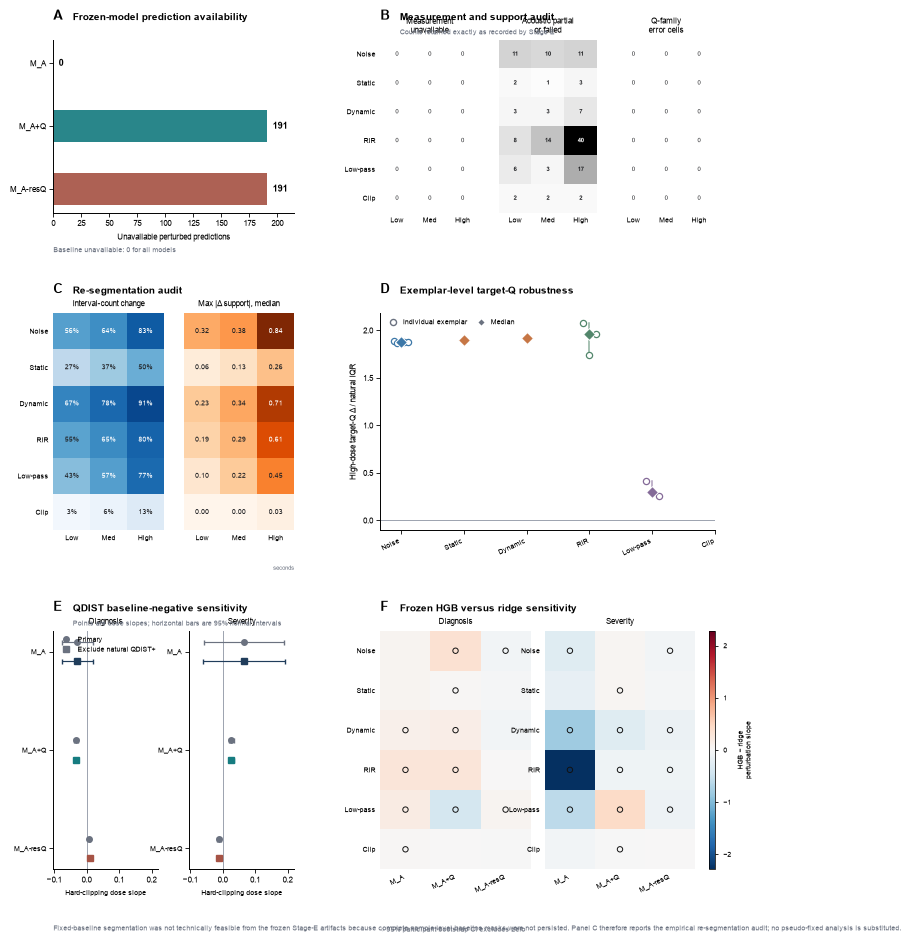

FIGURE S_G3_08 V3: WRITTEN
Panel A: prediction availability — horizontal bars
Panel B: three separate transform × dose audit matrices
Panel C: two re-segmentation matrices
Panel D: exemplar range + individual points + median
Panel E: separate diagnosis / severity QDIST forest plots
Panel F: separate diagnosis / severity HGB-vs-ridge heatmaps
Global title: REMOVED
Figure-level text: single bottom footnote only
Files: {'.pdf': 'C:\\Users\\musikicn\\Desktop\\Nevena_project\\Paper_2_Leakage\\Code\\outputs\\goal3\\FINAL_FIGURES_REVIEW\\FigureS_G3_08_robustness_V3_REVIEW.pdf', '.svg': 'C:\\Users\\musikicn\\Desktop\\Nevena_project\\Paper_2_Leakage\\Code\\outputs\\goal3\\FINAL_FIGURES_REVIEW\\FigureS_G3_08_robustness_V3_REVIEW.svg', '.png': 'C:\\Users\\musikicn\\Desktop\\Nevena_project\\Paper_2_Leakage\\Code\\outputs\\goal3\\FINAL_FIGURES_REVIEW\\FigureS_G3_08_robustness_V3_REVIEW.png'}


In [24]:
# =====================================================================
# FIGURE S_G3_08 V3
# GOAL-3 ROBUSTNESS / SUPPORT / MODEL-FORM SENSITIVITY
#
# COMPLETE PUBLICATION REDESIGN
#
# Layout:
#
#   A  Prediction availability
#   B  Measurement/support audit
#
#   C  Re-segmentation audit
#   D  Exemplar-level target-Q robustness
#
#   E  QDIST baseline-negative sensitivity
#   F  Frozen HGB versus ridge sensitivity
#
# IMPORTANT:
#   - figure-only
#   - no waveform processing
#   - no model refitting
#   - no GEE rerun
#   - no bootstrap rerun
# =====================================================================


# =====================================================================
# DISPLAY CONSTANTS
# =====================================================================

DOSE_ORDER_S8 = [
    1,
    2,
    3,
]


DOSE_LABEL_S8 = {
    1: "Low",
    2: "Med",
    3: "High",
}


TRANSFORM_DISPLAY_S8 = {
    "stationary_colored_broadband":
        "Noise",

    "uniform_level_shift":
        "Static",

    "smooth_time_varying_gain":
        "Dynamic",

    "RIR_convolution_RMS_matched":
        "RIR",

    "upper_band_restriction":
        "Low-pass",

    "symmetric_hard_clipping":
        "Clip",
}


# =====================================================================
# PANEL HEADER
# =====================================================================

def s8_panel_header(
    fig,
    axes,
    letter,
    title,
    subtitle=None,
):

    if not isinstance(
        axes,
        (
            list,
            tuple,
        ),
    ):
        axes = [
            axes
        ]


    boxes = [
        ax.get_position()
        for ax in axes
    ]


    x0 = min(
        box.x0
        for box in boxes
    )


    y1 = max(
        box.y1
        for box in boxes
    )


    fig.text(
        x0,
        y1 + 0.018,
        letter,
        fontsize=9.2,
        fontweight="bold",
        ha="left",
        va="bottom",
    )


    fig.text(
        x0 + 0.026,
        y1 + 0.018,
        title,
        fontsize=7.5,
        fontweight="bold",
        ha="left",
        va="bottom",
    )


    if subtitle is not None:

        fig.text(
            x0 + 0.026,
            y1 + 0.004,
            subtitle,
            fontsize=4.9,
            color=NEUTRAL,
            ha="left",
            va="bottom",
        )


# =====================================================================
# CLEAN AXIS
# =====================================================================

def s8_clean_axis(
    ax,
):

    ax.grid(
        False
    )


    ax.spines[
        "top"
    ].set_visible(
        False
    )


    ax.spines[
        "right"
    ].set_visible(
        False
    )


    ax.spines[
        "left"
    ].set_linewidth(
        0.7
    )


    ax.spines[
        "bottom"
    ].set_linewidth(
        0.7
    )


    ax.tick_params(
        direction="out",
        width=0.6,
        length=2.8,
        pad=2.5,
    )


# =====================================================================
# FIGURE
# =====================================================================

fig = plt.figure(
    figsize=(
        190 * MM_TO_IN,
        245 * MM_TO_IN,
    ),
    facecolor="white",
)


outer = fig.add_gridspec(
    nrows=3,
    ncols=2,

    width_ratios=[
        0.92,
        1.28,
    ],

    height_ratios=[
        0.82,
        1.03,
        1.13,
    ],

    left=0.080,
    right=0.965,
    top=0.955,
    bottom=0.095,

    hspace=0.48,
    wspace=0.30,
)


# =====================================================================
# A
# FROZEN-MODEL PREDICTION AVAILABILITY
# =====================================================================

ax_a = fig.add_subplot(
    outer[
        0,
        0,
    ]
)


pa = (
    prediction_availability
    .copy()
)


pa[
    "model"
] = (
    pa[
        "model"
    ]
    .astype(str)
)


# ---------------------------------------------------------------------
# Determine unavailable-count column robustly.
# ---------------------------------------------------------------------

unavailable_col = None


for candidate in [
    "perturbed_unavailable_rows",
    "total_unavailable_rows",
    "unavailable_rows",
]:

    if candidate in pa.columns:

        unavailable_col = candidate

        break


if unavailable_col is None:

    numeric_candidates = [
        column
        for column in pa.columns
        if (
            column != "model"
            and pd.api.types.is_numeric_dtype(
                pa[
                    column
                ]
            )
        )
    ]


    if not numeric_candidates:

        raise RuntimeError(
            "Could not identify unavailable-prediction count column."
        )


    unavailable_col = (
        numeric_candidates[
            -1
        ]
    )


pa = (
    pa
    .set_index(
        "model"
    )
    .reindex(
        MODELS
    )
    .reset_index()
)


availability_counts = (
    pd.to_numeric(
        pa[
            unavailable_col
        ],
        errors="coerce",
    )
    .fillna(0)
    .to_numpy(
        float
    )
)


y_a = np.arange(
    len(
        MODELS
    )
)


bars = ax_a.barh(
    y_a,
    availability_counts,
    height=0.50,
    color=[
        MODEL_PALETTE[
            model
        ]
        for model in MODELS
    ],
    alpha=0.92,
)


max_availability = (
    float(
        np.max(
            availability_counts
        )
    )
    if len(
        availability_counts
    )
    else 0.0
)


offset_a = max(
    2.5,
    0.025
    * max_availability,
)


for bar, value in zip(
    bars,
    availability_counts,
):

    ax_a.text(
        value + offset_a,
        bar.get_y()
        + bar.get_height()
        / 2,
        f"{int(value)}",
        fontsize=6.2,
        fontweight="bold",
        ha="left",
        va="center",
    )


ax_a.set_yticks(
    y_a
)


ax_a.set_yticklabels(
    MODELS,
    fontsize=6.0,
)


ax_a.invert_yaxis()


ax_a.set_xlabel(
    "Unavailable perturbed predictions",
    fontsize=5.8,
    labelpad=4,
)


ax_a.set_xlim(
    0,
    max(
        10,
        max_availability
        + 5
        * offset_a,
    ),
)


s8_clean_axis(
    ax_a
)


# ---------------------------------------------------------------------
# Explicit baseline status.
# ---------------------------------------------------------------------

if (
    "baseline_unavailable_rows"
    in pa.columns
):

    baseline_unavailable = (
        pd.to_numeric(
            pa[
                "baseline_unavailable_rows"
            ],
            errors="coerce",
        )
        .fillna(0)
    )


    if baseline_unavailable.eq(
        0
    ).all():

        baseline_text = (
            "Baseline unavailable: 0 for all models"
        )

    else:

        baseline_text = (
            "Baseline prediction unavailability present"
        )


    ax_a.text(
        0.0,
        -0.20,
        baseline_text,
        transform=ax_a.transAxes,
        fontsize=4.8,
        color=NEUTRAL,
        ha="left",
        va="top",
    )


s8_panel_header(
    fig,
    ax_a,
    "A",
    "Frozen-model prediction availability",
)


# =====================================================================
# B
# MEASUREMENT / SUPPORT AUDIT
#
# Three separate transform × dose matrices:
#
#   measurement unavailable
#   acoustic partial / failed
#   Q-family error cells
#
# This replaces the illegible 18-column strip.
# =====================================================================

gs_b = (
    outer[
        0,
        1,
    ]
    .subgridspec(
        nrows=1,
        ncols=3,

        wspace=0.20,
    )
)


axes_b = [
    fig.add_subplot(
        gs_b[
            0,
            i,
        ]
    )
    for i in range(
        3
    )
]


sf = (
    support_failures
    .copy()
)


sf[
    "dose_code"
] = (
    sf[
        "dose_label"
    ]
    .astype(str)
    .str.lower()
    .map(
        {
            "low": 1,
            "medium": 2,
            "high": 3,
        }
    )
)


sf_sum = (
    sf.groupby(
        [
            "transform",
            "dose_code",
        ],
        as_index=False,
    )
    .agg(
        measurement_unavailable_rows=(
            "measurement_unavailable_rows",
            "sum",
        ),

        A_partial_or_failed_rows=(
            "A_partial_or_failed_rows",
            "sum",
        ),

        Q_family_error_cells=(
            "Q_family_error_cells",
            "sum",
        ),
    )
)


audit_specs = [
    (
        "measurement_unavailable_rows",
        "Measurement\nunavailable",
    ),

    (
        "A_partial_or_failed_rows",
        "Acoustic partial\nor failed",
    ),

    (
        "Q_family_error_cells",
        "Q-family\nerror cells",
    ),
]


audit_matrices = {}


for metric, title in audit_specs:

    matrix = np.full(
        (
            len(
                TRANSFORM_ORDER
            ),
            len(
                DOSE_ORDER_S8
            ),
        ),
        np.nan,
        dtype=float,
    )


    for i, transform in enumerate(
        TRANSFORM_ORDER
    ):

        for j, dose in enumerate(
            DOSE_ORDER_S8
        ):

            z = sf_sum.loc[
                sf_sum[
                    "transform"
                ].eq(
                    transform
                )
                &
                sf_sum[
                    "dose_code"
                ].eq(
                    dose
                )
            ]


            if z.empty:
                continue


            matrix[
                i,
                j,
            ] = float(
                pd.to_numeric(
                    z[
                        metric
                    ],
                    errors="coerce",
                )
                .fillna(0)
                .sum()
            )


    audit_matrices[
        metric
    ] = matrix


for panel_index, (
    metric,
    title,
) in enumerate(
    audit_specs
):

    ax = axes_b[
        panel_index
    ]


    matrix = audit_matrices[
        metric
    ]


    finite = matrix[
        np.isfinite(
            matrix
        )
    ]


    vmax = max(
        float(
            np.max(
                finite
            )
        )
        if len(
            finite
        )
        else 0.0,
        1.0,
    )


    im = ax.imshow(
        matrix,
        aspect="auto",
        interpolation="none",
        cmap="Greys",
        vmin=0,
        vmax=vmax,
    )


    ax.set_xticks(
        np.arange(
            3
        )
    )


    ax.set_xticklabels(
        [
            "Low",
            "Med",
            "High",
        ],
        fontsize=4.8,
    )


    ax.set_yticks(
        np.arange(
            len(
                TRANSFORM_ORDER
            )
        )
    )


    if panel_index == 0:

        ax.set_yticklabels(
            [
                TRANSFORM_DISPLAY_S8[
                    transform
                ]
                for transform
                in TRANSFORM_ORDER
            ],
            fontsize=4.8,
        )

    else:

        ax.set_yticklabels(
            []
        )


    ax.set_title(
        title,
        fontsize=5.7,
        pad=5,
    )


    ax.tick_params(
        length=0,
    )


    for row_index in range(
        matrix.shape[
            0
        ]
    ):

        for col_index in range(
            matrix.shape[
                1
            ]
        ):

            value = matrix[
                row_index,
                col_index,
            ]


            if not np.isfinite(
                value
            ):

                continue


            text_color = (
                "white"
                if (
                    vmax > 0
                    and value
                    > 0.55
                    * vmax
                )
                else "#202124"
            )


            ax.text(
                col_index,
                row_index,
                f"{int(value)}",
                ha="center",
                va="center",
                fontsize=4.5,
                fontweight=(
                    "bold"
                    if value > 0
                    else "normal"
                ),
                color=text_color,
            )


    for spine in ax.spines.values():

        spine.set_visible(
            False
        )


s8_panel_header(
    fig,
    axes_b,
    "B",
    "Measurement and support audit",
    "Counts retained exactly as recorded by Stage E",
)


# =====================================================================
# C
# RE-SEGMENTATION AUDIT
#
# Two matrices:
#   fraction with interval-count change
#   median max absolute support-duration change
# =====================================================================

gs_c = (
    outer[
        1,
        0,
    ]
    .subgridspec(
        nrows=1,
        ncols=2,

        width_ratios=[
            1,
            1,
        ],

        wspace=0.18,
    )
)


ax_c1 = fig.add_subplot(
    gs_c[
        0,
        0,
    ]
)


ax_c2 = fig.add_subplot(
    gs_c[
        0,
        1,
    ]
)


seg = (
    segmentation.loc[
        segmentation[
            "task"
        ].eq(
            "diagnosis"
        )
    ]
    .copy()
)


seg_fraction = np.full(
    (
        len(
            TRANSFORM_ORDER
        ),
        3,
    ),
    np.nan,
    dtype=float,
)


seg_support = np.full(
    (
        len(
            TRANSFORM_ORDER
        ),
        3,
    ),
    np.nan,
    dtype=float,
)


for i, transform in enumerate(
    TRANSFORM_ORDER
):

    for j, dose in enumerate(
        DOSE_ORDER_S8
    ):

        z = seg.loc[
            seg[
                "transform"
            ].eq(
                transform
            )
            &
            pd.to_numeric(
                seg[
                    "dose_code"
                ],
                errors="coerce",
            )
            .eq(
                dose
            )
        ]


        if z.empty:
            continue


        fraction = pd.to_numeric(
            z[
                "fraction_rows_with_interval_count_change"
            ],
            errors="coerce",
        )


        support = pd.to_numeric(
            z[
                "median_max_abs_support_change_sec"
            ],
            errors="coerce",
        )


        if fraction.notna().any():

            seg_fraction[
                i,
                j,
            ] = float(
                fraction.mean()
            )


        if support.notna().any():

            seg_support[
                i,
                j,
            ] = float(
                support.median()
            )


# ---------------------------------------------------------------------
# C1
# ---------------------------------------------------------------------

im_c1 = ax_c1.imshow(
    seg_fraction,
    aspect="auto",
    interpolation="none",
    cmap="Blues",
    vmin=0,
    vmax=1,
)


ax_c1.set_yticks(
    np.arange(
        len(
            TRANSFORM_ORDER
        )
    )
)


ax_c1.set_yticklabels(
    [
        TRANSFORM_DISPLAY_S8[
            transform
        ]
        for transform
        in TRANSFORM_ORDER
    ],
    fontsize=4.9,
)


ax_c1.set_xticks(
    np.arange(
        3
    )
)


ax_c1.set_xticklabels(
    [
        "Low",
        "Med",
        "High",
    ],
    fontsize=4.9,
)


ax_c1.set_title(
    "Interval-count change",
    fontsize=5.8,
    pad=5,
)


ax_c1.tick_params(
    length=0,
)


for i in range(
    seg_fraction.shape[
        0
    ]
):

    for j in range(
        seg_fraction.shape[
            1
        ]
    ):

        value = seg_fraction[
            i,
            j,
        ]


        if not np.isfinite(
            value
        ):
            continue


        ax_c1.text(
            j,
            i,
            f"{100 * value:.0f}%",
            ha="center",
            va="center",
            fontsize=4.7,
            color=(
                "white"
                if value > 0.55
                else "#202124"
            ),
        )


for spine in ax_c1.spines.values():

    spine.set_visible(
        False
    )


# ---------------------------------------------------------------------
# C2
# ---------------------------------------------------------------------

finite_seg_support = seg_support[
    np.isfinite(
        seg_support
    )
]


vmax_support = max(
    float(
        np.max(
            finite_seg_support
        )
    )
    if len(
        finite_seg_support
    )
    else 0.0,
    0.01,
)


im_c2 = ax_c2.imshow(
    seg_support,
    aspect="auto",
    interpolation="none",
    cmap="Oranges",
    vmin=0,
    vmax=vmax_support,
)


ax_c2.set_yticks(
    np.arange(
        len(
            TRANSFORM_ORDER
        )
    )
)


ax_c2.set_yticklabels(
    []
)


ax_c2.set_xticks(
    np.arange(
        3
    )
)


ax_c2.set_xticklabels(
    [
        "Low",
        "Med",
        "High",
    ],
    fontsize=4.9,
)


ax_c2.set_title(
    "Max |Δ support|, median",
    fontsize=5.8,
    pad=5,
)


ax_c2.tick_params(
    length=0,
)


for i in range(
    seg_support.shape[
        0
    ]
):

    for j in range(
        seg_support.shape[
            1
        ]
    ):

        value = seg_support[
            i,
            j,
        ]


        if not np.isfinite(
            value
        ):
            continue


        ax_c2.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=4.7,
            color=(
                "white"
                if value
                > 0.55
                * vmax_support
                else "#202124"
            ),
        )


for spine in ax_c2.spines.values():

    spine.set_visible(
        False
    )


ax_c2.text(
    1.0,
    -0.16,
    "seconds",
    transform=ax_c2.transAxes,
    fontsize=4.6,
    color=NEUTRAL,
    ha="right",
    va="top",
)


s8_panel_header(
    fig,
    [
        ax_c1,
        ax_c2,
    ],
    "C",
    "Re-segmentation audit",
)


# =====================================================================
# D
# EXEMPLAR-LEVEL TARGET-Q ROBUSTNESS
# =====================================================================

ax_d = fig.add_subplot(
    outer[
        1,
        1,
    ]
)


te = (
    target_exemplar.loc[
        target_exemplar[
            "task"
        ].eq(
            "diagnosis"
        )
        &
        pd.to_numeric(
            target_exemplar[
                "dose_code"
            ],
            errors="coerce",
        )
        .eq(
            3
        )
    ]
    .copy()
)


for i, transform in enumerate(
    TRANSFORM_ORDER
):

    g = te.loc[
        te[
            "transform"
        ].eq(
            transform
        )
    ]


    vals = pd.to_numeric(
        g[
            "median_oriented_delta_natural_iqr"
        ],
        errors="coerce",
    )


    vals = vals[
        np.isfinite(
            vals
        )
    ]


    if not len(
        vals
    ):
        continue


    family = (
        str(
            g[
                "family"
            ].iloc[
                0
            ]
        )
        if len(
            g
        )
        else ""
    )


    color = FAMILY_PALETTE.get(
        family,
        NEUTRAL,
    )


    # -------------------------------------------------------------
    # Exemplar range
    # -------------------------------------------------------------

    if len(
        vals
    ) > 1:

        ax_d.plot(
            [
                i,
                i,
            ],
            [
                float(
                    vals.min()
                ),
                float(
                    vals.max()
                ),
            ],
            color=color,
            linewidth=1.1,
            alpha=0.65,
            zorder=1,
        )


    # -------------------------------------------------------------
    # Individual exemplars
    # -------------------------------------------------------------

    jitter = (
        np.linspace(
            -0.11,
            0.11,
            len(
                vals
            ),
        )
        if len(
            vals
        ) > 1
        else np.array(
            [
                0.0
            ]
        )
    )


    ax_d.scatter(
        i + jitter,
        vals,
        s=20,
        marker="o",
        facecolors="white",
        edgecolors=color,
        linewidths=0.9,
        zorder=3,
    )


    # -------------------------------------------------------------
    # Median
    # -------------------------------------------------------------

    ax_d.scatter(
        [
            i
        ],
        [
            float(
                np.median(
                    vals
                )
            )
        ],
        s=36,
        marker="D",
        facecolors=color,
        edgecolors="white",
        linewidths=0.7,
        zorder=4,
    )


ax_d.axhline(
    0,
    color=MID,
    linewidth=0.7,
)


ax_d.set_xticks(
    np.arange(
        len(
            TRANSFORM_ORDER
        )
    )
)


ax_d.set_xticklabels(
    [
        TRANSFORM_DISPLAY_S8[
            transform
        ]
        for transform
        in TRANSFORM_ORDER
    ],
    rotation=25,
    ha="right",
    fontsize=5.2,
)


ax_d.set_ylabel(
    "High-dose target-Q Δ / natural IQR",
    fontsize=5.8,
    labelpad=4,
)


s8_clean_axis(
    ax_d
)


# ---------------------------------------------------------------------
# Compact legend above the data but inside panel.
# ---------------------------------------------------------------------

ax_d.legend(
    handles=[
        Line2D(
            [0],
            [0],
            marker="o",
            markerfacecolor="white",
            markeredgecolor=NEUTRAL,
            linestyle="none",
            markersize=4.4,
            label="Individual exemplar",
        ),

        Line2D(
            [0],
            [0],
            marker="D",
            markerfacecolor=NEUTRAL,
            markeredgecolor="white",
            linestyle="none",
            markersize=4.4,
            label="Median",
        ),
    ],
    frameon=False,
    fontsize=4.9,
    loc="upper left",
    ncol=2,
    columnspacing=1.1,
    handletextpad=0.4,
)


s8_panel_header(
    fig,
    ax_d,
    "D",
    "Exemplar-level target-Q robustness",
)


# =====================================================================
# E
# QDIST BASELINE-NEGATIVE SENSITIVITY
#
# Two task-specific forest plots.
# =====================================================================

gs_e = (
    outer[
        2,
        0,
    ]
    .subgridspec(
        nrows=1,
        ncols=2,

        width_ratios=[
            1,
            1,
        ],

        wspace=0.30,
    )
)


ax_e_dx = fig.add_subplot(
    gs_e[
        0,
        0,
    ]
)


ax_e_sev = fig.add_subplot(
    gs_e[
        0,
        1,
    ]
)


primary_qdist = (
    clinical_linear.loc[
        clinical_linear[
            "transform"
        ].eq(
            "symmetric_hard_clipping"
        )
        &
        (
            (
                clinical_linear[
                    "task"
                ].eq(
                    "diagnosis"
                )
                &
                clinical_linear[
                    "endpoint"
                ].eq(
                    "delta_logit"
                )
            )
            |
            (
                clinical_linear[
                    "task"
                ].eq(
                    "severity"
                )
                &
                clinical_linear[
                    "endpoint"
                ].eq(
                    "delta_prediction"
                )
            )
        )
    ]
    .copy()
)


restricted_qdist = (
    qdist_sensitivity.loc[
        (
            (
                qdist_sensitivity[
                    "task"
                ].eq(
                    "diagnosis"
                )
                &
                qdist_sensitivity[
                    "endpoint"
                ].eq(
                    "delta_logit"
                )
            )
            |
            (
                qdist_sensitivity[
                    "task"
                ].eq(
                    "severity"
                )
                &
                qdist_sensitivity[
                    "endpoint"
                ].eq(
                    "delta_prediction"
                )
            )
        )
    ]
    .copy()
)


forest_rows = []


for task in [
    "diagnosis",
    "severity",
]:

    for model in MODELS:

        p = primary_qdist.loc[
            primary_qdist[
                "task"
            ].eq(
                task
            )
            &
            primary_qdist[
                "model"
            ].eq(
                model
            )
        ]


        r = restricted_qdist.loc[
            restricted_qdist[
                "task"
            ].eq(
                task
            )
            &
            restricted_qdist[
                "model"
            ].eq(
                model
            )
        ]


        if (
            len(
                p
            ) != 1
            or len(
                r
            ) != 1
        ):
            continue


        forest_rows.append({
            "task":
                task,

            "model":
                model,

            "primary":
                float(
                    p[
                        "estimate"
                    ].iloc[
                        0
                    ]
                ),

            "primary_se":
                float(
                    p[
                        "se"
                    ].iloc[
                        0
                    ]
                ),

            "restricted":
                float(
                    r[
                        "estimate_per_dose"
                    ].iloc[
                        0
                    ]
                ),

            "restricted_se":
                float(
                    r[
                        "se"
                    ].iloc[
                        0
                    ]
                ),
        })


forest = pd.DataFrame(
    forest_rows
)


# ---------------------------------------------------------------------
# Shared x scale between Diagnosis and Severity.
# ---------------------------------------------------------------------

forest_limits = []


for _, row in forest.iterrows():

    forest_limits.extend([
        row[
            "primary"
        ]
        - 1.96
        * row[
            "primary_se"
        ],

        row[
            "primary"
        ]
        + 1.96
        * row[
            "primary_se"
        ],

        row[
            "restricted"
        ]
        - 1.96
        * row[
            "restricted_se"
        ],

        row[
            "restricted"
        ]
        + 1.96
        * row[
            "restricted_se"
        ],
    ])


if forest_limits:

    forest_lo = float(
        min(
            forest_limits
        )
    )

    forest_hi = float(
        max(
            forest_limits
        )
    )


    forest_pad = max(
        0.01,
        0.10
        * (
            forest_hi
            - forest_lo
        ),
    )


    forest_xlim = (
        forest_lo
        - forest_pad,
        forest_hi
        + forest_pad,
    )

else:

    forest_xlim = (
        -1,
        1,
    )


for ax, task, title in [
    (
        ax_e_dx,
        "diagnosis",
        "Diagnosis",
    ),

    (
        ax_e_sev,
        "severity",
        "Severity",
    ),
]:

    g = (
        forest.loc[
            forest[
                "task"
            ].eq(
                task
            )
        ]
        .set_index(
            "model"
        )
        .reindex(
            MODELS
        )
        .reset_index()
    )


    y_positions = np.arange(
        len(
            MODELS
        )
    )


    for i, row in g.iterrows():

        model = str(
            row[
                "model"
            ]
        )


        color = MODEL_PALETTE[
            model
        ]


        # ---------------------------------------------------------
        # Primary
        # ---------------------------------------------------------

        ax.errorbar(
            row[
                "primary"
            ],
            i - 0.10,
            xerr=1.96
            * row[
                "primary_se"
            ],
            fmt="o",
            color=NEUTRAL,
            ecolor=NEUTRAL,
            markersize=4.0,
            capsize=1.8,
            linewidth=0.85,
            zorder=3,
        )


        # ---------------------------------------------------------
        # Restricted
        # ---------------------------------------------------------

        ax.errorbar(
            row[
                "restricted"
            ],
            i + 0.10,
            xerr=1.96
            * row[
                "restricted_se"
            ],
            fmt="s",
            color=color,
            ecolor=color,
            markersize=4.0,
            capsize=1.8,
            linewidth=0.85,
            zorder=4,
        )


    ax.axvline(
        0,
        color=MID,
        linewidth=0.7,
    )


    ax.set_yticks(
        y_positions
    )


    ax.set_yticklabels(
        MODELS,
        fontsize=5.2,
    )


    ax.invert_yaxis()


    ax.set_xlim(
        *forest_xlim
    )


    ax.set_title(
        title,
        fontsize=5.9,
        pad=5,
    )


    ax.set_xlabel(
        "Hard-clipping dose slope",
        fontsize=5.2,
    )


    s8_clean_axis(
        ax
    )


ax_e_dx.legend(
    handles=[
        Line2D(
            [0],
            [0],
            marker="o",
            color=NEUTRAL,
            lw=0,
            markersize=4,
            label="Primary",
        ),

        Line2D(
            [0],
            [0],
            marker="s",
            color=NEUTRAL,
            lw=0,
            markersize=4,
            label="Exclude natural QDIST+",
        ),
    ],
    frameon=False,
    fontsize=4.7,
    loc="upper left",
)


s8_panel_header(
    fig,
    [
        ax_e_dx,
        ax_e_sev,
    ],
    "E",
    "QDIST baseline-negative sensitivity",
    "Points are dose slopes; horizontal bars are 95% normal intervals",
)


# =====================================================================
# F
# FROZEN HGB VERSUS RIDGE
#
# Diagnosis and Severity separate, large, aligned.
# =====================================================================

gs_f = (
    outer[
        2,
        1,
    ]
    .subgridspec(
        nrows=1,
        ncols=3,

        width_ratios=[
            1,
            1,
            0.040,
        ],

        wspace=0.14,
    )
)


ax_f_dx = fig.add_subplot(
    gs_f[
        0,
        0,
    ]
)


ax_f_sev = fig.add_subplot(
    gs_f[
        0,
        1,
    ]
)


cax_f = fig.add_subplot(
    gs_f[
        0,
        2,
    ]
)


hv = (
    hgb_vs_ridge
    .copy()
)


hgb_models_order = list(
    HGB_TO_RIDGE.keys()
)


def s8_build_hgb_matrix(
    task,
):

    estimates = np.full(
        (
            len(
                TRANSFORM_ORDER
            ),
            len(
                hgb_models_order
            ),
        ),
        np.nan,
        dtype=float,
    )


    significant = np.zeros(
        estimates.shape,
        dtype=bool,
    )


    for i, transform in enumerate(
        TRANSFORM_ORDER
    ):

        for j, hgb_model in enumerate(
            hgb_models_order
        ):

            z = hv.loc[
                hv[
                    "task"
                ].eq(
                    task
                )
                &
                hv[
                    "transform"
                ].eq(
                    transform
                )
                &
                hv[
                    "hgb_model"
                ].eq(
                    hgb_model
                )
            ]


            if len(
                z
            ) != 1:

                continue


            estimate = float(
                z[
                    "estimate_hgb_minus_ridge_slope"
                ].iloc[
                    0
                ]
            )


            lo = float(
                z[
                    "ci_low"
                ].iloc[
                    0
                ]
            )


            hi = float(
                z[
                    "ci_high"
                ].iloc[
                    0
                ]
            )


            estimates[
                i,
                j,
            ] = estimate


            significant[
                i,
                j,
            ] = bool(
                lo > 0
                or hi < 0
            )


    return (
        estimates,
        significant,
    )


dx_hgb_matrix, dx_hgb_sig = (
    s8_build_hgb_matrix(
        "diagnosis"
    )
)


sev_hgb_matrix, sev_hgb_sig = (
    s8_build_hgb_matrix(
        "severity"
    )
)


hgb_finite_parts = []


if np.isfinite(
    dx_hgb_matrix
).any():

    hgb_finite_parts.append(
        dx_hgb_matrix[
            np.isfinite(
                dx_hgb_matrix
            )
        ]
    )


if np.isfinite(
    sev_hgb_matrix
).any():

    hgb_finite_parts.append(
        sev_hgb_matrix[
            np.isfinite(
                sev_hgb_matrix
            )
        ]
    )


if hgb_finite_parts:

    all_hgb_values = np.concatenate(
        hgb_finite_parts
    )


    hgb_vmax = max(
        float(
            np.max(
                np.abs(
                    all_hgb_values
                )
            )
        ),
        1e-6,
    )

else:

    hgb_vmax = 1.0


hgb_cmap = (
    mpl.colormaps[
        "RdBu_r"
    ]
    .copy()
)


hgb_cmap.set_bad(
    "#E9ECEF"
)


hgb_column_labels = [
    "M_A",
    "M_A+Q",
    "M_A-resQ",
]


for ax, matrix, sig, title, show_y in [
    (
        ax_f_dx,
        dx_hgb_matrix,
        dx_hgb_sig,
        "Diagnosis",
        True,
    ),

    (
        ax_f_sev,
        sev_hgb_matrix,
        sev_hgb_sig,
        "Severity",
        True,
    ),
]:

    im_f = ax.imshow(
        matrix,
        aspect="auto",
        interpolation="none",
        cmap=hgb_cmap,
        vmin=-hgb_vmax,
        vmax=hgb_vmax,
    )


    ax.set_xticks(
        np.arange(
            len(
                hgb_column_labels
            )
        )
    )


    ax.set_xticklabels(
        hgb_column_labels,
        rotation=26,
        ha="right",
        fontsize=5.0,
    )


    ax.set_yticks(
        np.arange(
            len(
                TRANSFORM_ORDER
            )
        )
    )


    if show_y:

        ax.set_yticklabels(
            [
                TRANSFORM_DISPLAY_S8[
                    transform
                ]
                for transform
                in TRANSFORM_ORDER
            ],
            fontsize=4.8,
        )


    ax.set_title(
        title,
        fontsize=5.9,
        pad=5,
    )


    ax.tick_params(
        length=0,
    )


    # -------------------------------------------------------------
    # Open circle where bootstrap CI excludes zero.
    # -------------------------------------------------------------

    yy, xx = np.where(
        sig
        &
        np.isfinite(
            matrix
        )
    )


    ax.scatter(
        xx,
        yy,
        s=15,
        marker="o",
        facecolors="none",
        edgecolors="#111111",
        linewidths=0.70,
        zorder=4,
    )


    for spine in ax.spines.values():

        spine.set_visible(
            False
        )


cb_f = fig.colorbar(
    im_f,
    cax=cax_f,
)


cb_f.set_label(
    "HGB − ridge\nperturbation slope",
    fontsize=5.2,
    labelpad=4,
)


cb_f.ax.tick_params(
    labelsize=4.8,
    length=2.2,
)


cb_f.outline.set_linewidth(
    0.55
)


# ---------------------------------------------------------------------
# Symbol explanation beneath F only.
# ---------------------------------------------------------------------

ax_f_dx.text(
    0.0,
    -0.24,
    "○ 95% participant-bootstrap CI excludes zero",
    transform=ax_f_dx.transAxes,
    fontsize=4.7,
    color=NEUTRAL,
    ha="left",
    va="top",
)


s8_panel_header(
    fig,
    [
        ax_f_dx,
        ax_f_sev,
    ],
    "F",
    "Frozen HGB versus ridge sensitivity",
)


# =====================================================================
# SOURCE EXPORTS
# =====================================================================

atomic_csv(
    pa,
    SOURCE_TABLES
    / "FigureS_G3_08V3_A_prediction_availability.csv",
)


atomic_csv(
    sf_sum,
    SOURCE_TABLES
    / "FigureS_G3_08V3_B_support_failures.csv",
)


atomic_csv(
    seg,
    SOURCE_TABLES
    / "FigureS_G3_08V3_C_segmentation.csv",
)


atomic_csv(
    te,
    SOURCE_TABLES
    / "FigureS_G3_08V3_D_target_exemplar.csv",
)


atomic_csv(
    forest,
    SOURCE_TABLES
    / "FigureS_G3_08V3_E_qdist_sensitivity.csv",
)


atomic_csv(
    hv,
    SOURCE_TABLES
    / "FigureS_G3_08V3_F_hgb_vs_ridge.csv",
)


# =====================================================================
# SINGLE FIGURE FOOTNOTE
#
# No large global title.
# No text above panels.
# =====================================================================

fig.text(
    0.080,
    0.030,
    (
        "Fixed-baseline segmentation was not technically feasible from "
        "the frozen Stage-E artifacts because complete sample-level baseline "
        "masks were not persisted. Panel C therefore reports the empirical "
        "re-segmentation audit; no pseudo-fixed analysis is substituted."
    ),
    fontsize=4.9,
    color=NEUTRAL,
    ha="left",
    va="bottom",
)


# =====================================================================
# EXPORT
# =====================================================================

figureS8_v3_files = save_figure(
    fig,
    "FigureS_G3_08_robustness_V3_REVIEW",
    [
        PATHS[
            "prediction_availability"
        ],

        PATHS[
            "support_failures"
        ],

        PATHS[
            "segmentation"
        ],

        PATHS[
            "target_exemplar"
        ],

        PATHS[
            "qdist_sensitivity"
        ],

        PATHS[
            "clinical_linear"
        ],

        PATHS[
            "hgb_vs_ridge"
        ],

        PATHS[
            "fixed_seg_disposition"
        ],
    ],
)


plt.show()


# =====================================================================
# FINAL AUDIT
# =====================================================================

print(
    "=" * 78
)

print(
    "FIGURE S_G3_08 V3: WRITTEN"
)

print(
    "=" * 78
)

print(
    "Panel A:",
    "prediction availability — horizontal bars",
)

print(
    "Panel B:",
    "three separate transform × dose audit matrices",
)

print(
    "Panel C:",
    "two re-segmentation matrices",
)

print(
    "Panel D:",
    "exemplar range + individual points + median",
)

print(
    "Panel E:",
    "separate diagnosis / severity QDIST forest plots",
)

print(
    "Panel F:",
    "separate diagnosis / severity HGB-vs-ridge heatmaps",
)

print(
    "Global title:",
    "REMOVED",
)

print(
    "Figure-level text:",
    "single bottom footnote only",
)

print(
    "Files:",
    figureS8_v3_files,
)

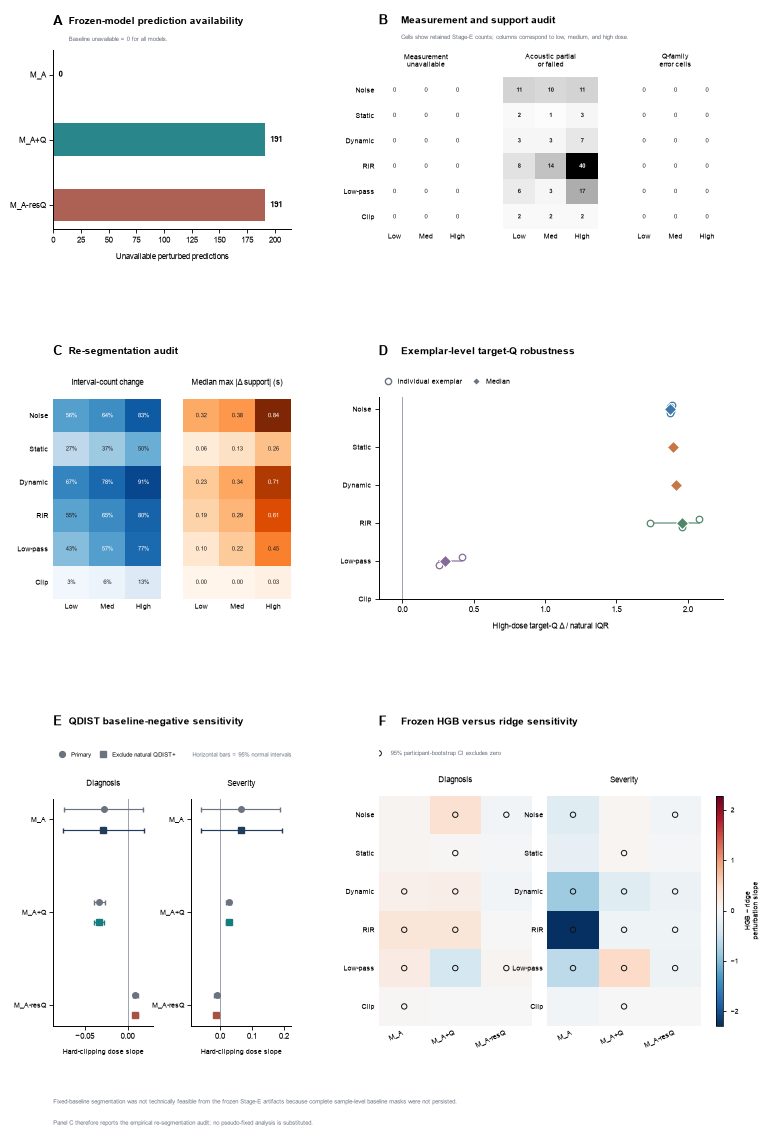

FIGURE S_G3_08 V7: WRITTEN
A baseline note: ABOVE PLOT
B explanatory note: ABOVE MATRICES
B metric titles: DEDICATED ROW
C subpanel titles: DEDICATED ROW
D legend: DEDICATED ROW ABOVE PLOT
E legend / interval note: DEDICATED ROW ABOVE FORESTS
E task titles: DEDICATED ROW
F CI explanation: DEDICATED ROW ABOVE MATRICES
F task titles: DEDICATED ROW
Panel-level annotations below axes: NONE
Files: {'.pdf': 'C:\\Users\\musikicn\\Desktop\\Nevena_project\\Paper_2_Leakage\\Code\\outputs\\goal3\\FINAL_FIGURES_REVIEW\\FigureS_G3_08_robustness_V7_REVIEW.pdf', '.svg': 'C:\\Users\\musikicn\\Desktop\\Nevena_project\\Paper_2_Leakage\\Code\\outputs\\goal3\\FINAL_FIGURES_REVIEW\\FigureS_G3_08_robustness_V7_REVIEW.svg', '.png': 'C:\\Users\\musikicn\\Desktop\\Nevena_project\\Paper_2_Leakage\\Code\\outputs\\goal3\\FINAL_FIGURES_REVIEW\\FigureS_G3_08_robustness_V7_REVIEW.png'}


In [27]:
# =====================================================================
# FIGURE S_G3_08 V7
# ROBUSTNESS / SUPPORT / SEGMENTATION / MODEL-FORM SENSITIVITY
#
# HARD LAYOUT RULE:
#
#   NOTHING except axis labels/ticks is drawn below an individual plot.
#
# All:
#   - panel titles
#   - subtitles
#   - subpanel titles
#   - legends
#   - symbol explanations
#
# live in dedicated GridSpec rows ABOVE the relevant plots.
#
# This eliminates the remaining V6 collisions.
#
# FIGURE ONLY:
#   - no waveform processing
#   - no feature extraction
#   - no model refitting
#   - no GEE rerun
#   - no bootstrap rerun
# =====================================================================


# =====================================================================
# DISPLAY CONSTANTS
# =====================================================================

DOSE_ORDER_S8 = [
    1,
    2,
    3,
]


TRANSFORM_DISPLAY_S8 = {
    "stationary_colored_broadband":
        "Noise",

    "uniform_level_shift":
        "Static",

    "smooth_time_varying_gain":
        "Dynamic",

    "RIR_convolution_RMS_matched":
        "RIR",

    "upper_band_restriction":
        "Low-pass",

    "symmetric_hard_clipping":
        "Clip",
}


# =====================================================================
# HELPERS
# =====================================================================

def s8_clean_axis(ax):

    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.70)
    ax.spines["bottom"].set_linewidth(0.70)

    ax.tick_params(
        direction="out",
        width=0.60,
        length=2.7,
        pad=2.5,
    )


def s8_text_axis(ax):

    ax.set_xlim(
        0,
        1,
    )

    ax.set_ylim(
        0,
        1,
    )

    ax.axis(
        "off"
    )


def s8_panel_header(
    ax,
    letter,
    title,
    subtitle=None,
):

    s8_text_axis(
        ax
    )


    ax.text(
        0.00,
        0.68 if subtitle is not None else 0.50,
        letter,
        fontsize=9.2,
        fontweight="bold",
        ha="left",
        va="center",
    )


    ax.text(
        0.065,
        0.68 if subtitle is not None else 0.50,
        title,
        fontsize=7.5,
        fontweight="bold",
        ha="left",
        va="center",
    )


    if subtitle is not None:

        ax.text(
            0.065,
            0.18,
            subtitle,
            fontsize=4.65,
            color=NEUTRAL,
            ha="left",
            va="center",
        )


# =====================================================================
# FIGURE
#
# Deliberately taller.
# =====================================================================

fig = plt.figure(
    figsize=(
        190 * MM_TO_IN,
        300 * MM_TO_IN,
    ),
    facecolor="white",
)


outer = fig.add_gridspec(
    nrows=3,
    ncols=2,

    width_ratios=[
        0.90,
        1.30,
    ],

    height_ratios=[
        0.92,
        1.10,
        1.34,
    ],

    left=0.075,
    right=0.970,
    top=0.975,
    bottom=0.115,

    hspace=0.40,
    wspace=0.30,
)


# =====================================================================
# A — FROZEN-MODEL PREDICTION AVAILABILITY
#
# Baseline note moved ABOVE plot into panel header.
# =====================================================================

gs_a = (
    outer[
        0,
        0,
    ]
    .subgridspec(
        nrows=2,
        ncols=1,

        height_ratios=[
            0.20,
            1.00,
        ],

        hspace=0.04,
    )
)


head_a = fig.add_subplot(
    gs_a[
        0,
        0,
    ]
)


ax_a = fig.add_subplot(
    gs_a[
        1,
        0,
    ]
)


pa = (
    prediction_availability
    .copy()
)


pa[
    "model"
] = pa[
    "model"
].astype(str)


# ---------------------------------------------------------------------
# Resolve unavailable prediction column.
# ---------------------------------------------------------------------

unavailable_col = None


for candidate in [
    "perturbed_unavailable_rows",
    "total_unavailable_rows",
    "unavailable_rows",
]:

    if candidate in pa.columns:

        unavailable_col = candidate
        break


if unavailable_col is None:

    numeric_candidates = [
        c
        for c in pa.columns
        if (
            c != "model"
            and pd.api.types.is_numeric_dtype(
                pa[c]
            )
        )
    ]


    if not numeric_candidates:

        raise RuntimeError(
            "Could not identify unavailable-prediction count column."
        )


    unavailable_col = numeric_candidates[
        -1
    ]


pa = (
    pa
    .set_index("model")
    .reindex(MODELS)
    .reset_index()
)


availability_counts = (
    pd.to_numeric(
        pa[
            unavailable_col
        ],
        errors="coerce",
    )
    .fillna(0)
    .to_numpy(float)
)


baseline_subtitle = None


if (
    "baseline_unavailable_rows"
    in pa.columns
):

    baseline_vals = (
        pd.to_numeric(
            pa[
                "baseline_unavailable_rows"
            ],
            errors="coerce",
        )
        .fillna(0)
    )


    if baseline_vals.eq(0).all():

        baseline_subtitle = (
            "Baseline unavailable = 0 for all models."
        )


s8_panel_header(
    head_a,
    "A",
    "Frozen-model prediction availability",
    baseline_subtitle,
)


y_a = np.arange(
    len(
        MODELS
    )
)


bars = ax_a.barh(
    y_a,
    availability_counts,
    height=0.50,
    color=[
        MODEL_PALETTE[
            m
        ]
        for m in MODELS
    ],
    alpha=0.92,
)


max_availability = (
    float(
        np.max(
            availability_counts
        )
    )
    if len(
        availability_counts
    )
    else 0.0
)


label_offset = max(
    2.5,
    0.025
    * max_availability,
)


for bar, value in zip(
    bars,
    availability_counts,
):

    ax_a.text(
        value
        + label_offset,
        bar.get_y()
        + bar.get_height()
        / 2,
        f"{int(value)}",
        fontsize=6.1,
        fontweight="bold",
        ha="left",
        va="center",
    )


ax_a.set_yticks(
    y_a
)


ax_a.set_yticklabels(
    MODELS,
    fontsize=5.9,
)


ax_a.invert_yaxis()


ax_a.set_xlabel(
    "Unavailable perturbed predictions",
    fontsize=5.7,
    labelpad=6,
)


ax_a.set_xlim(
    0,
    max(
        10,
        max_availability
        + 5
        * label_offset,
    ),
)


s8_clean_axis(
    ax_a
)


# =====================================================================
# B — MEASUREMENT AND SUPPORT AUDIT
#
# Main title + explanatory statement:
#   dedicated header
#
# Three metric titles:
#   dedicated title row
#
# Data:
#   dedicated matrix row
#
# NOTHING below matrices.
# =====================================================================

gs_b_outer = (
    outer[
        0,
        1,
    ]
    .subgridspec(
        nrows=3,
        ncols=1,

        height_ratios=[
            0.22,
            0.16,
            1.00,
        ],

        hspace=0.07,
    )
)


head_b = fig.add_subplot(
    gs_b_outer[
        0,
        0,
    ]
)


s8_panel_header(
    head_b,
    "B",
    "Measurement and support audit",
    (
        "Cells show retained Stage-E counts; "
        "columns correspond to low, medium, and high dose."
    ),
)


# ---------------------------------------------------------------------
# Dedicated metric-title row.
# ---------------------------------------------------------------------

gs_b_titles = (
    gs_b_outer[
        1,
        0,
    ]
    .subgridspec(
        nrows=1,
        ncols=3,
        wspace=0.32,
    )
)


title_axes_b = [
    fig.add_subplot(
        gs_b_titles[
            0,
            i,
        ]
    )
    for i in range(
        3
    )
]


for ax in title_axes_b:

    s8_text_axis(
        ax
    )


metric_titles = [
    "Measurement\nunavailable",
    "Acoustic partial\nor failed",
    "Q-family\nerror cells",
]


for ax, title in zip(
    title_axes_b,
    metric_titles,
):

    ax.text(
        0.50,
        0.50,
        title,
        fontsize=5.25,
        ha="center",
        va="center",
        linespacing=1.10,
    )


# ---------------------------------------------------------------------
# Data row.
# ---------------------------------------------------------------------

gs_b_data = (
    gs_b_outer[
        2,
        0,
    ]
    .subgridspec(
        nrows=1,
        ncols=3,
        wspace=0.32,
    )
)


axes_b = [
    fig.add_subplot(
        gs_b_data[
            0,
            i,
        ]
    )
    for i in range(
        3
    )
]


sf = support_failures.copy()


sf[
    "dose_code"
] = (
    sf[
        "dose_label"
    ]
    .astype(str)
    .str.lower()
    .map(
        {
            "low": 1,
            "medium": 2,
            "high": 3,
        }
    )
)


sf_sum = (
    sf.groupby(
        [
            "transform",
            "dose_code",
        ],
        as_index=False,
    )
    .agg(
        measurement_unavailable_rows=(
            "measurement_unavailable_rows",
            "sum",
        ),

        A_partial_or_failed_rows=(
            "A_partial_or_failed_rows",
            "sum",
        ),

        Q_family_error_cells=(
            "Q_family_error_cells",
            "sum",
        ),
    )
)


audit_metrics = [
    "measurement_unavailable_rows",
    "A_partial_or_failed_rows",
    "Q_family_error_cells",
]


audit_matrices = {}


for metric in audit_metrics:

    matrix = np.full(
        (
            len(
                TRANSFORM_ORDER
            ),
            3,
        ),
        np.nan,
        dtype=float,
    )


    for i, transform in enumerate(
        TRANSFORM_ORDER
    ):

        for j, dose in enumerate(
            DOSE_ORDER_S8
        ):

            z = sf_sum.loc[
                sf_sum[
                    "transform"
                ].eq(
                    transform
                )
                &
                sf_sum[
                    "dose_code"
                ].eq(
                    dose
                )
            ]


            if z.empty:
                continue


            matrix[
                i,
                j,
            ] = float(
                pd.to_numeric(
                    z[
                        metric
                    ],
                    errors="coerce",
                )
                .fillna(0)
                .sum()
            )


    audit_matrices[
        metric
    ] = matrix


for panel_index, metric in enumerate(
    audit_metrics
):

    ax = axes_b[
        panel_index
    ]


    matrix = audit_matrices[
        metric
    ]


    finite = matrix[
        np.isfinite(
            matrix
        )
    ]


    vmax = max(
        float(
            np.max(
                finite
            )
        )
        if len(
            finite
        )
        else 0.0,
        1.0,
    )


    ax.imshow(
        matrix,
        aspect="auto",
        interpolation="none",
        cmap="Greys",
        vmin=0,
        vmax=vmax,
    )


    ax.set_xticks(
        np.arange(
            3
        )
    )


    ax.set_xticklabels(
        [
            "Low",
            "Med",
            "High",
        ],
        fontsize=4.8,
    )


    ax.set_yticks(
        np.arange(
            len(
                TRANSFORM_ORDER
            )
        )
    )


    if panel_index == 0:

        ax.set_yticklabels(
            [
                TRANSFORM_DISPLAY_S8[
                    t
                ]
                for t
                in TRANSFORM_ORDER
            ],
            fontsize=4.8,
        )

    else:

        ax.set_yticklabels(
            []
        )


    ax.tick_params(
        length=0,
        pad=3,
    )


    for r in range(
        matrix.shape[
            0
        ]
    ):

        for c in range(
            matrix.shape[
                1
            ]
        ):

            value = matrix[
                r,
                c,
            ]


            if not np.isfinite(
                value
            ):
                continue


            ax.text(
                c,
                r,
                f"{int(value)}",
                ha="center",
                va="center",
                fontsize=4.45,
                fontweight=(
                    "bold"
                    if value > 0
                    else "normal"
                ),
                color=(
                    "white"
                    if value
                    > 0.55
                    * vmax
                    else "#202124"
                ),
            )


    for spine in ax.spines.values():

        spine.set_visible(
            False
        )


# =====================================================================
# C — RE-SEGMENTATION AUDIT
#
# Fix:
#   main panel title
#   separate subpanel-title row
#   data row
#
# No ax.set_title() calls on heatmaps.
# =====================================================================

gs_c_outer = (
    outer[
        1,
        0,
    ]
    .subgridspec(
        nrows=3,
        ncols=1,

        height_ratios=[
            0.15,
            0.12,
            1.00,
        ],

        hspace=0.05,
    )
)


head_c = fig.add_subplot(
    gs_c_outer[
        0,
        0,
    ]
)


s8_panel_header(
    head_c,
    "C",
    "Re-segmentation audit",
)


# ---------------------------------------------------------------------
# Dedicated subpanel-title row.
# ---------------------------------------------------------------------

gs_c_titles = (
    gs_c_outer[
        1,
        0,
    ]
    .subgridspec(
        nrows=1,
        ncols=2,
        wspace=0.20,
    )
)


title_c1 = fig.add_subplot(
    gs_c_titles[
        0,
        0,
    ]
)


title_c2 = fig.add_subplot(
    gs_c_titles[
        0,
        1,
    ]
)


for ax in [
    title_c1,
    title_c2,
]:

    s8_text_axis(
        ax
    )


title_c1.text(
    0.50,
    0.50,
    "Interval-count change",
    fontsize=5.7,
    ha="center",
    va="center",
)


title_c2.text(
    0.50,
    0.50,
    "Median max |Δ support| (s)",
    fontsize=5.7,
    ha="center",
    va="center",
)


# ---------------------------------------------------------------------
# Data.
# ---------------------------------------------------------------------

gs_c_data = (
    gs_c_outer[
        2,
        0,
    ]
    .subgridspec(
        nrows=1,
        ncols=2,
        wspace=0.20,
    )
)


ax_c1 = fig.add_subplot(
    gs_c_data[
        0,
        0,
    ]
)


ax_c2 = fig.add_subplot(
    gs_c_data[
        0,
        1,
    ]
)


seg = (
    segmentation.loc[
        segmentation[
            "task"
        ].eq(
            "diagnosis"
        )
    ]
    .copy()
)


seg_fraction = np.full(
    (
        len(
            TRANSFORM_ORDER
        ),
        3,
    ),
    np.nan,
)


seg_support = np.full(
    (
        len(
            TRANSFORM_ORDER
        ),
        3,
    ),
    np.nan,
)


for i, transform in enumerate(
    TRANSFORM_ORDER
):

    for j, dose in enumerate(
        DOSE_ORDER_S8
    ):

        z = seg.loc[
            seg[
                "transform"
            ].eq(
                transform
            )
            &
            pd.to_numeric(
                seg[
                    "dose_code"
                ],
                errors="coerce",
            )
            .eq(
                dose
            )
        ]


        if z.empty:
            continue


        frac = pd.to_numeric(
            z[
                "fraction_rows_with_interval_count_change"
            ],
            errors="coerce",
        )


        support = pd.to_numeric(
            z[
                "median_max_abs_support_change_sec"
            ],
            errors="coerce",
        )


        if frac.notna().any():

            seg_fraction[
                i,
                j,
            ] = float(
                frac.mean()
            )


        if support.notna().any():

            seg_support[
                i,
                j,
            ] = float(
                support.median()
            )


# ---------------------------------------------------------------------
# C1 matrix
# ---------------------------------------------------------------------

ax_c1.imshow(
    seg_fraction,
    aspect="auto",
    interpolation="none",
    cmap="Blues",
    vmin=0,
    vmax=1,
)


ax_c1.set_yticks(
    np.arange(
        len(
            TRANSFORM_ORDER
        )
    )
)


ax_c1.set_yticklabels(
    [
        TRANSFORM_DISPLAY_S8[
            t
        ]
        for t
        in TRANSFORM_ORDER
    ],
    fontsize=4.8,
)


ax_c1.set_xticks(
    np.arange(
        3
    )
)


ax_c1.set_xticklabels(
    [
        "Low",
        "Med",
        "High",
    ],
    fontsize=4.8,
)


ax_c1.tick_params(
    length=0,
)


for i in range(
    seg_fraction.shape[
        0
    ]
):

    for j in range(
        seg_fraction.shape[
            1
        ]
    ):

        value = seg_fraction[
            i,
            j,
        ]


        if not np.isfinite(
            value
        ):
            continue


        ax_c1.text(
            j,
            i,
            f"{100 * value:.0f}%",
            ha="center",
            va="center",
            fontsize=4.6,
            color=(
                "white"
                if value > 0.55
                else "#202124"
            ),
        )


for spine in ax_c1.spines.values():

    spine.set_visible(
        False
    )


# ---------------------------------------------------------------------
# C2 matrix
# ---------------------------------------------------------------------

finite_support = seg_support[
    np.isfinite(
        seg_support
    )
]


vmax_support = max(
    float(
        np.max(
            finite_support
        )
    )
    if len(
        finite_support
    )
    else 0.0,
    0.01,
)


ax_c2.imshow(
    seg_support,
    aspect="auto",
    interpolation="none",
    cmap="Oranges",
    vmin=0,
    vmax=vmax_support,
)


ax_c2.set_yticks(
    np.arange(
        len(
            TRANSFORM_ORDER
        )
    )
)


ax_c2.set_yticklabels(
    []
)


ax_c2.set_xticks(
    np.arange(
        3
    )
)


ax_c2.set_xticklabels(
    [
        "Low",
        "Med",
        "High",
    ],
    fontsize=4.8,
)


ax_c2.tick_params(
    length=0,
)


for i in range(
    seg_support.shape[
        0
    ]
):

    for j in range(
        seg_support.shape[
            1
        ]
    ):

        value = seg_support[
            i,
            j,
        ]


        if not np.isfinite(
            value
        ):
            continue


        ax_c2.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=4.6,
            color=(
                "white"
                if value
                > 0.55
                * vmax_support
                else "#202124"
            ),
        )


for spine in ax_c2.spines.values():

    spine.set_visible(
        False
    )


# =====================================================================
# D — EXEMPLAR-LEVEL TARGET-Q ROBUSTNESS
#
# Title -> legend -> plot.
# No bottom legend.
# =====================================================================

gs_d_outer = (
    outer[
        1,
        1,
    ]
    .subgridspec(
        nrows=3,
        ncols=1,

        height_ratios=[
            0.15,
            0.11,
            1.00,
        ],

        hspace=0.05,
    )
)


head_d = fig.add_subplot(
    gs_d_outer[
        0,
        0,
    ]
)


s8_panel_header(
    head_d,
    "D",
    "Exemplar-level target-Q robustness",
)


legend_d = fig.add_subplot(
    gs_d_outer[
        1,
        0,
    ]
)


s8_text_axis(
    legend_d
)


d_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        markerfacecolor="white",
        markeredgecolor=NEUTRAL,
        linestyle="none",
        markersize=4.5,
        label="Individual exemplar",
    ),

    Line2D(
        [0],
        [0],
        marker="D",
        markerfacecolor=NEUTRAL,
        markeredgecolor="white",
        linestyle="none",
        markersize=4.5,
        label="Median",
    ),
]


legend_d.legend(
    handles=d_handles,
    loc="center left",
    bbox_to_anchor=(
        0.00,
        0.50,
    ),
    frameon=False,
    fontsize=4.8,
    ncol=2,
    columnspacing=1.2,
    handletextpad=0.45,
    borderaxespad=0,
)


ax_d = fig.add_subplot(
    gs_d_outer[
        2,
        0,
    ]
)


te = (
    target_exemplar.loc[
        target_exemplar[
            "task"
        ].eq(
            "diagnosis"
        )
        &
        pd.to_numeric(
            target_exemplar[
                "dose_code"
            ],
            errors="coerce",
        )
        .eq(
            3
        )
    ]
    .copy()
)


d_values = pd.to_numeric(
    te[
        "median_oriented_delta_natural_iqr"
    ],
    errors="coerce",
)


d_values = d_values[
    np.isfinite(
        d_values
    )
]


if len(
    d_values
):

    d_min = min(
        0.0,
        float(
            d_values.min()
        ),
    )


    d_max = max(
        0.0,
        float(
            d_values.max()
        ),
    )


    d_range = max(
        d_max
        - d_min,
        0.25,
    )


    d_xlim = (
        d_min
        - 0.08
        * d_range,
        d_max
        + 0.08
        * d_range,
    )

else:

    d_xlim = (
        -0.1,
        1.0,
    )


for i, transform in enumerate(
    TRANSFORM_ORDER
):

    g = te.loc[
        te[
            "transform"
        ].eq(
            transform
        )
    ]


    vals = pd.to_numeric(
        g[
            "median_oriented_delta_natural_iqr"
        ],
        errors="coerce",
    )


    vals = vals[
        np.isfinite(
            vals
        )
    ]


    if not len(
        vals
    ):

        continue


    family = (
        str(
            g[
                "family"
            ].iloc[
                0
            ]
        )
        if len(
            g
        )
        else ""
    )


    color = FAMILY_PALETTE.get(
        family,
        NEUTRAL,
    )


    if len(
        vals
    ) > 1:

        ax_d.plot(
            [
                float(
                    vals.min()
                ),
                float(
                    vals.max()
                ),
            ],
            [
                i,
                i,
            ],
            color=color,
            linewidth=1.25,
            alpha=0.65,
            zorder=1,
        )


    jitter = (
        np.linspace(
            -0.10,
            0.10,
            len(
                vals
            ),
        )
        if len(
            vals
        ) > 1
        else np.array(
            [
                0.0
            ]
        )
    )


    ax_d.scatter(
        vals.to_numpy(
            float
        ),
        i
        + jitter,
        s=22,
        marker="o",
        facecolors="white",
        edgecolors=color,
        linewidths=0.9,
        zorder=3,
    )


    ax_d.scatter(
        [
            float(
                np.median(
                    vals
                )
            )
        ],
        [
            i
        ],
        s=38,
        marker="D",
        facecolors=color,
        edgecolors="white",
        linewidths=0.7,
        zorder=4,
    )


ax_d.axvline(
    0,
    color=MID,
    linewidth=0.70,
    zorder=0,
)


ax_d.set_yticks(
    np.arange(
        len(
            TRANSFORM_ORDER
        )
    )
)


ax_d.set_yticklabels(
    [
        TRANSFORM_DISPLAY_S8[
            t
        ]
        for t
        in TRANSFORM_ORDER
    ],
    fontsize=5.2,
)


ax_d.invert_yaxis()


ax_d.set_xlim(
    *d_xlim
)


ax_d.set_xlabel(
    "High-dose target-Q Δ / natural IQR",
    fontsize=5.7,
    labelpad=6,
)


s8_clean_axis(
    ax_d
)


# =====================================================================
# E — QDIST BASELINE-NEGATIVE SENSITIVITY
#
# NO CONTENT BELOW PLOTS.
#
# Layout:
#   panel header
#   legend / CI explanation
#   task titles
#   forest plots
# =====================================================================

gs_e_outer = (
    outer[
        2,
        0,
    ]
    .subgridspec(
        nrows=4,
        ncols=1,

        height_ratios=[
            0.14,
            0.12,
            0.10,
            1.00,
        ],

        hspace=0.05,
    )
)


head_e = fig.add_subplot(
    gs_e_outer[
        0,
        0,
    ]
)


s8_panel_header(
    head_e,
    "E",
    "QDIST baseline-negative sensitivity",
)


# ---------------------------------------------------------------------
# Legend / interval explanation ABOVE plots.
# ---------------------------------------------------------------------

legend_e = fig.add_subplot(
    gs_e_outer[
        1,
        0,
    ]
)


s8_text_axis(
    legend_e
)


e_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color=NEUTRAL,
        linestyle="none",
        markersize=4.2,
        label="Primary",
    ),

    Line2D(
        [0],
        [0],
        marker="s",
        color=NEUTRAL,
        linestyle="none",
        markersize=4.2,
        label="Exclude natural QDIST+",
    ),
]


legend_e.legend(
    handles=e_handles,
    loc="center left",
    bbox_to_anchor=(
        0.00,
        0.50,
    ),
    ncol=2,
    frameon=False,
    fontsize=4.6,
    columnspacing=0.9,
    handletextpad=0.4,
    borderaxespad=0,
)


legend_e.text(
    1.00,
    0.50,
    "Horizontal bars = 95% normal intervals",
    fontsize=4.35,
    color=NEUTRAL,
    ha="right",
    va="center",
)


# ---------------------------------------------------------------------
# Task-title row.
# ---------------------------------------------------------------------

gs_e_titles = (
    gs_e_outer[
        2,
        0,
    ]
    .subgridspec(
        nrows=1,
        ncols=2,
        wspace=0.38,
    )
)


title_e_dx = fig.add_subplot(
    gs_e_titles[
        0,
        0,
    ]
)


title_e_sev = fig.add_subplot(
    gs_e_titles[
        0,
        1,
    ]
)


for ax in [
    title_e_dx,
    title_e_sev,
]:

    s8_text_axis(
        ax
    )


title_e_dx.text(
    0.50,
    0.50,
    "Diagnosis",
    fontsize=5.8,
    ha="center",
    va="center",
)


title_e_sev.text(
    0.50,
    0.50,
    "Severity",
    fontsize=5.8,
    ha="center",
    va="center",
)


# ---------------------------------------------------------------------
# Forest data row.
# ---------------------------------------------------------------------

gs_e_data = (
    gs_e_outer[
        3,
        0,
    ]
    .subgridspec(
        nrows=1,
        ncols=2,
        wspace=0.38,
    )
)


ax_e_dx = fig.add_subplot(
    gs_e_data[
        0,
        0,
    ]
)


ax_e_sev = fig.add_subplot(
    gs_e_data[
        0,
        1,
    ]
)


primary_qdist = (
    clinical_linear.loc[
        clinical_linear[
            "transform"
        ].eq(
            "symmetric_hard_clipping"
        )
        &
        (
            (
                clinical_linear[
                    "task"
                ].eq(
                    "diagnosis"
                )
                &
                clinical_linear[
                    "endpoint"
                ].eq(
                    "delta_logit"
                )
            )
            |
            (
                clinical_linear[
                    "task"
                ].eq(
                    "severity"
                )
                &
                clinical_linear[
                    "endpoint"
                ].eq(
                    "delta_prediction"
                )
            )
        )
    ]
    .copy()
)


restricted_qdist = (
    qdist_sensitivity.loc[
        (
            (
                qdist_sensitivity[
                    "task"
                ].eq(
                    "diagnosis"
                )
                &
                qdist_sensitivity[
                    "endpoint"
                ].eq(
                    "delta_logit"
                )
            )
            |
            (
                qdist_sensitivity[
                    "task"
                ].eq(
                    "severity"
                )
                &
                qdist_sensitivity[
                    "endpoint"
                ].eq(
                    "delta_prediction"
                )
            )
        )
    ]
    .copy()
)


forest_rows = []


for task in [
    "diagnosis",
    "severity",
]:

    for model in MODELS:

        p = primary_qdist.loc[
            primary_qdist[
                "task"
            ].eq(
                task
            )
            &
            primary_qdist[
                "model"
            ].eq(
                model
            )
        ]


        r = restricted_qdist.loc[
            restricted_qdist[
                "task"
            ].eq(
                task
            )
            &
            restricted_qdist[
                "model"
            ].eq(
                model
            )
        ]


        if (
            len(
                p
            ) != 1
            or len(
                r
            ) != 1
        ):

            continue


        forest_rows.append({
            "task":
                task,

            "model":
                model,

            "primary":
                float(
                    p[
                        "estimate"
                    ].iloc[
                        0
                    ]
                ),

            "primary_se":
                float(
                    p[
                        "se"
                    ].iloc[
                        0
                    ]
                ),

            "restricted":
                float(
                    r[
                        "estimate_per_dose"
                    ].iloc[
                        0
                    ]
                ),

            "restricted_se":
                float(
                    r[
                        "se"
                    ].iloc[
                        0
                    ]
                ),
        })


forest = pd.DataFrame(
    forest_rows
)


for ax, task in [
    (
        ax_e_dx,
        "diagnosis",
    ),

    (
        ax_e_sev,
        "severity",
    ),
]:

    g = (
        forest.loc[
            forest[
                "task"
            ].eq(
                task
            )
        ]
        .set_index(
            "model"
        )
        .reindex(
            MODELS
        )
        .reset_index()
    )


    limits = []


    for _, row in g.iterrows():

        limits.extend(
            [
                row[
                    "primary"
                ]
                - 1.96
                * row[
                    "primary_se"
                ],

                row[
                    "primary"
                ]
                + 1.96
                * row[
                    "primary_se"
                ],

                row[
                    "restricted"
                ]
                - 1.96
                * row[
                    "restricted_se"
                ],

                row[
                    "restricted"
                ]
                + 1.96
                * row[
                    "restricted_se"
                ],
            ]
        )


    limits = np.asarray(
        limits,
        dtype=float,
    )


    limits = limits[
        np.isfinite(
            limits
        )
    ]


    if len(
        limits
    ):

        xlo = min(
            0.0,
            float(
                limits.min()
            ),
        )


        xhi = max(
            0.0,
            float(
                limits.max()
            ),
        )


        xr = max(
            xhi
            - xlo,
            0.02,
        )


        xlim = (
            xlo
            - 0.12
            * xr,
            xhi
            + 0.12
            * xr,
        )

    else:

        xlim = (
            -1,
            1,
        )


    y_positions = np.arange(
        len(
            MODELS
        )
    )


    for i, row in g.iterrows():

        model = str(
            row[
                "model"
            ]
        )


        model_color = MODEL_PALETTE[
            model
        ]


        ax.errorbar(
            row[
                "primary"
            ],
            i
            - 0.11,

            xerr=(
                1.96
                * row[
                    "primary_se"
                ]
            ),

            fmt="o",

            color=NEUTRAL,
            ecolor=NEUTRAL,

            markersize=4.0,
            capsize=1.8,
            linewidth=0.85,

            zorder=3,
        )


        ax.errorbar(
            row[
                "restricted"
            ],
            i
            + 0.11,

            xerr=(
                1.96
                * row[
                    "restricted_se"
                ]
            ),

            fmt="s",

            color=model_color,
            ecolor=model_color,

            markersize=4.0,
            capsize=1.8,
            linewidth=0.85,

            zorder=4,
        )


    ax.axvline(
        0,
        color=MID,
        linewidth=0.70,
        zorder=0,
    )


    ax.set_yticks(
        y_positions
    )


    ax.set_yticklabels(
        MODELS,
        fontsize=5.0,
    )


    ax.invert_yaxis()


    ax.set_xlim(
        *xlim
    )


    ax.set_xlabel(
        "Hard-clipping dose slope",
        fontsize=5.0,
        labelpad=6,
    )


    s8_clean_axis(
        ax
    )


# =====================================================================
# F — FROZEN HGB VERSUS RIDGE
#
# NO CI explanation below heatmaps.
#
# Layout:
#   panel title
#   CI explanation
#   task titles
#   matrices
# =====================================================================

gs_f_outer = (
    outer[
        2,
        1,
    ]
    .subgridspec(
        nrows=4,
        ncols=1,

        height_ratios=[
            0.14,
            0.10,
            0.10,
            1.00,
        ],

        hspace=0.05,
    )
)


head_f = fig.add_subplot(
    gs_f_outer[
        0,
        0,
    ]
)


s8_panel_header(
    head_f,
    "F",
    "Frozen HGB versus ridge sensitivity",
)


# ---------------------------------------------------------------------
# CI-note row.
# ---------------------------------------------------------------------

note_f = fig.add_subplot(
    gs_f_outer[
        1,
        0,
    ]
)


s8_text_axis(
    note_f
)


note_f.scatter(
    [
        0.00
    ],
    [
        0.50
    ],
    s=15,
    marker="o",
    facecolors="none",
    edgecolors="#111111",
    linewidths=0.70,
)


note_f.text(
    0.035,
    0.50,
    "95% participant-bootstrap CI excludes zero",
    fontsize=4.55,
    color=NEUTRAL,
    ha="left",
    va="center",
)


# ---------------------------------------------------------------------
# Task titles.
# ---------------------------------------------------------------------

gs_f_titles = (
    gs_f_outer[
        2,
        0,
    ]
    .subgridspec(
        nrows=1,
        ncols=3,

        width_ratios=[
            1,
            1,
            0.042,
        ],

        wspace=0.15,
    )
)


title_f_dx = fig.add_subplot(
    gs_f_titles[
        0,
        0,
    ]
)


title_f_sev = fig.add_subplot(
    gs_f_titles[
        0,
        1,
    ]
)


title_f_blank = fig.add_subplot(
    gs_f_titles[
        0,
        2,
    ]
)


for ax in [
    title_f_dx,
    title_f_sev,
    title_f_blank,
]:

    s8_text_axis(
        ax
    )


title_f_dx.text(
    0.50,
    0.50,
    "Diagnosis",
    fontsize=5.8,
    ha="center",
    va="center",
)


title_f_sev.text(
    0.50,
    0.50,
    "Severity",
    fontsize=5.8,
    ha="center",
    va="center",
)


# ---------------------------------------------------------------------
# Matrix row.
# ---------------------------------------------------------------------

gs_f_data = (
    gs_f_outer[
        3,
        0,
    ]
    .subgridspec(
        nrows=1,
        ncols=3,

        width_ratios=[
            1,
            1,
            0.042,
        ],

        wspace=0.15,
    )
)


ax_f_dx = fig.add_subplot(
    gs_f_data[
        0,
        0,
    ]
)


ax_f_sev = fig.add_subplot(
    gs_f_data[
        0,
        1,
    ]
)


cax_f = fig.add_subplot(
    gs_f_data[
        0,
        2,
    ]
)


hv = (
    hgb_vs_ridge
    .copy()
)


hgb_models_order = list(
    HGB_TO_RIDGE.keys()
)


def s8_build_hgb_matrix(
    task,
):

    estimates = np.full(
        (
            len(
                TRANSFORM_ORDER
            ),
            len(
                hgb_models_order
            ),
        ),
        np.nan,
        dtype=float,
    )


    significant = np.zeros(
        estimates.shape,
        dtype=bool,
    )


    for i, transform in enumerate(
        TRANSFORM_ORDER
    ):

        for j, hgb_model in enumerate(
            hgb_models_order
        ):

            z = hv.loc[
                hv[
                    "task"
                ].eq(
                    task
                )
                &
                hv[
                    "transform"
                ].eq(
                    transform
                )
                &
                hv[
                    "hgb_model"
                ].eq(
                    hgb_model
                )
            ]


            if len(
                z
            ) != 1:

                continue


            estimate = float(
                z[
                    "estimate_hgb_minus_ridge_slope"
                ].iloc[
                    0
                ]
            )


            lo = float(
                z[
                    "ci_low"
                ].iloc[
                    0
                ]
            )


            hi = float(
                z[
                    "ci_high"
                ].iloc[
                    0
                ]
            )


            estimates[
                i,
                j,
            ] = estimate


            significant[
                i,
                j,
            ] = bool(
                lo > 0
                or hi < 0
            )


    return (
        estimates,
        significant,
    )


dx_hgb_matrix, dx_hgb_sig = (
    s8_build_hgb_matrix(
        "diagnosis"
    )
)


sev_hgb_matrix, sev_hgb_sig = (
    s8_build_hgb_matrix(
        "severity"
    )
)


finite_hgb_parts = []


if np.isfinite(
    dx_hgb_matrix
).any():

    finite_hgb_parts.append(
        dx_hgb_matrix[
            np.isfinite(
                dx_hgb_matrix
            )
        ]
    )


if np.isfinite(
    sev_hgb_matrix
).any():

    finite_hgb_parts.append(
        sev_hgb_matrix[
            np.isfinite(
                sev_hgb_matrix
            )
        ]
    )


if finite_hgb_parts:

    all_hgb = np.concatenate(
        finite_hgb_parts
    )


    hgb_vmax = max(
        float(
            np.max(
                np.abs(
                    all_hgb
                )
            )
        ),
        1e-6,
    )

else:

    hgb_vmax = 1.0


hgb_cmap = (
    mpl.colormaps[
        "RdBu_r"
    ]
    .copy()
)


hgb_cmap.set_bad(
    "#E9ECEF"
)


hgb_column_labels = [
    "M_A",
    "M_A+Q",
    "M_A-resQ",
]


for ax, matrix, sig in [
    (
        ax_f_dx,
        dx_hgb_matrix,
        dx_hgb_sig,
    ),

    (
        ax_f_sev,
        sev_hgb_matrix,
        sev_hgb_sig,
    ),
]:

    im_f = ax.imshow(
        matrix,
        aspect="auto",
        interpolation="none",
        cmap=hgb_cmap,
        vmin=-hgb_vmax,
        vmax=hgb_vmax,
    )


    ax.set_xticks(
        np.arange(
            len(
                hgb_column_labels
            )
        )
    )


    ax.set_xticklabels(
        hgb_column_labels,
        rotation=25,
        ha="right",
        fontsize=4.9,
    )


    ax.set_yticks(
        np.arange(
            len(
                TRANSFORM_ORDER
            )
        )
    )


    ax.set_yticklabels(
        [
            TRANSFORM_DISPLAY_S8[
                t
            ]
            for t
            in TRANSFORM_ORDER
        ],
        fontsize=4.7,
    )


    ax.tick_params(
        length=0,
        pad=3,
    )


    yy, xx = np.where(
        sig
        &
        np.isfinite(
            matrix
        )
    )


    ax.scatter(
        xx,
        yy,
        s=15,
        marker="o",
        facecolors="none",
        edgecolors="#111111",
        linewidths=0.70,
        zorder=4,
    )


    for spine in ax.spines.values():

        spine.set_visible(
            False
        )


cb_f = fig.colorbar(
    im_f,
    cax=cax_f,
)


cb_f.set_label(
    "HGB − ridge\nperturbation slope",
    fontsize=5.0,
    labelpad=4,
)


cb_f.ax.tick_params(
    labelsize=4.7,
    length=2.2,
)


cb_f.outline.set_linewidth(
    0.55
)


# =====================================================================
# SOURCE EXPORTS
# =====================================================================

atomic_csv(
    pa,
    SOURCE_TABLES
    / "FigureS_G3_08V7_A_prediction_availability.csv",
)


atomic_csv(
    sf_sum,
    SOURCE_TABLES
    / "FigureS_G3_08V7_B_support_failures.csv",
)


atomic_csv(
    seg,
    SOURCE_TABLES
    / "FigureS_G3_08V7_C_segmentation.csv",
)


atomic_csv(
    te,
    SOURCE_TABLES
    / "FigureS_G3_08V7_D_target_exemplar.csv",
)


atomic_csv(
    forest,
    SOURCE_TABLES
    / "FigureS_G3_08V7_E_qdist_sensitivity.csv",
)


atomic_csv(
    hv,
    SOURCE_TABLES
    / "FigureS_G3_08V7_F_hgb_vs_ridge.csv",
)


# =====================================================================
# ONLY FIGURE-LEVEL TEXT BELOW PANELS
#
# Kept far beneath every bottom-row x axis.
# =====================================================================

fig.text(
    0.075,
    0.048,
    (
        "Fixed-baseline segmentation was not technically feasible from the "
        "frozen Stage-E artifacts because complete sample-level baseline "
        "masks were not persisted."
    ),
    fontsize=4.5,
    color=NEUTRAL,
    ha="left",
    va="bottom",
)


fig.text(
    0.075,
    0.030,
    (
        "Panel C therefore reports the empirical re-segmentation audit; "
        "no pseudo-fixed analysis is substituted."
    ),
    fontsize=4.5,
    color=NEUTRAL,
    ha="left",
    va="bottom",
)


# =====================================================================
# EXPORT
# =====================================================================

figureS8_v7_files = save_figure(
    fig,
    "FigureS_G3_08_robustness_V7_REVIEW",
    [
        PATHS[
            "prediction_availability"
        ],

        PATHS[
            "support_failures"
        ],

        PATHS[
            "segmentation"
        ],

        PATHS[
            "target_exemplar"
        ],

        PATHS[
            "qdist_sensitivity"
        ],

        PATHS[
            "clinical_linear"
        ],

        PATHS[
            "hgb_vs_ridge"
        ],

        PATHS[
            "fixed_seg_disposition"
        ],
    ],
)


plt.show()


# =====================================================================
# LAYOUT AUDIT
# =====================================================================

print(
    "=" * 78
)

print(
    "FIGURE S_G3_08 V7: WRITTEN"
)

print(
    "=" * 78
)

print(
    "A baseline note:",
    "ABOVE PLOT",
)

print(
    "B explanatory note:",
    "ABOVE MATRICES",
)

print(
    "B metric titles:",
    "DEDICATED ROW",
)

print(
    "C subpanel titles:",
    "DEDICATED ROW",
)

print(
    "D legend:",
    "DEDICATED ROW ABOVE PLOT",
)

print(
    "E legend / interval note:",
    "DEDICATED ROW ABOVE FORESTS",
)

print(
    "E task titles:",
    "DEDICATED ROW",
)

print(
    "F CI explanation:",
    "DEDICATED ROW ABOVE MATRICES",
)

print(
    "F task titles:",
    "DEDICATED ROW",
)

print(
    "Panel-level annotations below axes:",
    "NONE",
)

print(
    "Files:",
    figureS8_v7_files,
)


## 7. Review package manifest

This final cell hashes the review figures and their frozen inputs. It is a **review manifest only** and intentionally does not freeze Goal 3.


In [28]:

expected_stems = [
    "Figure5_Goal3_QA_localization_PUBLICATION_REVIEW",
    "Figure6_Goal3_controlled_pipeline_PUBLICATION_REVIEW",
    "FigureS_G3_07_feature_and_offtarget_PUBLICATION_REVIEW",
    "FigureS_G3_08_robustness_PUBLICATION_REVIEW",
]

figure_files = []
for stem in expected_stems:
    for suffix in [".pdf", ".svg", ".png"]:
        p = FIGURES / f"{stem}{suffix}"
        if not p.exists() or p.stat().st_size == 0:
            raise RuntimeError(f"Missing/empty publication review figure: {p}")
        figure_files.append(p)

source_files = sorted(SOURCE_TABLES.glob("*.csv"))
if not source_files:
    raise RuntimeError("No figure source tables were written.")

manifest = {
    "created_utc": utc_now(),
    "status": "PASS_PENDING_VISUAL_REVIEW",
    "goal": 3,
    "engine_version": ENGINE_VERSION,
    "stageA_status": stage_a_seal.get("status"),
    "stageE_status": stage_e_seal.get("status"),
    "computational_status": done_computational.get("status"),
    "stageE_waveform_measurements_rerun": False,
    "models_refit": False,
    "gee_rerun": False,
    "bootstrap_rerun": False,
    "dose_selection_rerun": False,
    "frozen_hgb_goal2_reproduction_max_abs_diff": hgb_repro,
    "fixed_baseline_segmentation_disposition": fixed_seg_disposition.get("status"),
    "figures": {
        str(p.relative_to(ROOT)): sha256_file(p)
        for p in figure_files
    },
    "source_tables": {
        str(p.relative_to(ROOT)): sha256_file(p)
        for p in source_files
    },
    "upstream_inputs": {
        str(path.relative_to(ROOT)): sha256_file(path)
        for path in PATHS.values()
    },
    "interpretation_boundary": (
        "Natural Q-A localization remains observational. "
        "Controlled same-source effects support direct sensitivity only "
        "to the imposed digital transformation."
    ),
    "next_step": (
        "Visually and scientifically inspect the four review PNGs. "
        "Only after approval should a separate final-freeze notebook "
        "copy/hash the accepted figures and write Goal-3 DONE.json."
    ),
}

manifest_path = FIGURES / "GOAL3_FIGURE_PACKAGE_MANIFEST.json"
atomic_json(manifest, manifest_path)

print()
print("=" * 78)
print("GOAL 3 PUBLICATION FIGURE PACKAGE: PASS_PENDING_VISUAL_REVIEW")
print("=" * 78)
print("Output directory:", FIGURES)
print("Review PNGs:")
for stem in expected_stems:
    print("  ", FIGURES / f"{stem}.png")
print("Stage-E waveform measurements rerun: NO")
print("Models refit: NO")
print("GEE/bootstrap rerun: NO")
print("Manifest:", manifest_path)
print()
print("Next: upload the four review PNGs for visual/scientific audit; then final freeze.")



GOAL 3 PUBLICATION FIGURE PACKAGE: PASS_PENDING_VISUAL_REVIEW
Output directory: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal3\FINAL_FIGURES_REVIEW
Review PNGs:
   C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal3\FINAL_FIGURES_REVIEW\Figure5_Goal3_QA_localization_PUBLICATION_REVIEW.png
   C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal3\FINAL_FIGURES_REVIEW\Figure6_Goal3_controlled_pipeline_PUBLICATION_REVIEW.png
   C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal3\FINAL_FIGURES_REVIEW\FigureS_G3_07_feature_and_offtarget_PUBLICATION_REVIEW.png
   C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal3\FINAL_FIGURES_REVIEW\FigureS_G3_08_robustness_PUBLICATION_REVIEW.png
Stage-E waveform measurements rerun: NO
Models refit: NO
GEE/bootstrap rerun: NO
Manifest: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal3\FINAL_FIGURES_REVIEW\GOAL

In [29]:
# =====================================================================
# GOAL 3 — FINAL PUBLICATION FREEZE
#
# PURPOSE
# -------
# Promote the visually approved Goal-3 figures to canonical FINAL
# assets and write the immutable Goal-3 freeze / DONE seals.
#
# THIS CELL DOES NOT:
#   - rerun Stage-E waveform processing
#   - recompute Q or A
#   - refit any model
#   - rerun GEE
#   - rerun bootstrap inference
#
# APPROVED FIGURE VERSIONS
# ------------------------
# Figure 5  -> V2
# Figure 6  -> V2
# Figure S7 -> V5
# Figure S8 -> V7
# =====================================================================

from pathlib import Path
import hashlib
import json
import shutil
from datetime import datetime, timezone


# =====================================================================
# PATHS
# =====================================================================

ROOT_FINAL = Path(ROOT).resolve()

GOAL3_ROOT = (
    ROOT_FINAL
    / "outputs"
    / "goal3"
)

REVIEW_DIR = (
    GOAL3_ROOT
    / "FINAL_FIGURES_REVIEW"
)

FINAL_FIGURE_DIR = (
    GOAL3_ROOT
    / "FINAL_FIGURES"
)

COMPLETION_FINAL = (
    GOAL3_ROOT
    / "goal3_completion_v1_0"
    / "final"
)

FREEZE_DIR = (
    COMPLETION_FINAL
    / "final_freeze_v1_0"
)

FINAL_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FREEZE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# =====================================================================
# HELPERS
# =====================================================================

def sha256_file(path: Path) -> str:

    h = hashlib.sha256()

    with Path(path).open("rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b"",
        ):

            h.update(chunk)

    return h.hexdigest()


def write_json_atomic(
    payload,
    path: Path,
):

    path = Path(path)

    tmp = path.with_suffix(
        path.suffix + ".tmp"
    )

    tmp.write_text(
        json.dumps(
            payload,
            indent=2,
            sort_keys=True,
            default=str,
        ),
        encoding="utf-8",
    )

    tmp.replace(path)


def find_required_file(
    root: Path,
    filename: str,
):

    direct = (
        root
        / filename
    )

    if direct.exists():
        return direct


    hits = sorted(
        root.rglob(
            filename
        )
    )


    if not hits:

        raise FileNotFoundError(
            f"Required file not found: {filename}"
        )


    if len(hits) > 1:

        print(
            f"WARNING: multiple matches for {filename}; "
            f"using {hits[0]}"
        )


    return hits[0]


def load_json_required(
    path: Path,
):

    if not path.exists():

        raise FileNotFoundError(
            path
        )


    return json.loads(
        path.read_text(
            encoding="utf-8"
        )
    )


# =====================================================================
# 1. VERIFY COMPUTATIONAL COMPLETION
# =====================================================================

completion_manifest_path = (
    COMPLETION_FINAL
    / "GOAL3_COMPLETION_MANIFEST.json"
)


completion_manifest = load_json_required(
    completion_manifest_path
)


completion_status = str(
    completion_manifest.get(
        "status",
        ""
    )
)


allowed_completion_statuses = {
    "PASS",
    "PASS_PENDING_PUBLICATION_FIGURES",
    "COMPLETE",
}


if completion_status not in allowed_completion_statuses:

    raise RuntimeError(
        "Goal-3 computational completion manifest "
        f"is not in an acceptable state: {completion_status!r}"
    )


print(
    "Goal-3 computational completion:",
    completion_status,
)


# =====================================================================
# 2. VERIFY STAGE-E PRIMARY SEAL
# =====================================================================

stagee_seal_candidates = sorted(
    GOAL3_ROOT.rglob(
        "GOAL3_STAGE_E_PRIMARY_SEAL.json"
    )
)


if not stagee_seal_candidates:

    raise FileNotFoundError(
        "GOAL3_STAGE_E_PRIMARY_SEAL.json"
    )


stagee_seal_path = (
    stagee_seal_candidates[0]
)


stagee_seal = load_json_required(
    stagee_seal_path
)


if str(
    stagee_seal.get(
        "status",
        ""
    )
) != "PASS":

    raise RuntimeError(
        "Stage-E primary seal is not PASS."
    )


print(
    "Stage-E primary seal:",
    "PASS",
)


# =====================================================================
# 3. VERIFY APPROVED FIGURE VERSIONS
#
# These are the versions we visually reviewed and accepted.
# =====================================================================

APPROVED_FIGURES = {
    "Figure5": {
        "approved_stem":
            "Figure5_Goal3_QA_localization_V2_REVIEW",

        "final_stem":
            "Figure5_Goal3_QA_localization_FINAL",
    },

    "Figure6": {
        "approved_stem":
            "Figure6_Goal3_controlled_pipeline_V2_REVIEW",

        "final_stem":
            "Figure6_Goal3_controlled_pipeline_FINAL",
    },

    "FigureS7": {
        "approved_stem":
            "FigureS_G3_07_feature_and_offtarget_V5_REVIEW",

        "final_stem":
            "FigureS_G3_07_feature_and_offtarget_FINAL",
    },

    "FigureS8": {
        "approved_stem":
            "FigureS_G3_08_robustness_V7_REVIEW",

        "final_stem":
            "FigureS_G3_08_robustness_FINAL",
    },
}


# PNG is mandatory.
# Other vector/raster formats are promoted when available.
PROMOTABLE_EXTENSIONS = [
    ".png",
    ".pdf",
    ".svg",
    ".tif",
    ".tiff",
]


promoted_assets = []


for figure_id, spec in APPROVED_FIGURES.items():

    approved_stem = spec[
        "approved_stem"
    ]

    final_stem = spec[
        "final_stem"
    ]


    # -------------------------------------------------------------
    # Mandatory PNG gate
    # -------------------------------------------------------------

    approved_png = (
        REVIEW_DIR
        / (
            approved_stem
            + ".png"
        )
    )


    if not approved_png.exists():

        hits = sorted(
            REVIEW_DIR.rglob(
                approved_stem
                + ".png"
            )
        )


        if not hits:

            raise FileNotFoundError(
                "Approved review PNG missing for "
                f"{figure_id}: {approved_stem}.png"
            )


        approved_png = hits[0]


    # -------------------------------------------------------------
    # Promote every available format belonging to same approved stem
    # -------------------------------------------------------------

    found_extensions = []


    for extension in PROMOTABLE_EXTENSIONS:

        candidates = sorted(
            REVIEW_DIR.rglob(
                approved_stem
                + extension
            )
        )


        if not candidates:

            continue


        source = candidates[0]


        destination = (
            FINAL_FIGURE_DIR
            / (
                final_stem
                + extension
            )
        )


        shutil.copy2(
            source,
            destination,
        )


        # Verify byte-identical promotion.
        src_hash = sha256_file(
            source
        )

        dst_hash = sha256_file(
            destination
        )


        if src_hash != dst_hash:

            raise RuntimeError(
                "Hash mismatch after figure promotion: "
                f"{source} -> {destination}"
            )


        found_extensions.append(
            extension
        )


        promoted_assets.append({
            "figure_id":
                figure_id,

            "approved_source":
                str(source),

            "final_file":
                str(destination),

            "extension":
                extension,

            "sha256":
                dst_hash,

            "bytes":
                int(
                    destination.stat().st_size
                ),
        })


    if ".png" not in found_extensions:

        raise RuntimeError(
            f"{figure_id}: mandatory PNG was not promoted."
        )


    print(
        f"{figure_id}:",
        approved_stem,
        "->",
        final_stem,
        found_extensions,
    )


# =====================================================================
# 4. SOURCE-TABLE HASH PACKAGE
#
# Hash all Goal-3 figure source tables produced by the approved
# publication-figure notebook.
# =====================================================================

if (
    "SOURCE_TABLES"
    in globals()
):

    SOURCE_TABLES_FINAL = Path(
        SOURCE_TABLES
    )

else:

    possible_source_dirs = [
        p
        for p in REVIEW_DIR.rglob(
            "*"
        )
        if (
            p.is_dir()
            and "source" in p.name.lower()
        )
    ]


    SOURCE_TABLES_FINAL = (
        possible_source_dirs[0]
        if possible_source_dirs
        else REVIEW_DIR
    )


# Include the source tables associated with the four approved versions.
source_patterns = [
    "Figure5V2_*.csv",
    "Figure6V2_*.csv",
    "FigureS_G3_07V5_*.csv",
    "FigureS_G3_08V7_*.csv",
]


source_table_files = []


for pattern in source_patterns:

    source_table_files.extend(
        sorted(
            SOURCE_TABLES_FINAL.rglob(
                pattern
            )
        )
    )


# Deduplicate paths.
source_table_files = sorted(
    set(
        source_table_files
    )
)


if not source_table_files:

    raise RuntimeError(
        "No approved Goal-3 figure source tables were found."
    )


source_table_manifest = []


for path in source_table_files:

    source_table_manifest.append({
        "file":
            str(
                path
            ),

        "sha256":
            sha256_file(
                path
            ),

        "bytes":
            int(
                path.stat().st_size
            ),
    })


print(
    "Approved figure source tables:",
    len(
        source_table_manifest
    ),
)


# =====================================================================
# 5. FINAL FIGURE MANIFEST
# =====================================================================

timestamp_utc = (
    datetime.now(
        timezone.utc
    )
    .isoformat()
)


final_figure_manifest = {
    "schema":
        "paper2-goal3-final-figure-package-v1.0",

    "status":
        "PASS",

    "created_utc":
        timestamp_utc,

    "visual_review_status":
        "PASS",

    "approved_by":
        "author_visual_review",

    "approved_figure_versions": {
        key:
            value[
                "approved_stem"
            ]
        for key, value
        in APPROVED_FIGURES.items()
    },

    "canonical_final_figure_stems": {
        key:
            value[
                "final_stem"
            ]
        for key, value
        in APPROVED_FIGURES.items()
    },

    "final_assets":
        promoted_assets,

    "source_tables":
        source_table_manifest,

    "waveform_measurements_rerun":
        False,

    "models_refit":
        False,

    "gee_rerun":
        False,

    "bootstrap_rerun":
        False,
}


final_figure_manifest_path = (
    FINAL_FIGURE_DIR
    / "GOAL3_FINAL_FIGURE_MANIFEST.json"
)


write_json_atomic(
    final_figure_manifest,
    final_figure_manifest_path,
)


# =====================================================================
# 6. VERIFY CORE GOAL-3 FREEZE CONTRACT
# =====================================================================

# -------------------------------------------------------------
# Stage-E row count
# -------------------------------------------------------------

stagee_response_candidates = sorted(
    GOAL3_ROOT.rglob(
        "goal3_controlled_response_exemplar.csv"
    )
)


if not stagee_response_candidates:

    raise FileNotFoundError(
        "goal3_controlled_response_exemplar.csv"
    )


stagee_response_path = (
    stagee_response_candidates[0]
)


stagee_response_final = pd.read_csv(
    stagee_response_path,
    low_memory=False,
)


if len(
    stagee_response_final
) != 14_792:

    raise RuntimeError(
        "Final Stage-E response row count mismatch: "
        f"{len(stagee_response_final)} != 14792"
    )


if (
    "execution_status"
    not in stagee_response_final.columns
):

    raise RuntimeError(
        "Stage-E response lacks execution_status."
    )


measurement_unavailable_rows = int(
    stagee_response_final[
        "execution_status"
    ]
    .astype(str)
    .ne(
        "PASS"
    )
    .sum()
)


if measurement_unavailable_rows != 0:

    raise RuntimeError(
        "Stage-E contains measurement-unavailable rows."
    )


# -------------------------------------------------------------
# Bootstrap gate
# -------------------------------------------------------------

bootstrap_candidates = sorted(
    GOAL3_ROOT.rglob(
        "goal3_bootstrap_ci.csv"
    )
)


if not bootstrap_candidates:

    raise FileNotFoundError(
        "goal3_bootstrap_ci.csv"
    )


bootstrap_path = (
    bootstrap_candidates[0]
)


bootstrap_final = pd.read_csv(
    bootstrap_path,
    low_memory=False,
)


if (
    "status"
    not in bootstrap_final.columns
    or
    not bootstrap_final[
        "status"
    ]
    .astype(str)
    .eq(
        "PASS"
    )
    .all()
):

    raise RuntimeError(
        "Goal-3 bootstrap package contains non-PASS rows."
    )


if (
    "n_bootstraps"
    not in bootstrap_final.columns
    or
    not pd.to_numeric(
        bootstrap_final[
            "n_bootstraps"
        ],
        errors="coerce",
    )
    .eq(
        2000
    )
    .all()
):

    raise RuntimeError(
        "Goal-3 bootstrap package is not uniformly B=2,000."
    )


# -------------------------------------------------------------
# Target-Q order audit
# -------------------------------------------------------------

target_order_candidates = sorted(
    GOAL3_ROOT.rglob(
        "goal3_target_q_order_audit.csv"
    )
)


if not target_order_candidates:

    raise FileNotFoundError(
        "goal3_target_q_order_audit.csv"
    )


target_order_path = (
    target_order_candidates[0]
)


target_order_final = pd.read_csv(
    target_order_path,
    low_memory=False,
)


def bool_series_safe(series):

    return (
        series
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(
            [
                "true",
                "1",
                "yes",
                "y",
            ]
        )
    )


ordered_col_candidates = [
    "strictly_ordered_low_medium_high",
    "strictly_ordered",
    "strict_order_pass",
]


direction_col_candidates = [
    "all_medians_expected_direction",
    "expected_direction",
    "direction_pass",
]


ordered_col = next(
    (
        c
        for c in ordered_col_candidates
        if c in target_order_final.columns
    ),
    None,
)


direction_col = next(
    (
        c
        for c in direction_col_candidates
        if c in target_order_final.columns
    ),
    None,
)


if ordered_col is not None:

    if not bool_series_safe(
        target_order_final[
            ordered_col
        ]
    ).all():

        raise RuntimeError(
            "Target-Q strict-order audit failed."
        )


if direction_col is not None:

    if not bool_series_safe(
        target_order_final[
            direction_col
        ]
    ).all():

        raise RuntimeError(
            "Target-Q expected-direction audit failed."
        )


# -------------------------------------------------------------
# Frozen HGB reproduction audit
# -------------------------------------------------------------

hgb_repro_candidates = sorted(
    GOAL3_ROOT.rglob(
        "goal3_hgb_goal2_reproduction_audit.csv"
    )
)


if not hgb_repro_candidates:

    raise FileNotFoundError(
        "goal3_hgb_goal2_reproduction_audit.csv"
    )


hgb_repro_path = (
    hgb_repro_candidates[0]
)


hgb_repro_final = pd.read_csv(
    hgb_repro_path,
    low_memory=False,
)


if len(
    hgb_repro_final
) != 30:

    raise RuntimeError(
        "Expected 30 HGB reproduction rows; "
        f"found {len(hgb_repro_final)}."
    )


if not hgb_repro_final[
    "status"
].astype(str).eq(
    "PASS"
).all():

    raise RuntimeError(
        "Frozen HGB reproduction audit contains non-PASS rows."
    )


max_hgb_difference = float(
    pd.to_numeric(
        hgb_repro_final[
            "max_abs_prediction_difference"
        ],
        errors="coerce",
    )
    .max()
)


if not np.isfinite(
    max_hgb_difference
):

    raise RuntimeError(
        "Frozen HGB reproduction max difference is nonfinite."
    )


if max_hgb_difference > 1e-10:

    raise RuntimeError(
        "Frozen HGB reproduction exceeds tolerance: "
        f"{max_hgb_difference:.3e}"
    )


# =====================================================================
# 7. HASH CRITICAL FINAL INPUTS
# =====================================================================

critical_files = [
    completion_manifest_path,
    stagee_seal_path,
    stagee_response_path,
    bootstrap_path,
    target_order_path,
    hgb_repro_path,
    final_figure_manifest_path,
]


critical_hashes = []


for path in critical_files:

    critical_hashes.append({
        "file":
            str(
                path
            ),

        "sha256":
            sha256_file(
                path
            ),

        "bytes":
            int(
                path.stat().st_size
            ),
    })


# =====================================================================
# 8. GOAL-3 FINAL FREEZE MANIFEST
# =====================================================================

final_freeze_manifest = {
    "schema":
        "paper2-goal3-final-freeze-v1.0",

    "goal":
        3,

    "status":
        "PASS",

    "created_utc":
        timestamp_utc,

    "scientific_state":
        "COMPLETE_AND_FROZEN",

    "computational_completion_status":
        completion_status,

    "stage_e_primary_status":
        "PASS",

    "stage_e_response_rows":
        int(
            len(
                stagee_response_final
            )
        ),

    "stage_e_expected_rows":
        14792,

    "measurement_unavailable_rows":
        measurement_unavailable_rows,

    "bootstrap_n":
        2000,

    "bootstrap_status":
        "PASS",

    "target_q_order_audit":
        "PASS",

    "target_q_direction_audit":
        "PASS",

    "frozen_hgb_goal2_reproduction":
        "PASS",

    "frozen_hgb_max_abs_prediction_difference":
        max_hgb_difference,

    "publication_figure_visual_review":
        "PASS",

    "publication_figures_approved":
        list(
            APPROVED_FIGURES.keys()
        ),

    "publication_figures_count":
        len(
            APPROVED_FIGURES
        ),

    "final_figure_directory":
        str(
            FINAL_FIGURE_DIR
        ),

    "final_figure_manifest":
        str(
            final_figure_manifest_path
        ),

    "waveform_measurements_rerun":
        False,

    "models_refit":
        False,

    "gee_rerun":
        False,

    "bootstrap_rerun":
        False,

    "critical_file_hashes":
        critical_hashes,

    "notes": [
        (
            "Approved publication figures were promoted from "
            "their visually reviewed versioned outputs."
        ),
        (
            "No Stage-E waveform measurement, model fitting, "
            "GEE analysis, or bootstrap analysis was repeated "
            "during publication-figure finalization."
        ),
        (
            "Controlled perturbation findings support direct "
            "sensitivity to imposed transformations; they do not "
            "establish that natural clinical associations are "
            "technical artifacts."
        ),
    ],
}


final_freeze_path = (
    FREEZE_DIR
    / "GOAL3_FINAL_FREEZE.json"
)


write_json_atomic(
    final_freeze_manifest,
    final_freeze_path,
)


# =====================================================================
# 9. DONE SEAL
# =====================================================================

done_payload = {
    "schema":
        "paper2-goal3-done-v1.0",

    "goal":
        3,

    "status":
        "DONE",

    "created_utc":
        timestamp_utc,

    "final_freeze":
        str(
            final_freeze_path
        ),

    "final_freeze_sha256":
        sha256_file(
            final_freeze_path
        ),

    "final_figure_manifest":
        str(
            final_figure_manifest_path
        ),

    "final_figure_manifest_sha256":
        sha256_file(
            final_figure_manifest_path
        ),

    "message":
        "GOAL 3 IS COMPLETE AND FROZEN.",
}


done_path = (
    COMPLETION_FINAL
    / "DONE.json"
)


write_json_atomic(
    done_payload,
    done_path,
)


# =====================================================================
# 10. FINAL SELF-CHECK
# =====================================================================

if not final_freeze_path.exists():

    raise RuntimeError(
        "GOAL3_FINAL_FREEZE.json was not written."
    )


if not done_path.exists():

    raise RuntimeError(
        "DONE.json was not written."
    )


if not final_figure_manifest_path.exists():

    raise RuntimeError(
        "GOAL3_FINAL_FIGURE_MANIFEST.json was not written."
    )


final_pngs = sorted(
    FINAL_FIGURE_DIR.glob(
        "*_FINAL.png"
    )
)


if len(
    final_pngs
) != 4:

    raise RuntimeError(
        "Expected exactly four canonical FINAL PNGs; "
        f"found {len(final_pngs)}."
    )


# =====================================================================
# FINAL OUTPUT
# =====================================================================

print()
print("=" * 78)
print("GOAL 3 FINAL FREEZE: PASS")
print("=" * 78)

print(
    "Stage-E primary experiment:",
    "PASS",
)

print(
    "Observed/expected response rows:",
    f"{len(stagee_response_final)} / 14792",
)

print(
    "Measurement-unavailable rows:",
    measurement_unavailable_rows,
)

print(
    "Bootstrap package:",
    "PASS — B=2,000",
)

print(
    "Target-Q order/direction:",
    "PASS",
)

print(
    "Frozen HGB Goal-2 reproduction:",
    (
        "PASS — max |Δ| = "
        f"{max_hgb_difference:.3e}"
    ),
)

print(
    "Approved publication figures:",
    f"{len(final_pngs)} / 4",
)

for path in final_pngs:

    print(
        "   ",
        path,
    )

print(
    "Stage-E waveform measurements rerun:",
    "NO",
)

print(
    "Models refit:",
    "NO",
)

print(
    "GEE rerun:",
    "NO",
)

print(
    "Bootstrap rerun:",
    "NO",
)

print()
print(
    "Final figure manifest:",
    final_figure_manifest_path,
)

print(
    "Final freeze manifest:",
    final_freeze_path,
)

print(
    "DONE seal:",
    done_path,
)

print()
print(
    "GOAL 3 IS COMPLETE AND FROZEN."
)
print("=" * 78)

Goal-3 computational completion: PASS_PENDING_PUBLICATION_FIGURES
Stage-E primary seal: PASS
Figure5: Figure5_Goal3_QA_localization_V2_REVIEW -> Figure5_Goal3_QA_localization_FINAL ['.png', '.pdf', '.svg']
Figure6: Figure6_Goal3_controlled_pipeline_V2_REVIEW -> Figure6_Goal3_controlled_pipeline_FINAL ['.png', '.pdf', '.svg']
FigureS7: FigureS_G3_07_feature_and_offtarget_V5_REVIEW -> FigureS_G3_07_feature_and_offtarget_FINAL ['.png', '.pdf', '.svg']
FigureS8: FigureS_G3_08_robustness_V7_REVIEW -> FigureS_G3_08_robustness_FINAL ['.png', '.pdf', '.svg']
Approved figure source tables: 24

GOAL 3 FINAL FREEZE: PASS
Stage-E primary experiment: PASS
Observed/expected response rows: 14792 / 14792
Measurement-unavailable rows: 0
Bootstrap package: PASS — B=2,000
Target-Q order/direction: PASS
Frozen HGB Goal-2 reproduction: PASS — max |Δ| = 1.776e-15
Approved publication figures: 4 / 4
    C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal3\FINAL_FIGURES\Figure5_Goal3_QA